# SDynPy Showcase

This document will demonstrate the Structural Dynamics capabilities in SDynPy,
from the basics such as computing mode shapes, to complex analyses such as
substructuring.

## Imports

In order to use SDynPy, we will need to import it into our Python script.  We
will alias ``sdynpy`` as ``sdpy`` to make it somewhat shorter to type.

We will also import ``numpy`` and ``matplotlib`` for numerics and 2D plotting,
respectively. 



In [1]:
import sdynpy as sdpy           # For Structural Dynamics
import numpy as np              # For Numerics
import matplotlib.pyplot as plt # For 2D Plotting

## Creating a Simple Beam Model

In structural dynamics, beams are the classic academic structure, so we will
start with one here.  We will create a beam using the
[`sdpy.System.beam`](#api:sdynpy.System.beam) class method,
which returns a
[`System`](#api:sdynpy.System) object as well as a 
[`Geometry`](#api:sdynpy.Geometry) object representing the
beam.  The beam will be 20 cm x 1 cm x 0.5 cm and made out of steel.

In [2]:
system,geometry = sdpy.System.beam(
    length = 0.2, # Meters
    width = 0.01, # Meters
    height = 0.005, # Meters
    num_nodes = 21,
    material='steel')

## Geometry in SDynPy

We will first explore the 
[`geometry`](#api:sdynpy.Geometry) object that was
created by the previous method.  Typing ``geometry`` into the Python console
after running the previous method will print a representation of the geometry
object.

In [3]:
geometry

Node
   Index,     ID,        X,        Y,        Z, DefCS, DisCS
    (0,),      1,    0.000,    0.000,    0.000,     1,     1
    (1,),      2,    0.010,    0.000,    0.000,     1,     1
    (2,),      3,    0.020,    0.000,    0.000,     1,     1
    (3,),      4,    0.030,    0.000,    0.000,     1,     1
    (4,),      5,    0.040,    0.000,    0.000,     1,     1
    (5,),      6,    0.050,    0.000,    0.000,     1,     1
    (6,),      7,    0.060,    0.000,    0.000,     1,     1
    (7,),      8,    0.070,    0.000,    0.000,     1,     1
    (8,),      9,    0.080,    0.000,    0.000,     1,     1
    (9,),     10,    0.090,    0.000,    0.000,     1,     1
   (10,),     11,    0.100,    0.000,    0.000,     1,     1
   (11,),     12,    0.110,    0.000,    0.000,     1,     1
   (12,),     13,    0.120,    0.000,    0.000,     1,     1
   (13,),     14,    0.130,    0.000,    0.000,     1,     1
   (14,),     15,    0.140,    0.000,    0.000,     1,     1
   (15,),     16,  

Here we see there are four "sections" of a
[`geometry`](#api:sdynpy.Geometry) object.  These are

   1. Nodes -- define the positions of points in space as well as assigning coordinate systems to those points in space
   2. Coordinate Systems -- define various coordinate systems in the model, which could be used for defining node positions or defining the displacement directions of nodes
   3. Tracelines -- define 1D connections between nodes that are used to aid in visualizing the geometry
   4. Elements -- define 2D or 3D connections between nodes that are used to aid in visualizing the geometry.
       
The present ``geometry`` has 21 nodes, 1 coordinate system, 1 traceline
containing 21 nodes, and no elements.  We can access the different sections of
the geometry by accessing the ``node``, ``coordinate_system``, ``traceline``,
or ``element`` attributes of the object, for example:


In [4]:
geometry.node

   Index,     ID,        X,        Y,        Z, DefCS, DisCS
    (0,),      1,    0.000,    0.000,    0.000,     1,     1
    (1,),      2,    0.010,    0.000,    0.000,     1,     1
    (2,),      3,    0.020,    0.000,    0.000,     1,     1
    (3,),      4,    0.030,    0.000,    0.000,     1,     1
    (4,),      5,    0.040,    0.000,    0.000,     1,     1
    (5,),      6,    0.050,    0.000,    0.000,     1,     1
    (6,),      7,    0.060,    0.000,    0.000,     1,     1
    (7,),      8,    0.070,    0.000,    0.000,     1,     1
    (8,),      9,    0.080,    0.000,    0.000,     1,     1
    (9,),     10,    0.090,    0.000,    0.000,     1,     1
   (10,),     11,    0.100,    0.000,    0.000,     1,     1
   (11,),     12,    0.110,    0.000,    0.000,     1,     1
   (12,),     13,    0.120,    0.000,    0.000,     1,     1
   (13,),     14,    0.130,    0.000,    0.000,     1,     1
   (14,),     15,    0.140,    0.000,    0.000,     1,     1
   (15,),     16,    0.1

### Nodes

We will start by exploring the nodes of the geometry, which are stored as a
[`NodeArray`](#api:sdynpy.NodeArray) object revealed by
``geometry.node``.  The
[`NodeArray`](#api:sdynpy.NodeArray) class is a subclass of
[`SdynpyArray`](#api:sdynpy.SdynpyArray), which is
itself a subclass of NumPy's
[`ndarray`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.html).
All subclasses of [`SdynpyArray`](#api:sdynpy.SdynpyArray)
can therefore take advantage of NumPy functions such as ``intersect1d``,
``unique``, or ``concatenate`` and also handle indexing and broadcasting
identically to the NumPy ``ndarray``.

Subclasses of [`SdynpyArray`](#api:sdynpy.SdynpyArray)
store their data internally as a structured array variant of the ``ndarray``.
This allows multiple data fields to be stored within each entry of the array.
For example, the above has 21 nodes, and each node has an identification number,
a position in space, and other information defined information defined.
However, as an alternative to accessing the field data using the syntax
``array['fieldname']``, 
[`SdynpyArray`](#api:sdynpy.SdynpyArray) allows accessing
the fields as if they were attributes using the syntax ``array.fieldname``.
Many integrated development environments will not recognize these added attributes
so all [`SdynpyArray`](#api:sdynpy.SdynpyArray) subclasses
have a [`fields`](#api:sdynpy.SdynpyArray.fields) 
attribute that lists the fields stored in the array that can be accessed.

Returning to the
[`geometry.node`](#api:sdynpy.NodeArray), we can
identify the fields in the object using the command

In [5]:
geometry.node.fields

('id', 'coordinate', 'color', 'def_cs', 'disp_cs')

Here we see the five fields of the
[`NodeArray`](#api:sdynpy.NodeArray) object.  We can
obtain even more information about the shape and type of each of these fields
using the ``dtype`` attribute, which is inherited from NumPy's ``ndarray``.

In [6]:
geometry.node.dtype

dtype([('id', '<u8'), ('coordinate', '<f8', (3,)), ('color', '<u2'), ('def_cs', '<u8'), ('disp_cs', '<u8')])

Here we see that the ``geometry.node.id`` array, which contains the node ID
number, is a 8-byte (64-bit) unsigned integer.  The ``geometry.node.disp_cs``
and ``geometry.node.def_cs`` arrays, which contain references to the
coordinate system in which the node is defined and in which the node
displaces, respectively, are also this data type.  The ``geometry.node.color``
array, while still an unsigned integer, is only 2 bytes, or 16 bits.  Finally,
the ``geometry.node.coordinate``, which contains the 3D position of the node
as defined in the ``geometry.node.def_cs`` coordinate system, consists of 
8-byte (64-bit)
floating-point data, and also has a shape of ``(3,)``, which signifies there
are three values of the coordinate for each entry in the ``geometry.node``
array.  These extra dimensions of the field arrays are appended at the end of
dimension of the [`SdynpyArray`](#api:sdynpy.SdynpyArray)
subclass.  For example, if we compare the shape of the ``geometry.node`` array
to the ``geometry.node.coordinate`` array, we will see that the shapes are
identical except for the appending of the length-3 extra dimension on the
latter array.  Here the ``shape`` attribute is also an attribute inherited
from NumPy's ``ndarray``.

In [7]:
geometry.node.shape

(21,)

In [8]:
geometry.node.coordinate.shape

(21, 3)

We see that the shape of our ``geometry.node`` array is 21, meaning the
geometry we are examining has that many nodes.  We then see that the shape of
our ``geometry.node.coordinate`` array is 21 x 3, showing that there are
three coordinate values for each of the 21 nodes.

### Coordinate Systems

Coordinate systems in the
[`Geometry`](#api:sdynpy.Geometry) object are stored
in a 
[`CoordinateSystemArray`](#api:sdynpy.CoordinateSystemArray)
object that can be accessed by ``geometry.coordinate_system``.  We will again
explore the fields of the 
[`CoordinateSystemArray`](#api:sdynpy.CoordinateSystemArray)
using the ``dtype``.

In [9]:
geometry.coordinate_system.dtype

dtype([('id', '<u8'), ('name', '<U40'), ('color', '<u2'), ('cs_type', '<u2'), ('matrix', '<f8', (4, 3))])

We now see some new types of fields.  We still have ``id`` and ``color``,
which are consistent with the 
[`NodeArray`](#api:sdynpy.NodeArray) object we
previously explored.  We now have another integer field ``cs_type`` which
stores the type of coordinate system (0 - cartesian, 1 - cylindrical, 
2 - spherical) in a 16-bit unsigned integer field.  We also have a ``name``
field, which stores a name of the coordinate system in a string of less than
40 characters.  Finally, there is the coordinate system's transformation matrix,
stored in the ``matrix`` field, which is stored in a 4 x 3 array of 64-bit
floating point numbers.  Again, recall the shape of the fields are appended to
the shape of the base object, so comparing the shape of the
[`CoordinateSystemArray`](#api:sdynpy.CoordinateSystemArray)
to the shape of its ``matrix`` field, we will see that the latter has 2 extra
dimensions of length 4 and 3.

In [10]:
geometry.coordinate_system.shape

(1,)

In [11]:
geometry.coordinate_system.matrix.shape

(1, 4, 3)

In SDynPy, the upper 3 rows of the
[`CoordinateSystemArray`'s](#api:sdynpy.CoordinateSystemArray)
``matrix`` field represent a rotation matrix, whereas the last row represents a
translation vector.  The translation vector specifies the origin of the
coordinate system, and the rows of the rotation matrix represent the local
coordinate system directions.

### Elements

Elements in the 
[`Geometry`](#api:sdynpy.Geometry) are stored in an
[`ElementArray`](#api:sdynpy.ElementArray) object, which
can be accessed using the ``geometry.element`` attribute.  The fields of this
object are

In [12]:
geometry.element.dtype

dtype([('id', '<u8'), ('type', 'u1'), ('color', '<u2'), ('connectivity', 'O')])

Like [`NodeArray`](#api:sdynpy.NodeArray) and
[`CoordinateSystemArray`](#api:sdynpy.CoordinateSystemArray)
objects, the [`ElementArray`](#api:sdynpy.ElementArray)
object also has ``id`` and ``color`` fields.  Each element also has a ``type``
field, which is an 8-bit unsigned integer representing the element type as
defined by the universal file format dataset 2412.  Finally, the element
``connectivity`` field is stored as an object array, where each entry in the
element array is a NumPy ``ndarray`` with length equal to the number of nodes
in the element.  This construction is necessary as each element might have a
different number of nodes, so a single array of fixed size is not possible.

The current geometry has no elements associated with it, so if we compute its
shape, we will find that it has length zero.

In [13]:
geometry.element.shape

(0,)

### Tracelines

The final visualization tool in the
[`Geometry`](#api:sdynpy.Geometry) object is the
[`TracelineArray`](#api:sdynpy.TracelineArray),
which represents a line connecting nodes in the geometry.  The fields of the
[`TracelineArray`](#api:sdynpy.TracelineArray) object
are

In [14]:
geometry.traceline.dtype

dtype([('id', '<u8'), ('color', '<u2'), ('description', '<U40'), ('connectivity', 'O')])

Similarly to the other geometry objects, 
[`TracelineArray`](#api:sdynpy.TracelineArray) objects
have ``id`` and ``color``, and like the 
[`ElementArray`](#api:sdynpy.ElementArray) object, it
has a ``connectivity`` array that specifies the node IDs to connect with a
line.  The ``description`` field stores a name or description of each item in
the [`TracelineArray`](#api:sdynpy.TracelineArray) as
a string with less than 40 characters.

The present geometry has single traceline that connects all of the nodes in the
model.  Note that due to how object arrays are used in NumPy, investigating the
shape of the ``connectivity`` field will not immediately tell the user how many
nodes are in each connectivity array, but will rather just return the shape of
the [`TracelineArray`](#api:sdynpy.TracelineArray)
itself (note the dtype definition previously, where the ``connectivity`` field
has no additional shape associated with it).  However, if we actually index into
a single connectivity array, we can then see how big it is.

In [15]:
geometry.traceline.connectivity.shape

(1,)

In [16]:
geometry.traceline.connectivity[0].shape

(21,)

The entries in the connectivity array will determine how the nodes are
connected.  We see here that the traceline connects each node together from 1
to 21.  Note that a ``0`` entry in a traceline array is equivalent to a line
break; the line will stop at the previous node and resume at the next node,
leaving a gap.  Discontinuous lines may also be constructed using multiple
tracelines.

In [17]:
geometry.traceline.connectivity[0]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21], dtype=uint32)

### Plotting Geometry

While it can be illustrative to examine the underlying data in a
[`Geometry`](#api:sdynpy.Geometry) object, the more
intuitive view is gained by plotting the
[`Geometry`](#api:sdynpy.Geometry) object.  SDynPy can
produce a 3D interactive representation of the
[`Geometry`](#api:sdynpy.Geometry) object by calling its
[`plot`](#api:sdynpy.Geometry.plot) method.

In [18]:
geometry.plot();

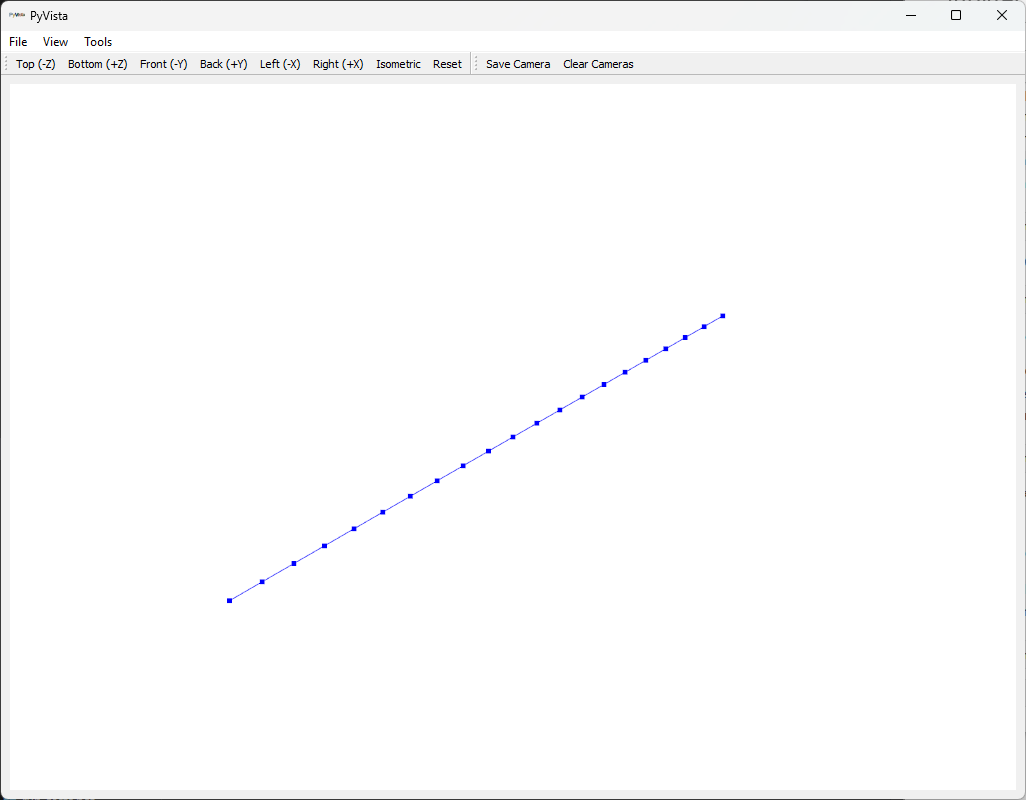

## Systems in SDynPy

The [`System`](#api:sdynpy.System) object is designed to
store the mass, stiffness, and damping matrices associated with a dynamic
system.  These are stored in the ``mass``, ``stiffness``, and ``damping``
attributes of the [`System`](#api:sdynpy.System) object.

Typing ``system`` into the into the Python console will report the number of
the degrees of freedom in the system.

In [19]:
system

System with 126 DoFs (126 internal DoFs)

We can plot the system matrices to see the element connectivity.  Each matrix
should have numbers of rows and columns equal to the reported number of internal
degrees of freedom, which will be 126 for this 

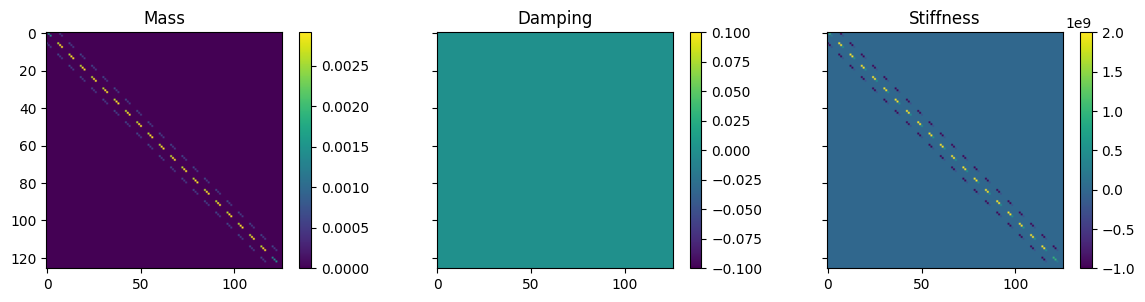

In [20]:
# Create the figure and axes
fig,ax = plt.subplots(1,3,sharex=True,sharey=True,num='System Matrices',
                        figsize=(12,3))
# Plot the matrices
mimg = ax[0].imshow(system.mass)
dimg = ax[1].imshow(system.damping)
simg = ax[2].imshow(system.stiffness)
# Add colorbar
plt.colorbar(mimg,ax=ax[0])
plt.colorbar(dimg,ax=ax[1])
plt.colorbar(simg,ax=ax[2])
# Label each plot
ax[0].set_title('Mass')
ax[1].set_title('Damping')
ax[2].set_title('Stiffness')
# Set to tight layout
fig.tight_layout()

Note that due to the system deriving from a finite element model, the damping
is zero.

In addition to the ``mass``, ``stiffness``, and ``damping`` matrices, SDynPy
[`System`](#api:sdynpy.System) objects also track
transformations between internal state degrees of freedom, as well as which
degrees of freedom are associated with rows and columns of the matrices.

For the current ``system`` object, the transformation, accessed using the 
``system.transformation`` attribute, is the identity matrix.
This is because the system matrices are already represented in physical
coordinates.


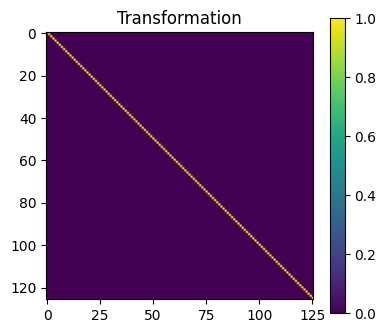

In [21]:
# Create the figure and axes
fig,ax = plt.subplots(1,1,sharex=True,sharey=True,num='System Transformation',
                        figsize=(4,3.5))
# Plot the matrices
timg = ax.imshow(system.transformation)
# Add colorbar
plt.colorbar(timg,ax=ax)
# Label each plot
ax.set_title('Transformation')
# Set to tight layout
fig.tight_layout()

The degrees of freedom corresponding to the rows and columns of the system
matrices can be accessed using the ``system.coordinate`` attribute.  This
provides a [`CoordinateArray`](#api:sdynpy.CoordinateArray)
object containing the degrees of freedom (node and local direction).

In [22]:
system.coordinate

coordinate_array(string_array=
array(['1X+', '1Y+', '1Z+', '1RX+', '1RY+', '1RZ+', '2X+', '2Y+', '2Z+',
       '2RX+', '2RY+', '2RZ+', '3X+', '3Y+', '3Z+', '3RX+', '3RY+',
       '3RZ+', '4X+', '4Y+', '4Z+', '4RX+', '4RY+', '4RZ+', '5X+', '5Y+',
       '5Z+', '5RX+', '5RY+', '5RZ+', '6X+', '6Y+', '6Z+', '6RX+', '6RY+',
       '6RZ+', '7X+', '7Y+', '7Z+', '7RX+', '7RY+', '7RZ+', '8X+', '8Y+',
       '8Z+', '8RX+', '8RY+', '8RZ+', '9X+', '9Y+', '9Z+', '9RX+', '9RY+',
       '9RZ+', '10X+', '10Y+', '10Z+', '10RX+', '10RY+', '10RZ+', '11X+',
       '11Y+', '11Z+', '11RX+', '11RY+', '11RZ+', '12X+', '12Y+', '12Z+',
       '12RX+', '12RY+', '12RZ+', '13X+', '13Y+', '13Z+', '13RX+',
       '13RY+', '13RZ+', '14X+', '14Y+', '14Z+', '14RX+', '14RY+',
       '14RZ+', '15X+', '15Y+', '15Z+', '15RX+', '15RY+', '15RZ+', '16X+',
       '16Y+', '16Z+', '16RX+', '16RY+', '16RZ+', '17X+', '17Y+', '17Z+',
       '17RX+', '17RY+', '17RZ+', '18X+', '18Y+', '18Z+', '18RX+',
       '18RY+', '18RZ+', '19X+',

### Coordinates

Here again is a good place to explore what makes up a
[`CoordinateArray`](#api:sdynpy.CoordinateArray)
object.  We can examine the data type of the 
[`CoordinateArray`](#api:sdynpy.CoordinateArray)
to see that it contains fields for a 64-bit unsigned integer as the ``node``
field and an 8-bit signed integer for the ``direction`` field.   


In [23]:
system.coordinate.dtype

dtype([('node', '<u8'), ('direction', 'i1')])

[`CoordinateArray`](#api:sdynpy.CoordinateArray)
objects store the direction as an integer with encoding:


|Direction   | Integer Encoding |
|------------|------------------|
|    X+      |        1         |
|    Y+      |        2         |
|    Z+      |        3         |
|    RX+     |        4         |
|    RY+     |        5         |
|    RZ+     |        6         |
|    X-      |       -1         |
|    Y-      |       -2         |
|    Z-      |       -3         |
|    RX-     |       -4         |
|    RY-     |       -5         |
|    RZ-     |       -6         |
|    None    |        0         |

Note that the directions with ``R`` are rotations about the respective axis.

When we want to examine
[`CoordinateArray`](#api:sdynpy.CoordinateArray)
objects, the integer directions are typically transformed into the more
readable direction strings shown in the first column of the above table.  For
example, if we type a
[`CoordinateArray`](#api:sdynpy.CoordinateArray) object
into the console, the representation of the
object displays the string array version of the coordinates, as shown above.
      
From the above, we can see that the
[`System`](#api:sdynpy.System) we just created
contains a degree of freedom for each of the positive X, Y, Z translations and
each of the positive X, Y, Z rotations each node.

Many SDynPy objects allow indexing with a
[`CoordinateArray`](#api:sdynpy.CoordinateArray)
object to automatically handle the bookkeeping aspect of selecting the right
data for each coordinate.

### Plotting Coordinates

At this point, we would like to plot our coordinates on top of our geometry.
For this we use the 
[`plot_coordinate`](#api:sdynpy.Geometry.plot_coordinate)
method of the [`Geometry`](#api:sdynpy.Geometry) object.


In [24]:
geometry.plot_coordinate(system.coordinate,arrow_scale=0.02)

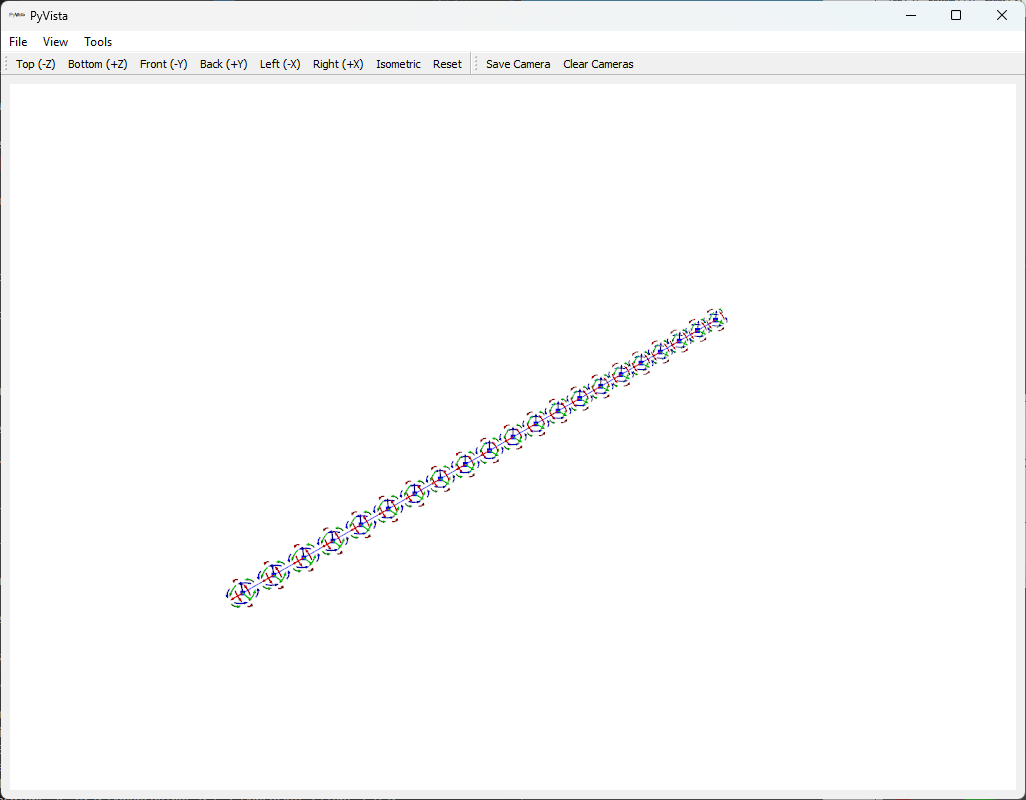

Note that due to the density of the mesh, we had to make the ``arrow_scale``
smaller than the default, otherwise the arrows would overlap.

If we zoom into the coordinate systems on the figure, we see more clearly that
there are rotations and translations defined at each node.

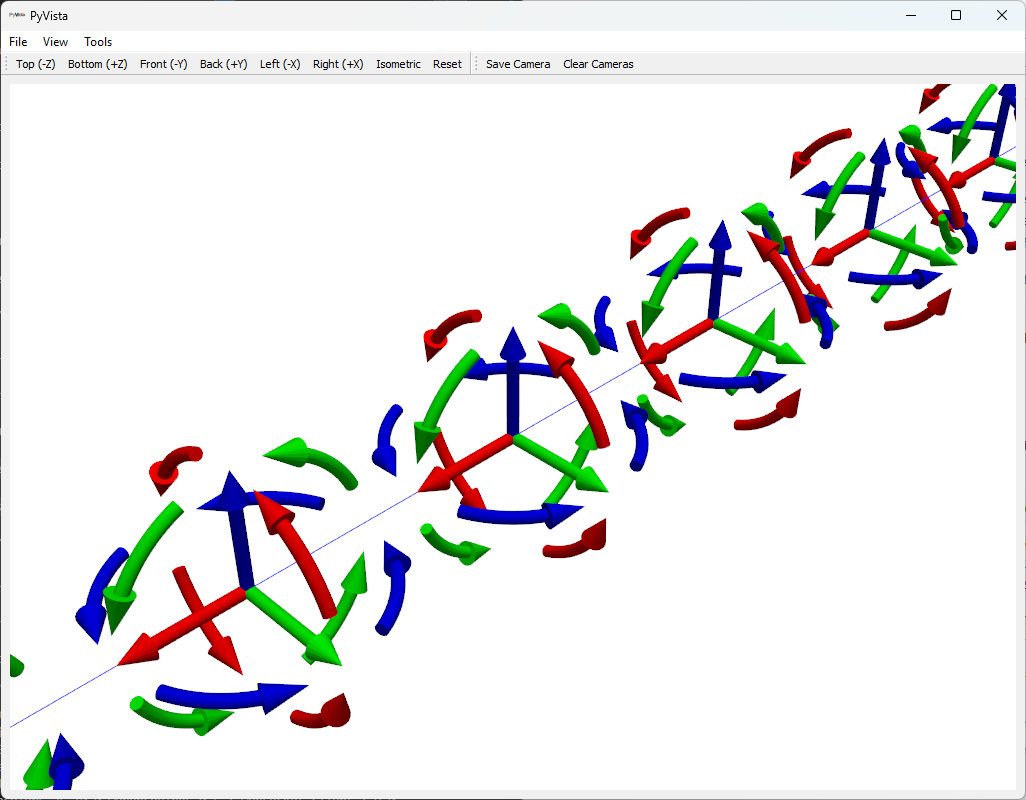

## Computing Modes of the System

With mass, stiffness, and damping matrices, there are several types of
structural dynamics analyses that could be performed.  One popular analysis
that is performed in structural dynamics is modal analysis.  In this type of
analysis, we will compute the 
[Generalized Eigensolution](sec:solving_for_eigenvalues)
of the mass and stiffness matrices.  While we could extract these matrices from
the [`System`](#api:sdynpy.System) object and perform
the eigensolution using a linear algebra package such as that in SciPy, we can
instead use the [`System.eigensolution`](#api:sdynpy.System.eigensolution)
method to compute the modes and handle all of the bookkeeping.  This method
accepts arguments to determine which modes to compute.  For example, we can
easily compute all modes below a certain frequency (say 4000 Hz).

In [25]:
shapes = system.eigensolution(maximum_frequency=4000)

This produces a [`ShapeArray`](#api:sdynpy.ShapeArray)
object, which is used by SDynPy to represent mode shapes and deflection shapes.

We can type the variable name ``shapes`` into the Python console to see more
information about the mode shapes.

In [26]:
shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     0.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     0.0000,    0.0000%,        126
    (3,),     0.0153,    0.0000%,        126
    (4,),     0.0153,    0.0000%,        126
    (5,),     0.0153,    0.0000%,        126
    (6,),   648.5603,    0.0000%,        126
    (7,),  1297.1207,    0.0000%,        126
    (8,),  1787.8068,    0.0000%,        126
    (9,),  3504.9762,    0.0000%,        126
   (10,),  3575.6135,    0.0000%,        126

Here we see there were 11 modes below 4000 Hz.  6 of the modes are rigid body
modes, with natural frequency of approximately 0 Hz.  5 of the modes are elastic
modes.  Each of the modes has 0% damping (due to the damping matrix being equal
to the zero matrix), and each mode has 126 degrees of freedom.

### Shapes

At this point, it is useful to explore briefly the
[`ShapeArray`](#api:sdynpy.ShapeArray) object in the
Python console.  The data type of the object is:

In [27]:
shapes.dtype

dtype([('frequency', '<f8'), ('damping', '<f8'), ('coordinate', [('node', '<u8'), ('direction', 'i1')], (126,)), ('shape_matrix', '<f8', (126,)), ('modal_mass', '<f8'), ('comment1', '<U80'), ('comment2', '<U80'), ('comment3', '<U80'), ('comment4', '<U80'), ('comment5', '<U80')])

The data type of 
[`ShapeArray`](#api:sdynpy.ShapeArray) objects can change
depending on what type of shape and how many degrees of freedom are in the
shape.  ``frequency`` and ``damping`` fields are stored as 64-bit floating
point numbers with one value per entry in the 
[`ShapeArray`](#api:sdynpy.ShapeArray).  ``modal_mass``
is also stored in the present
[`ShapeArray`](#api:sdynpy.ShapeArray), but if the shape
is complex, then the modal mass might also be complex.  The ``shape_matrix``
field holds the underlying shape data.  It has one entry for every degree of
freedom in the shape, and is represented by a floating point number for
normal modes or a complex number for complex modes.  Similarly, the
``coordinate`` field identifies which degree of freedom belongs to which entry
in the ``shape_matrix`` field.  The ``coordinate`` field stores data as
[`CoordinateArray`](#api:sdynpy.CoordinateArray)
objects, and thus has the same data type as
[`CoordinateArray`](#api:sdynpy.CoordinateArray).
Finally, there are five fields available for comments, which store string data
up to 80 characters which can be used to store any data the user feels is
relevant to the analysis.

One thing to note is that the ``shape_matrix`` field, due to the dimension of
the field being appended at the end of the array, will be transposed from the
typical representation of a mode shape matrix (degrees of freedom as rows and
mode indices as columns). The ``shape_matrix`` field will instead have the
shape of the [`ShapeArray`](#api:sdynpy.ShapeArray)
object itself as its first dimensions, and then the size of the ``coordinate``
field as its last dimension.

In [28]:
shapes.shape

(11,)

In [29]:
shapes.shape_matrix.shape

(11, 126)

To access the mode shape matrix in a more familiar format, users can instead
access the ``modeshape`` attribute of the
[`ShapeArray`](#api:sdynpy.ShapeArray) object.  This will
be identical data to the ``shape_matrix`` field, except it will have the last
two dimensions of the array transposed.  For a 1D array of shapes, this will
produce a modeshape matrix with degrees of freedom indices as the rows of the
matrix and mode indices as the columns of the matrix.

In [30]:
shapes.modeshape.shape

(126, 11)

### Plotting Shapes

While it may be useful to access the raw mode shape data in matrix form, the most
intutive view of the shapes is often obtained when the shapes are plotted on
the geometry.  This is easily done in SDynPy by using the
[`plot_shape`](#api:sdynpy.Geometry.plot_shape) method of the
[`Geometry`](#api:sdynpy.Geometry) object, and passing
the [`ShapeArray`](#api:sdynpy.ShapeArray) object as the
argument.

In [31]:
geometry.plot_shape(shapes)

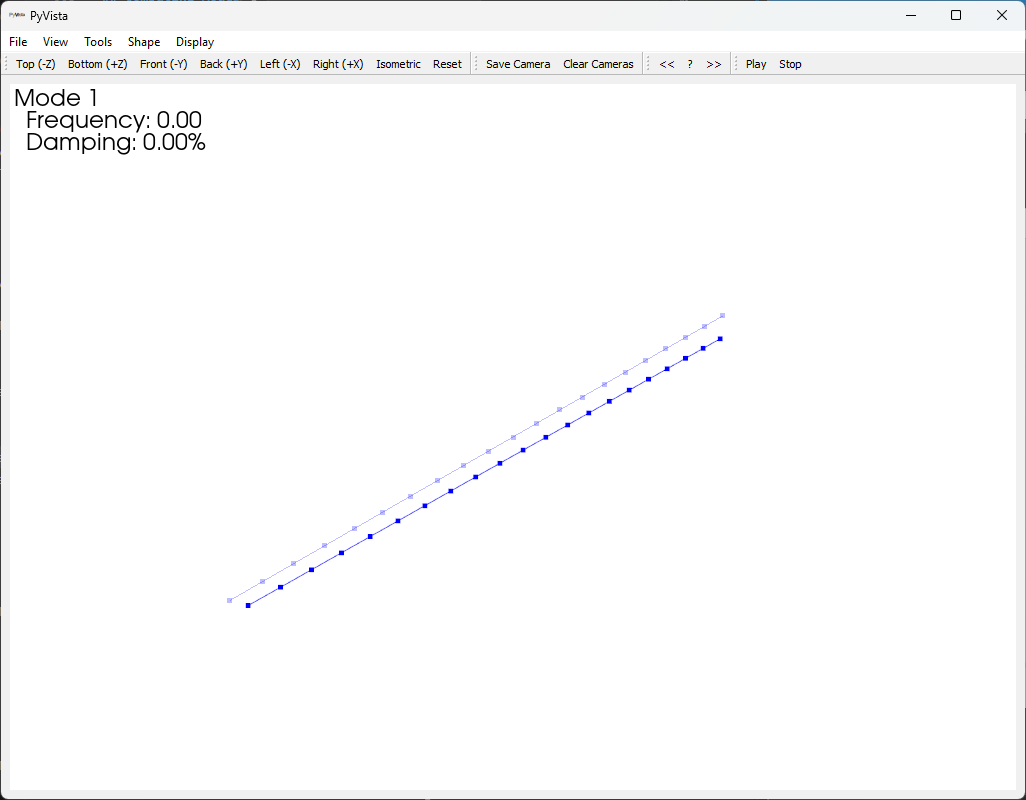

The Shape Plotter window is an interactive, animated 3D plot that allows users
to visualize the mode shapes of the system.  We will briefly highlight some of
the key features of this tool.

The ``File`` menu contains tools for saving images from the window.  The 
``Take Screenshot`` action allows saving an image of the current window.  The
``Save Animation`` action will save an animated GIF of the shape from the
current view.  

The ``View`` menu contains tools for adjusting the view of the window, as well
as plotting utility widgets.  The ``Camera`` ``Toggle Parallel Projection``
action will switch between perspective and parallel camera projections.  A
small coordinate axis triad can be plotted by displaying the
``Orientation Marker``, and labelled axes can be plotted by selecting
``Bounds Axes``.

The ``Shape`` menu contains tools for adjusting how the shapes are presented.
The shape complexity can be adjusted, as well as the shape scaling and animation
speed.  The text showing the mode number, frequency, damping, and any comments
can also be shown or hidden.

The toolbars in the widget offer features as well.  The camera can be set to
several default views along the principal axes.  Camera views can be saved and
recalled as well.  The mode that is being shown can be changed by clicking the
``<<`` and ``>>`` buttons.  The animation can be started or stopped by pressing
the ``Play`` and ``Stop`` Buttons.

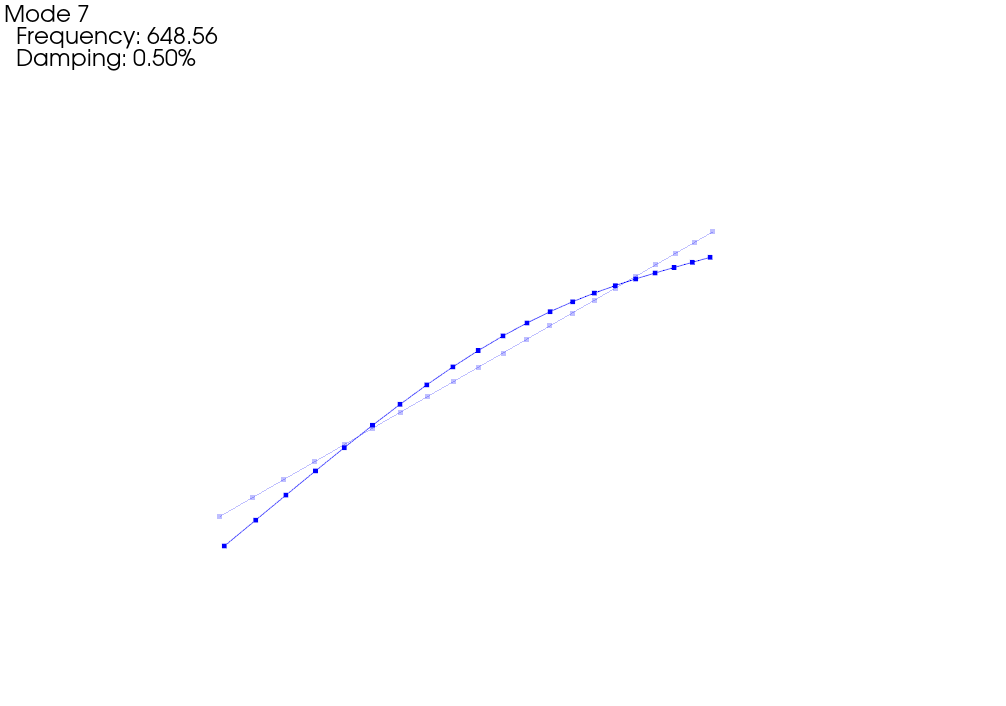

### Assigning to SDynpy Array Fields and Array Views versus Copies

Often, one may wish to assign values to specific fields of the SDynPy objects.
For example, the first six modes of the structure should be rigid body modes;
however, the eigensolution has left three of the first six natural frequencies
with small positive values.  Let's set these values to zero.  SDynPy arrays,
as well as the fields of the arrays, inherit all properties of NumPy's
``ndarray`` object, and can therefore be indexed identically.  We can use this
indexing either to get specific portions of the array or to assign values to
certain portions of the array.  For example, if we want to assign the first 
six natural frequencies to zero, we can use the command:

In [32]:
shapes.frequency[:6] = 0

We can then check that the values are indeed set to zero.

In [33]:
shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     0.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     0.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     0.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126
    (6,),   648.5603,    0.0000%,        126
    (7,),  1297.1207,    0.0000%,        126
    (8,),  1787.8068,    0.0000%,        126
    (9,),  3504.9762,    0.0000%,        126
   (10,),  3575.6135,    0.0000%,        126

Note that when utilizing NumPy ``ndarray`` objects, one should always be aware
what type of object is returned from an indexing or slicing operation.  NumPy
can either return a *copy* of the original array or a *view* into the original
array.  A *copy* is a completely new array that contains equivalent data to the
original array, but has no connection back to it.  Changing a value in a copy
of an array will not modify that same value in the original array.  A *view*
is simply a window into the original array, meaning it shares the same memory
as the original array.  Changing a value in a view of an array *will also modify*
the data in the original array.  Views are useful in that they do not duplicate
memory, so when working with large arrays, using views is much more efficient
than using copies.  However, if a user assumes that they are working with a
copy of an array but are actually working with a view of an array, there may
be unintended side-effects when the value of the original array is unintentionally
modified.  For a full treatment of indexing in NumPy, users are directed to the
[documentation on indexing](https://numpy.org/doc/stable/user/basics.indexing.html)
for NumPy ``ndarrays``.  The present documentation will simply show some examples
of when different types of indexing are used, and what the ramifications could
be if users are not careful.

#### Indexing using a Single Integer Index

The simplest indexing approach for NumPy objects is to index with a single 
integer.  This will generally return a view of the object.  For example, we can
access the first shape in the 
[`ShapeArray`](#api:sdynpy.ShapeArray) object with the
syntax

In [34]:
first_shape = shapes[0]

If we then set the frequency of ``first_shape`` equal to some value, we will
see that our original shape matrix also has that value assigned as the first
frequency.

In [35]:
first_shape.frequency = 10

In [36]:
shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),    10.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     0.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     0.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126
    (6,),   648.5603,    0.0000%,        126
    (7,),  1297.1207,    0.0000%,        126
    (8,),  1787.8068,    0.0000%,        126
    (9,),  3504.9762,    0.0000%,        126
   (10,),  3575.6135,    0.0000%,        126

Here we see that we assigned a variable when we modified ``first_shape``'s 
frequency to 10, the first frequency of ``shapes`` also became 10, because they
point to the same position in memory.

#### Indexing using a Slice

A second common method of indexing an array is using a slice.  Slices can be
defined with a start index, a stop index, and a step size.  For example, a slice
``0:6:2`` would return indices from zero up to just before 6, and only return
every second index, which would be 0, 2, and 4.

For example:


In [37]:
indexed_shapes = shapes[:6:2]
indexed_shapes.frequency = 2

In [38]:
shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     2.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     2.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     2.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126
    (6,),   648.5603,    0.0000%,        126
    (7,),  1297.1207,    0.0000%,        126
    (8,),  1787.8068,    0.0000%,        126
    (9,),  3504.9762,    0.0000%,        126
   (10,),  3575.6135,    0.0000%,        126

We can see that the 0, 2, and 4 indices were set to have frequencies of 2, which
corresponds to the original slice.

Note we could also do the indexing directly on the ``frequency`` field.
For example:

In [39]:
indexed_frequencies = shapes.frequency[:6:2]
indexed_frequencies[:] = 3

In [40]:
shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     3.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     3.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     3.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126
    (6,),   648.5603,    0.0000%,        126
    (7,),  1297.1207,    0.0000%,        126
    (8,),  1787.8068,    0.0000%,        126
    (9,),  3504.9762,    0.0000%,        126
   (10,),  3575.6135,    0.0000%,        126

Note the syntax ``indexed_frequencies[:] = 3``.  Had we simply typed
``indexed_frequencies = 3``, this would have *not* overwritten the original 
frequencies as this latter syntax is simply a redefinition of the variable
``indexed_frequencies`` to a different value rather than a reassignment of the
values *in* ``indexed_frequencies`` to a different value.  The former syntax
reassigns values at the ``indexed_frequencies`` memory location, and the latter
assigns ``indexed_frequencies`` to a different memory location, which breaks
the connection to the original memory location, so ``indexed_frequencies`` is
no longer a view into ``shapes``.  For example:

In [41]:
indexed_frequencies = 6

In [42]:
shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     3.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     3.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     3.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126
    (6,),   648.5603,    0.0000%,        126
    (7,),  1297.1207,    0.0000%,        126
    (8,),  1787.8068,    0.0000%,        126
    (9,),  3504.9762,    0.0000%,        126
   (10,),  3575.6135,    0.0000%,        126

In the previous example the values of the 0, 2, and 4 frequency indices were
not modified from three to six.  Instead of defining the frequencies *in* the
array to 6, we simply redefined the variable ``indexed_frequencies`` to be 6.

#### Indexing with Logical Arrays

NumPy ``ndarrays`` can also be indexed with logical (or boolean) arrays.  These
are arrays full of ``True`` and ``False`` values.  These are often returned due
to comparison operations.  For example, if we want all of the frequencies less
than ten hertz, we can perform the operation:

In [43]:
logical_array = shapes.frequency < 10

In [44]:
logical_array

array([ True,  True,  True,  True,  True,  True, False, False, False,
       False, False])

This last set of commands has produced a logical array where the first six
indices are ``True`` and the last five are ``False``.  If we index the ``shapes``
object with this, we will return only the shapes where the logical array is
``True``.

In [45]:
rigid_shapes = shapes[logical_array]

In [46]:
rigid_shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     3.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     3.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     3.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126

However, unlike the last indexing types, this type of indexing will
return a *copy* of the array, rather than a view into the array.  For example,
if we redefine values of the ``frequency`` field in ``rigid_shapes``, it will
**not** update the frequency in the original ``shapes`` variable.

In [47]:
rigid_shapes.frequency = 0

In [48]:
rigid_shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     0.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     0.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     0.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126

In [49]:
shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     3.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     3.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     3.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126
    (6,),   648.5603,    0.0000%,        126
    (7,),  1297.1207,    0.0000%,        126
    (8,),  1787.8068,    0.0000%,        126
    (9,),  3504.9762,    0.0000%,        126
   (10,),  3575.6135,    0.0000%,        126

Here we see that there is no memory link between ``rigid_shapes`` and ``shapes``
because they have different values of their ``frequency`` field.  Note that if
we wish to perform assignments using logical indexing, we need to make sure that
the indexing is performed as the last operation.  For example, consider the
following code.


In [50]:
shapes[logical_array].frequency = 0

In [51]:
shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     3.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     3.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     3.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126
    (6,),   648.5603,    0.0000%,        126
    (7,),  1297.1207,    0.0000%,        126
    (8,),  1787.8068,    0.0000%,        126
    (9,),  3504.9762,    0.0000%,        126
   (10,),  3575.6135,    0.0000%,        126

Looking at the first command naively, it would seem that we would take the
shapes specified by ``logical_array`` (i.e. the first six modes) and assign their
frequencies to 0.  However, if we look at the contents of ``shapes`` immediately
afterwards, we can see that no such assignment has taken place.  Instead, the
first six modes have their original values of alternating three and zero.
If we think a bit harder and remember that we make a copy of the array when we
index with a logical array, we will realize that we have created a copy of the
first six modes of the ``shapes`` array, and assigned the frequencies of that
copy to zero.  However, since that copy was never assigned to any variable, it
is immediately discarded by the Python interpreter as unused.  The original 
``shapes`` array remains unmodified.  To achieve the desired result, we should
instead make sure the indexing occurs last.

In [52]:
shapes.frequency[logical_array] = 0

In [53]:
shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     0.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     0.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     0.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126
    (6,),   648.5603,    0.0000%,        126
    (7,),  1297.1207,    0.0000%,        126
    (8,),  1787.8068,    0.0000%,        126
    (9,),  3504.9762,    0.0000%,        126
   (10,),  3575.6135,    0.0000%,        126

In this latter case, we have accessed the ``frequency`` field of the original
``shapes`` array, rather than a copy of the ``frequency`` field, therefore when
we assign to those values, the original ``shapes`` array is modified.

#### Indexing with Integer Arrays

The final indexing approach discussed here is indexing with integer arrays.
This is useful when specific indices are desired, but one does not want to set
up the entire logical array.  For example, to get the first six modes, we could
construct an integer array:

In [54]:
integer_array = [0,1,2,3,4,5]
rigid_shapes = shapes[integer_array]

In [55]:
rigid_shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     0.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     0.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     0.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126

We can see that we were able to access the first six modes of ``shapes`` this
way.

In [56]:
rigid_shapes.frequency = 10

In [57]:
shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     0.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     0.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     0.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126
    (6,),   648.5603,    0.0000%,        126
    (7,),  1297.1207,    0.0000%,        126
    (8,),  1787.8068,    0.0000%,        126
    (9,),  3504.9762,    0.0000%,        126
   (10,),  3575.6135,    0.0000%,        126

However, identical to the logical array case, this indexing operation will create a copy of, rather than a view into, the original array, meaning that modifications of one do not propogate to the other.

As a general rule of thumb, indexing using a single integer or slice produces a
view into the original array, but indexing with a logical or index array produces
a copy.  If the reader still does not understand these concepts, they are
encouraged to read and understand the NumPy
[documentation on indexing](https://numpy.org/doc/stable/user/basics.indexing.html),
otherwise misapplying these nuanced concepts can introduce bugs into analyses
performed using SDynPy.

## Computing a Modal System


Given that our [`ShapeArray`](#api:sdynpy.ShapeArray) object
came from a beam finite element model without any damping defined, it might be
useful to assign damping to the shapes to more realistically simulate a real 
beam.  We will assign a small amount of damping to all modes.


In [58]:
shapes.damping = 0.005

Now, if we investigate the ``shapes`` variable in the console, we will see 
that the damping is no longer zero.

In [59]:
shapes

   Index,  Frequency,    Damping,     # DoFs
    (0,),     0.0000,    0.5000%,        126
    (1,),     0.0000,    0.5000%,        126
    (2,),     0.0000,    0.5000%,        126
    (3,),     0.0000,    0.5000%,        126
    (4,),     0.0000,    0.5000%,        126
    (5,),     0.0000,    0.5000%,        126
    (6,),   648.5603,    0.5000%,        126
    (7,),  1297.1207,    0.5000%,        126
    (8,),  1787.8068,    0.5000%,        126
    (9,),  3504.9762,    0.5000%,        126
   (10,),  3575.6135,    0.5000%,        126

If we wanted to perform simulations with this new model that has damping
incorporated, we can easily transform the
[`ShapeArray`](#api:sdynpy.ShapeArray) object into a
[`System`](#api:sdynpy.System) object by using the
[`system`](#api:sdynpy.ShapeArray.system) method of the
[`ShapeArray`](#api:sdynpy.ShapeArray) class.


In [60]:
modal_system = shapes.system()

This will construct a [`System`](#api:sdynpy.System)
object, but unlike our original ``system`` variable, this ``modal_system`` will
be a *reduced* system.  Instead of the internal system states being equivalent
to physical degrees of freedom, the internal system states are now *modal*
degrees of freedom.

If we type the ``modal_system`` variable into the console, we see that while it
still has 126 degrees of freedom, it only contains 11 internal degrees of
freedom.

In [61]:
modal_system

System with 126 DoFs (11 internal DoFs)

We can plot the system matrices.

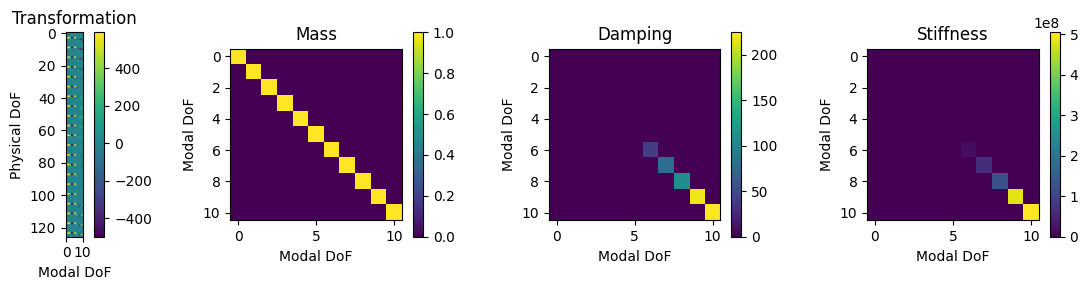

In [62]:
# Plot the modal system matrices
fig,ax = plt.subplots(1,4,num='Modal System Matrices',figsize=(12,3))
# Transformation
timg = ax[0].imshow(modal_system.transformation)
ax[0].set_title('Transformation')
ax[0].set_ylabel('Physical DoF')
ax[0].set_xlabel('Modal DoF')
plt.colorbar(timg,ax=ax[0])
# Mass
mimg = ax[1].imshow(modal_system.mass)
ax[1].set_title('Mass')
ax[1].set_ylabel('Modal DoF')
ax[1].set_xlabel('Modal DoF')
plt.colorbar(mimg,ax=ax[1])
# Damping
dimg = ax[2].imshow(modal_system.damping)
ax[2].set_title('Damping')
ax[2].set_ylabel('Modal DoF')
ax[2].set_xlabel('Modal DoF')
plt.colorbar(dimg,ax=ax[2])
# Stiffness
simg = ax[3].imshow(modal_system.stiffness)
ax[3].set_title('Stiffness')
ax[3].set_ylabel('Modal DoF')
ax[3].set_xlabel('Modal DoF')
plt.colorbar(simg,ax=ax[3])
fig.tight_layout()

We can see that the mass, stiffness, and
damping matrices of ``modal_system`` are now the modal mass, modal stiffness,
and modal damping matrices.  SDynPy also tracks the transformation between internal
degrees of freedom and physical degrees of freedom, which in this case is the
mode shape matrix $\mathbf{\Phi}$, which transforms modal degrees of freedom $\mathbf{q}$
to physical degrees of freedom $\mathbf{x}$ by the well-known modal
transformation

$$\mathbf{x} = \mathbf{\Phi}\mathbf{q}$$

We can see that the coordinates of the original ``system`` and ``modal_system``
are identical, meaning the same physical degrees of freedom exist in each.

In [63]:
np.all(system.coordinate == modal_system.coordinate)

np.True_

Because SDynPy tracks the transformation between internal and physical degrees
of freedom and applies it when necessary, the reduced ``modal_system`` can be
utilized identically to the original ``system`` consisting of physical degrees
of freedom.  For example, we can compute the eigensolution of ``modal_system``
and find that it produces the exact same modes as the original shapes.  The
transformation is automatically applied to the mode shape matrix to produce
shapes at the physical degrees of freedom.

In [64]:
modal_system.eigensolution()

   Index,  Frequency,    Damping,     # DoFs
    (0,),     0.0000,    0.0000%,        126
    (1,),     0.0000,    0.0000%,        126
    (2,),     0.0000,    0.0000%,        126
    (3,),     0.0000,    0.0000%,        126
    (4,),     0.0000,    0.0000%,        126
    (5,),     0.0000,    0.0000%,        126
    (6,),   648.5603,    0.5000%,        126
    (7,),  1297.1207,    0.5000%,        126
    (8,),  1787.8068,    0.5000%,        126
    (9,),  3504.9762,    0.5000%,        126
   (10,),  3575.6135,    0.5000%,        126

The modal system is useful because it can give approximately the same results
as the physical system (at least over the bandwidth of interest) with
significantly less computational cost.  Rather than performing computations on
a coupled, 126-degree-of-freedom system, we can instead perform computations on
an uncoupled, 11-degree-of-freedom system, and then apply a simple
transformation to convert the results back to physical degrees of freedom.

## Data in SDynPy

Data in SDynPy is stored as subclasses of the
[`NDDataArray`](#api:sdynpy.NDDataArray) object, which
represents all types of data in SDynPy (time histories, frequency response
functions, power spectral density arrays, etc.).  Functionality for specific
data types are stored in their respective subclasses.  For example, time history
signals are stored in
[`TimeHistoryArray`](#api:sdynpy.TimeHistoryArray) objects
and frequency response functions are stored in
[`TransferFunctionArray`](#api:sdynpy.TransferFunctionArray)
objects.  

To create a
[`NDDataArray`](#api:sdynpy.NDDataArray) object, can will
utilize the
[`data_array`](#api:sdynpy.data_array) function.  This
function accepts a type specifier defined by the
[`FunctionTypes`](#api:sdynpy.core.sdynpy_data.FunctionTypes) enumeration.
Alternatively, users may use one of the many helper functions to create a specific
type of data.  For example, the [`time_history_array`](#api:sdynpy.time_history_array)
function will create a [`TimeHistoryArray`](#api:sdynpy.TimeHistoryArray) object.
Thesse functions will accept the abscissa (independent variable, e.g., frequency or time),
the ordinate (dependent variable, e.g., acceleration or force), the coordinate
(degree of freedom information for the signal), as well as up to five comments.
For example, we can construct a set of sine waves with different amplitudes

In [65]:
times = np.arange(100)/100
amplitudes = np.array([1,2])
# Use broadcasting to compute the signals
signal = amplitudes[:,np.newaxis]*np.sin(2*np.pi*5*times)
coordinates = sdpy.coordinate_array(
    string_array=['101X+','101Y-'])[:,np.newaxis]

time_history = sdpy.time_history_array(
    abscissa = times,
    ordinate = signal,
    coordinate = coordinates)

There are numerous function types defined in SDynPy.  Referencing the
[`sdpy.data`](#api:sdynpy.core.sdynpy_data) module will show the different
subclasses available.

Let's take this time to explore of the
[`NDDataArray`](#api:sdynpy.NDDataArray) class before moving
on.  First, let's examine the fields available by looking at the object's
``dtype``.

In [66]:
time_history.dtype

dtype([('abscissa', '<f8', (100,)), ('ordinate', '<f8', (100,)), ('comment1', '<U80'), ('comment2', '<U80'), ('comment3', '<U80'), ('comment4', '<U80'), ('comment5', '<U80'), ('coordinate', [('node', '<u8'), ('direction', 'i1')], (1,))])

The ``abscissa`` field consists of the independent variable, which in the case
of this time history, is the time value at each step.  Different function types
will have different abscissa data types.  For example, a spectral quantity may
have frequency lines as its abscissa.  The ``ordinate`` field consists of the
dependant variable.  For a time history, this is a real quantity, but for a
frequency-domain function such as a frequency response function, this may be a
complex value.  Both ``abscissa`` and ``ordinate`` have a shape of ``(100,)``, which
is the length of the time signal.  Like the
[`ShapeArray`](#api:sdynpy.ShapeArray),
there are five fields available for comments, which store string data
up to 80 characters which can be used to store any data the user feels is
relevant to the analysis.  Finally, the ``coordinate`` field stores degree of 
freedom data as
[`CoordinateArray`](#api:sdynpy.CoordinateArray)
objects, and thus has the same data type as
[`CoordinateArray`](#api:sdynpy.CoordinateArray).
Different function types will have different shaped ``coordinate`` fields.
For example, a time history only has one degree of freedom associated with each
signal, so its shape is ``(1,)``.  Note, however that this makes the coordinate
field for the entire array ``(2,1)``, which is why the new axis needed to be
added to the coordinates ``coordinates`` variable in the previous code block.

In [67]:
time_history.shape

(2,)

In [68]:
time_history.coordinate.shape

(2, 1)

Other types of functions may have differently-shaped ``coordinate`` fields.
For example, a frequency response function will generally have a response
coordinate and a reference coordinate for each entry in the matrix, so it will
have a ``coordinate`` field of shape ``(2,)``.

There are many ways to visualize data in SDynPy, but the simplest is generally
to call the 
[`plot`](#api:sdynpy.NDDataArray.plot) method of the
[`NDDataArray`](#api:sdynpy.NDDataArray) object.
This will produce a plot window with the signals displayed in it.  This is more
useful for smaller datasets.  The plots produced by this method can get quite
busy if many signals are plotted.

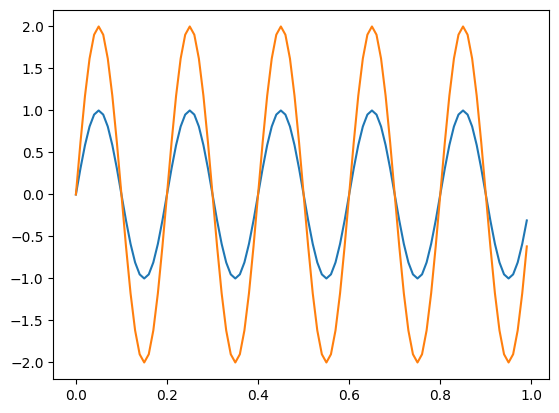

In [119]:
time_history.plot();

## Integrating Equations of Motion to Produce Time Data

While [`NDDataArray`](#api:sdynpy.NDDataArray) objects can
be created manually, many functions and methods in SDynPy will return various
data.  One common operation is to integrate the equations of motion of a system
to create a simulated time response to an imposed excitation or an imposed
initial condition.  The
[`time_integrate`](#api:sdynpy.System.time_integrate)
method of the [`System`](#api:sdynpy.System) class can be
used to integrate the dynamic system to produce time responses.  We will
demonstrate this analysis in this section.

### Generating an Excitation Signal

When setting up the time integration, we must consider the excitation that will
be applied to the [`System`](#api:sdynpy.System), as well 
as the initial conditions.  For this case, we will consider the system starting
at rest.  We will excite the structure with a pair of perpendicular random
vibration signals at the beam tip.  We can easily create these signals using
SDynPy's [`sdpy.generator`](#api:sdynpy.signal_processing.sdynpy_generator)
sub-module.  This contains functions to produce common signals used in
structural dynamics such as
[`sine`](#api:sdynpy.signal_processing.sdynpy_generator.sine),
[`chirp`](#api:sdynpy.signal_processing.sdynpy_generator.chirp),
[`pseudorandom`](#api:sdynpy.signal_processing.sdynpy_generator.pseudorandom),
[`random`](#api:sdynpy.signal_processing.sdynpy_generator.random),
[`burst_random`](#api:sdynpy.signal_processing.sdynpy_generator.burst_random),
and [`pulse`](#api:sdynpy.signal_processing.sdynpy_generator.pulse).  The functions
in the [`generator`](#api:sdynpy.signal_processing.sdynpy_generator) module will
generally be returned as basic NumPy arrays, which should generally be transformed
into [`TimeHistoryArray`](#api:sdynpy.TimeHistoryArray) objects
prior to being used.

We will look at the [`random`](#api:sdynpy.signal_processing.sdynpy_generator.random)
function to generate the input signals for this analysis.  We will set up some
initial signal processing parameters prior to generating the signal.

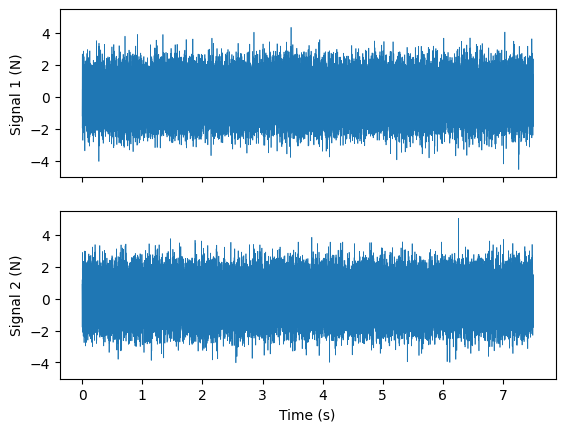

In [70]:
# Set up sampling parameters
signal_bandwidth = 4000 # Hz
sample_rate = signal_bandwidth*2
dt = 1/sample_rate
samples_per_frame = 2000
num_frames = 30
total_samples = samples_per_frame*num_frames
rms_level = 1.0
num_signals = 2

# Generate the signals
signals = sdpy.generator.random((num_signals,),total_samples,rms_level,dt)

# Plot the signals
fig,ax = plt.subplots(num_signals,1,num='Random Signals',
                        sharex=True,sharey=True)
ax[0].plot(np.arange(total_samples)*dt,signals[0],linewidth=0.5)
ax[0].set_ylabel('Signal 1 (N)')
ax[1].plot(np.arange(total_samples)*dt,signals[1],linewidth=0.5)
ax[1].set_ylabel('Signal 2 (N)')
ax[1].set_xlabel('Time (s)');

Rather than using the [`sdpy.generator`](#api:sdynpy.signal_processing.sdynpy_generator) module,
which generates NumPy arrays which are typically then transformed to 
[`TimeHistoryArray`](#api:sdynpy.TimeHistoryArray) objects, we could directly
generate [`TimeHistoryArray`](#api:sdynpy.TimeHistoryArray) objects using the class
methods [`pseudorandom_signal`](#api:sdynpy.TimeHistoryArray.pseudorandom_signal),
[`random_signal`](#api:sdynpy.TimeHistoryArray.random_signal),
[`sine_signal`](#api:sdynpy.TimeHistoryArray.sine_signal),
[`burst_random_signal`](#api:sdynpy.TimeHistoryArray.burst_random_signal),
[`chirp_signal`](#api:sdynpy.TimeHistoryArray.chirp_signal),
[`pulse_signal`](#api:sdynpy.TimeHistoryArray.pulse_signal),
[`haversine_signal`](#api:sdynpy.TimeHistoryArray.haversine_signal), or
[`sine_sweep_signal`](#api:sdynpy.TimeHistoryArray.sine_sweep_signal).

### Performing the Time Integration
  
We can then apply the signal to the structure using the
[`time_integrate`](#api:sdynpy.System.time_integrate)
method of the [`System`](#api:sdynpy.System) class.
We need to chose which degrees of freedom to excite on the structure.  Recall
we can plot degrees of freedom using the
[`plot_coordinate`](#api:sdynpy.Geometry.plot_coordinate)
method of the [`Geometry`](#api:sdynpy.Geometry) object.
By not specifying a set of coordinates to plot, it will simply plot all
translational coordinates.  Additionally, we can pass the optional keyword
argument ``label_dofs = True`` to tell the plotter to label the degrees of
freedom in the plot.


In [71]:
geometry.plot_coordinate(label_dofs=True,arrow_scale=0.02);

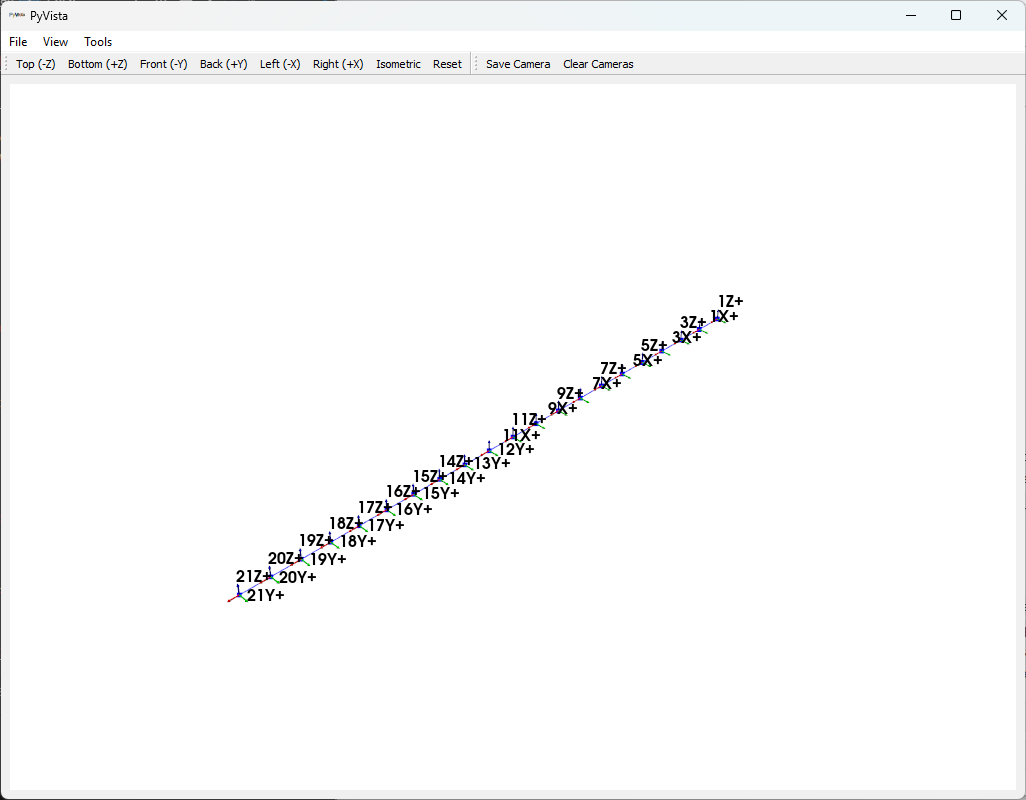

We will place the excitation forces at the tip of the beam in the two transverse
directions.  This corresponds to degrees of freedom ``21Y+`` and ``21Z+``.
We can define a new coordinate array using the 
[`sdpy.coordinate_array`](#api:sdynpy.coordinate_array)
function.  This function can define new 
[`CoordinateArray`](#api:sdynpy.CoordinateArray)
objects in multiple ways.  In this case, we will provide it the ``string_array``
keyword argument, and pass the coordinates that we desire in as strings.
Alternatively, they could also be passed in as separate nodes and directions,
which is useful for longer coordinate arrays.

In [72]:
excitation_dofs = sdpy.coordinate_array(
    string_array = ['21Y+','21Z+'])
    
geometry.plot_coordinate(excitation_dofs,label_dofs=True,arrow_scale=0.05);

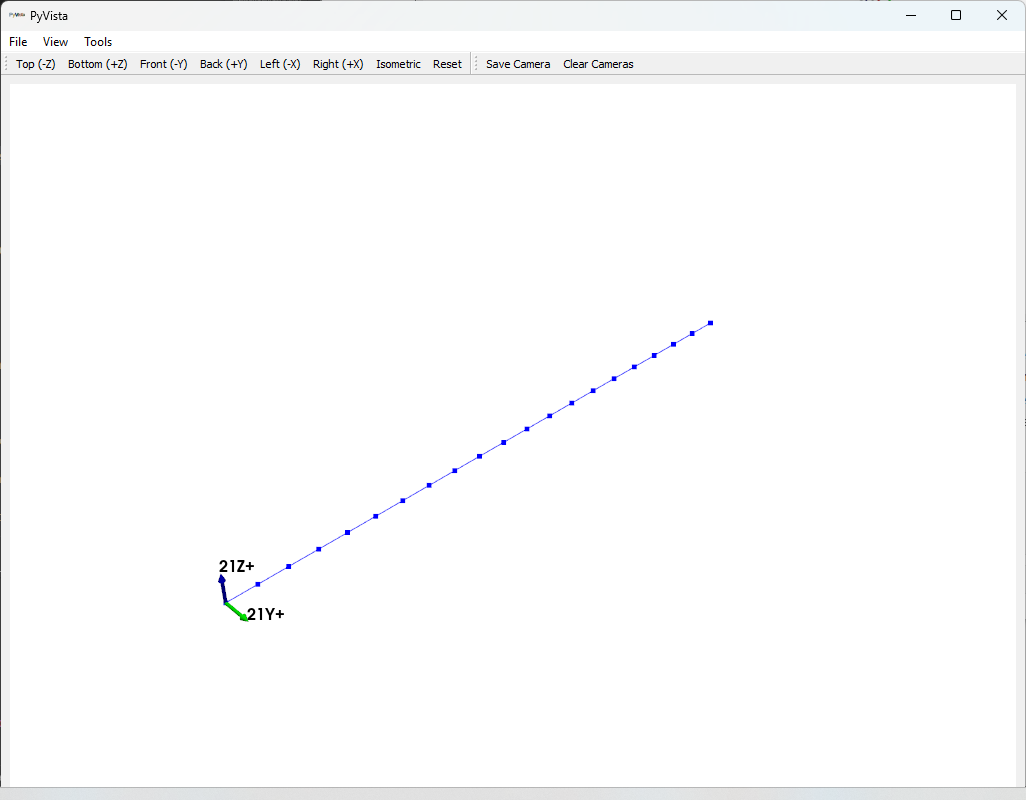

We might also specify the degrees of freedom at which we would like responses.
One could argue that it is quite difficult to measure rotations of a structure,
so we could construct our simulation such that it only returns the translational
degrees of freedom.  We can easily get a list of all translational degrees of
freedom using the 
[`sdpy.coordinate.from_nodelist`](#api:sdynpy.CoordinateArray.from_nodelist)
function, which accepts a list of nodes and returns translational degrees of
freedom (by default, though can be modified) at each node in the list.  We can
generate this list of node identification numbers from our ``geometry`` object.


In [73]:
response_dofs = sdpy.coordinate.from_nodelist(geometry.node.id)
geometry.plot_coordinate(response_dofs,label_dofs=True,arrow_scale=0.025);

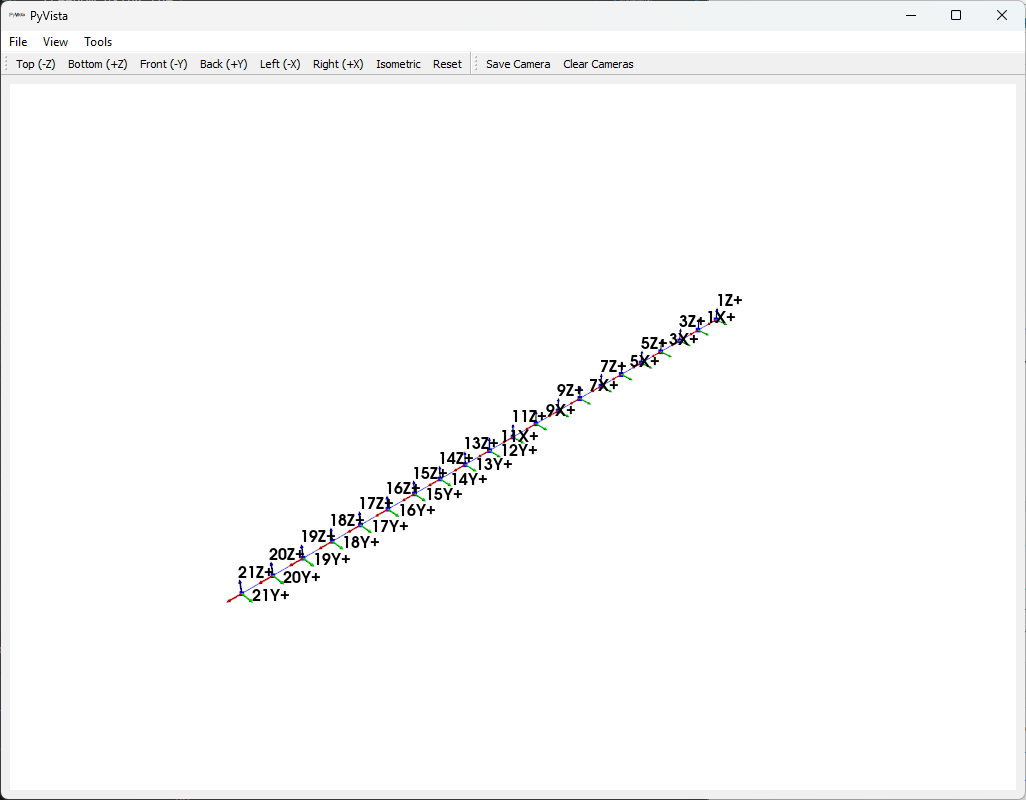

We can then integrate equations of motion for the system using the
[`time_integrate`](#api:sdynpy.System.time_integrate)
method of the [`System`](#api:sdynpy.System).  Note
that SDynPy allows users to select response degrees of freedom that are
displacements, velocities, or accelerations.  These are specified by a
dictionary with keys being the displacement derivative and
values being a [`CoordinateArray`](#api:sdynpy.CoordinateArray)
specifying the degrees of freedom desired with that derivative.  For example,
a key of 2 denotes the second derivative of displacement, which will be an
acceleration.

In [74]:
abscissa = np.arange(total_samples)*dt
forces = sdpy.time_history_array(abscissa,signals,excitation_dofs[:,np.newaxis])
response_dict = {2:response_dofs}

responses = modal_system.time_integrate(
    forces, response_dict,
    integration_oversample = 10)

The ``integration_oversample`` keyword determines the degree of oversampling
that occurs in the integration.  The defined forces used a sample rate of
8000 Hz, so an oversample value of 10 will result in an integration time step
of 80000 steps per second of integration time.  One must be wary of using this
keyword argument, as it relies on zero-padding the Fourier Transform of the
signal, which is not an appropriate approach to oversample certain functions.
For example, if the excitation is a ramp, this zero-padding will produce
strange end effects.  If such a signal is used as the excitation, it is
recommended to simply generate the signal such that it is already oversampled,
and not use the ``integration_oversample`` argument of this function.
Note also that the
[scipy.signal.lsim](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.lsim.html)
function is used to perform the integration, so a factor of 10x is generally
sufficient for integration accuracy due to the linear system assumption.

Let's investigate the output of the
[`time_integrate`](#api:sdynpy.System.time_integrate)
method.  The output ``responses`` was produced in addition to the 
constructed ``forces`` time history.

In [75]:
responses

TimeHistoryArray with shape 63 and 60000 elements per function

In [76]:
forces

TimeHistoryArray with shape 2 and 60000 elements per function

Here we see that there are 63 response signals, and 2 force signals.
Here is an example where using the basic
[`plot`](#api:sdynpy.NDDataArray.plot) method of the 
[`TimeHistoryArray`](#api:sdynpy.TimeHistoryArray) object
may be unsatisfactory, as too many lines will be plotted on the figure.  Instead
we will use the interactive 2D plotter
[`GUIPlot`](#api:sdynpy.GUIPlot), which will allow us to
interactively chose which signals to show.

In [77]:
gp = sdpy.GUIPlot(responses);

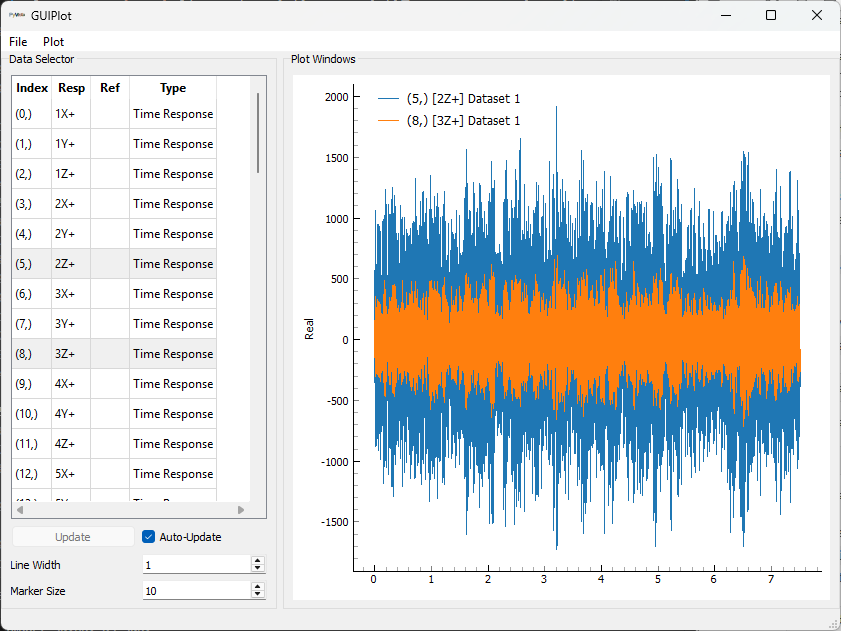

:::{warning} Disappearing Windows
Users may find that their interactive windows may immediately disappear upon creation.  The cause of this is often Python's garbage collector.  Python detects when a given piece of memory is no longer being used (e.g., the variable it was assigned to was deleted or the function in which it was defined ended).  If a user does not assign a window like [`GUIPlot`](#api:sdynpy.GUIPlot) to a variable, or if the variable it is assigned to is deleted, Python will "clean up" the memory, meaning the window will be closed.  Therefore, if a window is meant to stay open, a reference to it must be maintained.
:::

Another approach to visualizing the response of the system is to plot the response on the geometry.
Plotting displacements is perhaps more meaningful than plotting accelerations,
which we have computed here.  Nonetheless, it is valuable to show how this
can be done in SDynPy.  The
[`plot_transient`](#api:sdynpy.Geometry.plot_transient)
method of the [`Geometry`](#api:sdynpy.Geometry) object
can be used to show the time responses as displacements on the geometry.

In [78]:
geometry.plot_transient(responses,displacement_scale=0.003);

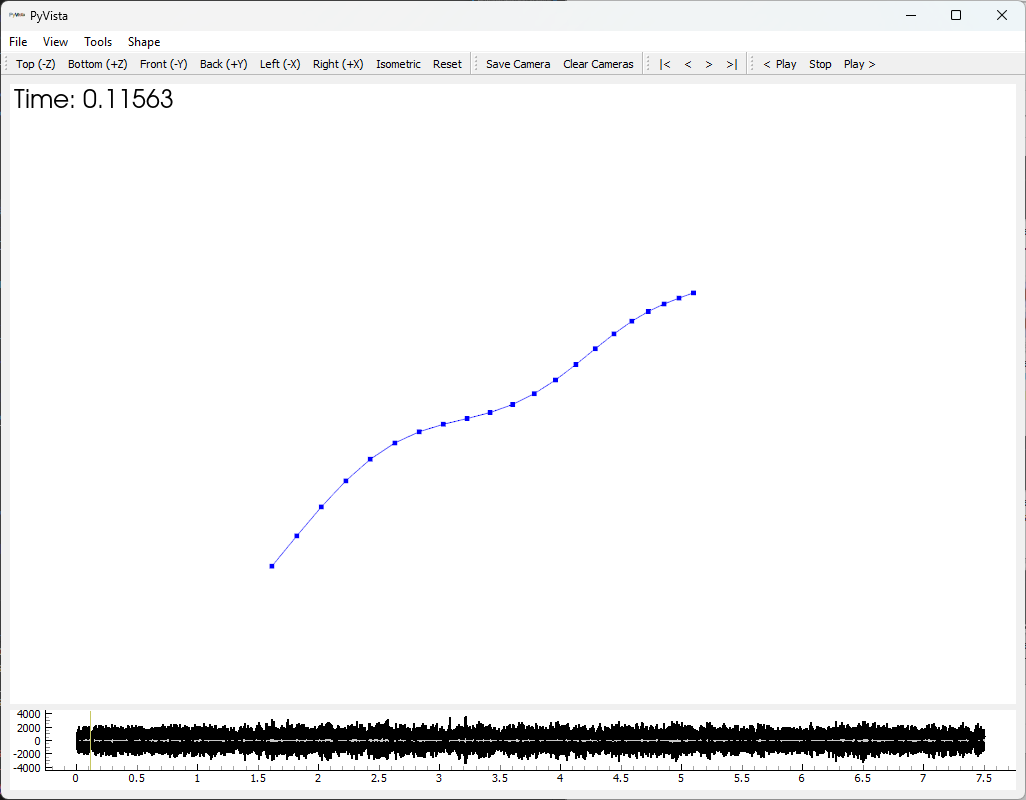

The transient plotter is similar to the mode shape plotter shown previously,
except instead of animating a single shape vibrating back and forth, it animates
a series of shapes one after another.  The user can adjust the current timestep
using the ``|<``, ``<``, ``>``, or ``>|`` buttons, or by sliding the cursor
across the time history representation at the bottom of the window.
The animation can be started by clicking one of the ``< Play`` or ``Play >``
buttons, which will plan the animation in reverse or forward, respectively.  The
animation can be stopped by clicking the ``Stop`` button.  The ``Shape`` menu
has options for scaling the displacement level and animation speed, as well as
setting the animation to loop.

## Computing Frequency Response Functions

SDynPy offers several approaches to compute frequency response functions.
These can be computed directly from a
[`System`](#api:sdynpy.System) object using its
[`frequency_response`](#api:sdynpy.System.frequency_response) method,
in which the dynamic stiffness matrix will be inverted and transformations
applied.  Frequency response functions can also be computed from
[`ShapeArray`](#api:sdynpy.ShapeArray) objects using its
[`compute_frf`](#api:sdynpy.ShapeArray.compute_frf) method.
Finally, frequency response functions can be computed from
[`TimeHistoryArray`](#api:sdynpy.TimeHistoryArray) using
the
[`sdpy.TransferFunctionArray.from_time_data`](#api:sdynpy.TransferFunctionArray.from_time_data)
function, or alternatively the
[`SignalProcessingGUI`](#api:sdynpy.SignalProcessingGUI).

### Code-based Frequency Response Function Computations

Let's set up some initial parameters to use to compute frequency response
functions.

In [79]:
df = 1/(dt*samples_per_frame)
frequency_lines = df*(np.arange(samples_per_frame)+1)

Then we can compute the frequency response functions with the approaches
described above.  First we will consider the code-based approaches.

In [80]:
# From the original undamped system
frfs_system = system.frequency_response(frequency_lines,
                                        response_dofs,
                                        excitation_dofs,
                                        displacement_derivative=2)
# From the reduced system with damping added
frfs_modal_system = modal_system.frequency_response(
    frequency_lines,
    response_dofs,
    excitation_dofs,
    displacement_derivative=2)
# From the eigensolution
frfs_shapes = shapes.compute_frf(frequency_lines,
                                 response_dofs,
                                 excitation_dofs,
                                 displacement_derivative=2)
# From time data
frfs_time = sdpy.TransferFunctionArray.from_time_data(
    forces, responses, samples_per_frame,
    overlap = 0.5, window = 'hann')

Before we go too much further, let's explore the
[`sdpy.TransferFunctionArray`](#api:sdynpy.TransferFunctionArray)
object returned by these analyses.  First, by typing the variable name into
the console, we can see the shape of the
[`sdpy.TransferFunctionArray`](#api:sdynpy.TransferFunctionArray)
as well as how many elements (frequency lines) are in each function.

In [81]:
frfs_system

TransferFunctionArray with shape 63 x 2 and 2000 elements per function

We can also examine the ``dtype`` of the 
[`sdpy.TransferFunctionArray`](#api:sdynpy.TransferFunctionArray),
in particular comparing it to that of the
[`TimeHistoryArray`](#api:sdynpy.TimeHistoryArray)

In [82]:
responses.dtype

dtype([('abscissa', '<f8', (60000,)), ('ordinate', '<f8', (60000,)), ('comment1', '<U80'), ('comment2', '<U80'), ('comment3', '<U80'), ('comment4', '<U80'), ('comment5', '<U80'), ('coordinate', [('node', '<u8'), ('direction', 'i1')], (1,))])

In [83]:
frfs_system.dtype

dtype([('abscissa', '<f8', (2000,)), ('ordinate', '<c16', (2000,)), ('comment1', '<U80'), ('comment2', '<U80'), ('comment3', '<U80'), ('comment4', '<U80'), ('comment5', '<U80'), ('coordinate', [('node', '<u8'), ('direction', 'i1')], (2,))])

Because both the
[`sdpy.TransferFunctionArray`](#api:sdynpy.TransferFunctionArray)
``frfs_system`` and the 
[`TimeHistoryArray`](#api:sdynpy.TimeHistoryArray) ``responses``
are subclasses of the base [`NDDataArray`](#api:sdynpy.NDDataArray)
class, which represents all data in SDynPy, they will have the same fields.
However, the shapes and data types of the fields are different.  We see that the
``ordinate`` field of the
[`TimeHistoryArray`](#api:sdynpy.TimeHistoryArray) object
is a floating point number ``f8``, whereas the ``ordinate`` field of the 
[`sdpy.TransferFunctionArray`](#api:sdynpy.TransferFunctionArray)
object is a complex number ``c16``, because in general, frequency response
functions are complex.  Additionally, we see that the the ``coordinate`` field
now no longer has shape ``(1,)``, but now has shape ``(2,)``.  This is because
there are two degrees of freedom associated with each entry in the frequency
response function matrix, a response coordinate and a reference coordinate.

In each of the frequency response functions we have computed, there are
63 responses and 2 forces, meaning a total of 126 frequency response
functions have been generated.  Rather than comparing all of these functions,
we will just compare the drive point frequency response functions.  This can
be easily selected by identifying the functions where the response coordinate
is equal to the reference coordinate (allowing for a difference in sign to occur
between the two).

In [84]:
drive_frfs_system = frfs_system[
    np.where(
        abs(frfs_system.response_coordinate)
        ==
        abs(frfs_system.reference_coordinate))]
        
drive_frfs_modal_system = frfs_modal_system[
    np.where(
        abs(frfs_modal_system.response_coordinate)
        ==
        abs(frfs_modal_system.reference_coordinate))]
        
drive_frfs_shapes = frfs_shapes[
    np.where(
        abs(frfs_shapes.response_coordinate)
        ==
        abs(frfs_shapes.reference_coordinate))]
        
drive_frfs_time = frfs_time[
    np.where(
        abs(frfs_time.response_coordinate)
        ==
        abs(frfs_time.reference_coordinate))]

Alternatively, the [`get_drive_points`](#api:sdynpy.NDDataArray.get_drive_points) method can be used.

In [85]:
drive_frfs_system = frfs_system.get_drive_points()
drive_frfs_modal_system = frfs_modal_system.get_drive_points()
drive_frfs_shapes = frfs_shapes.get_drive_points()
drive_frfs_time = frfs_time.get_drive_points()

We can then plot the drive point frequency response functions on the same plots
to compare them.

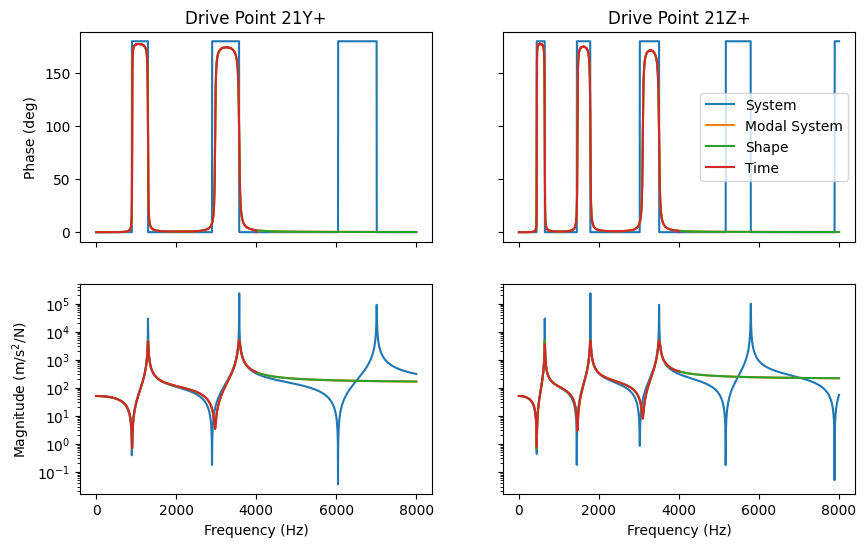

In [86]:
fig,ax = plt.subplots(2,2,sharex=True,sharey='row',figsize=(10,6))
for index,a in enumerate(ax.T):
    for frf in [
        drive_frfs_system,
        drive_frfs_modal_system,
        drive_frfs_shapes,
        drive_frfs_time]:
        a[0].plot(frf[index].abscissa,np.angle(frf[index].ordinate)*180/np.pi)
        a[1].plot(frf[index].abscissa,np.abs(frf[index].ordinate))
        a[1].set_yscale('log')
    a[1].set_xlabel('Frequency (Hz)')
    a[0].set_title(f"Drive Point {frf[index].response_coordinate.string_array()}")
ax[0,0].set_ylabel('Phase (deg)')
ax[1,0].set_ylabel('Magnitude (m/s$^2$/N)')
ax[0,1].legend(['System','Modal System','Shape','Time']);

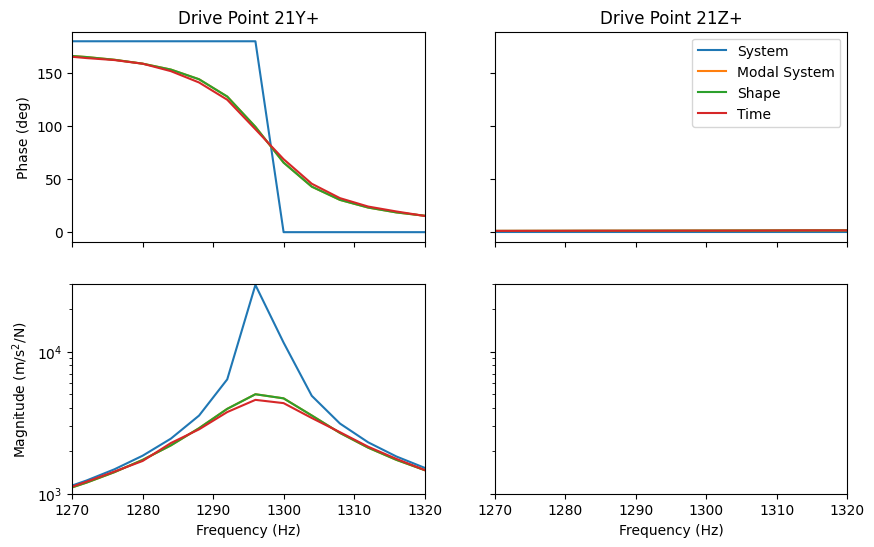

In [87]:
for a in ax.flatten():
    a.set_xlim([1270,1320])
for a in ax[1]:
    a.set_ylim([1e3,3e4])
fig

The most obvious difference between the four plots is in the ``System`` plot.
This original system, derived from a finite element model, had no damping
associated with it.  Therefore the peak is very sharp (indeed, infinitely sharp
if we had plotted with infinite frequency resolution) compared to the other
three where we had added 0.5% modal damping.  The ``Modal System`` and ``Shape``
derived frequency response functions are nominally identical due to them being
constructed from nominally identical data.  Finally, the ``Time`` curve is slightly
more blunt than the ``Shape`` or ``Modal System`` curves due to the artificial
damping added to the system from the Hann window applied during the frequency
response function computation.

If users would like to compare all frequency response functions rather than just
the drive points, the [`GUIPlot`](#api:sdynpy.GUIPlot) is 
again helpful.  Two data sets can be passed simultaneously into the class
to allow for comparisons of large datasets to be performed interactively.
SDynPy by default plots frequency response functions as log magnitude and phase.
However, the complex plotting and logarithmic scaling of the axes can be modified
in the ``Plot`` menu.

In [88]:
gp = sdpy.GUIPlot(
    System = frfs_system,
    Modal_System = frfs_modal_system,
    Shape = frfs_shapes,
    TIme = frfs_time)

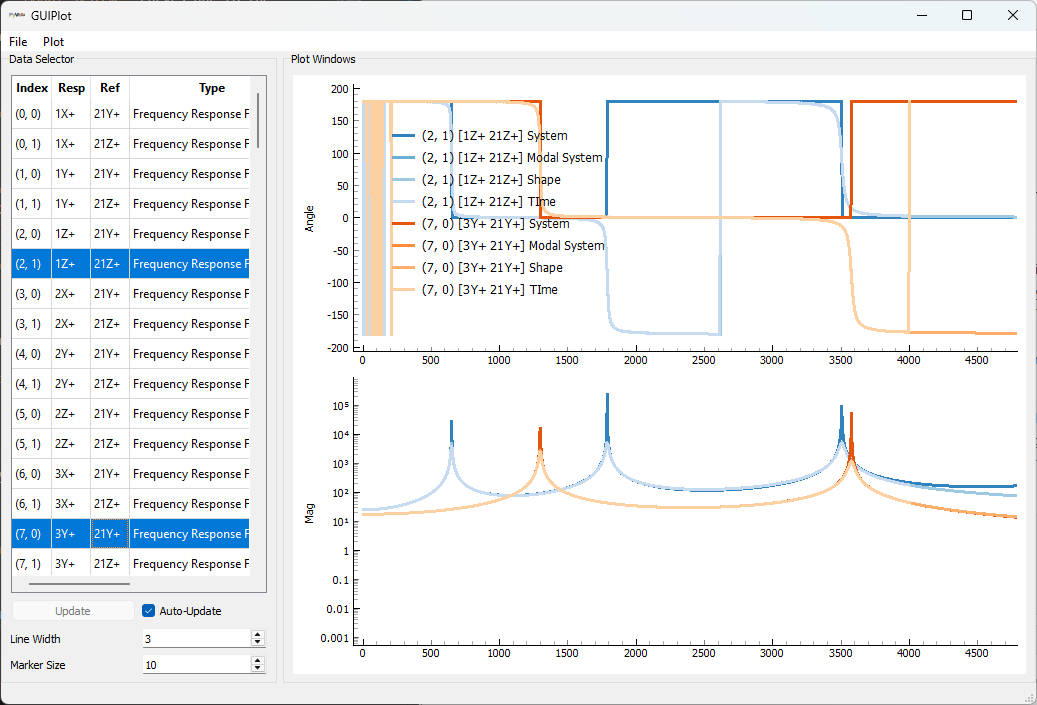

### Mode Indicator Functions

Another way to perform data reduction from a large number of frequency response
functions to an overall view of the system is to compute mode indicator functions.
Most popular are the Complex Mode Indicator Function (CMIF), the Normal Mode Indicator
Function (NMIF), and the Multi-Mode Indicator Function (MMIF).  One may also hear
of the QMIF, which is a variant of the CMIF that is computed using only the
imaginary part of the frequency response function (or real part when considering
velocity/force frequency response functions).

SDynPy can compute the mode indicator functions using the
[`compute_cmif`](#api:sdynpy.TransferFunctionArray.compute_cmif),
[`compute_nmif`](#api:sdynpy.TransferFunctionArray.compute_nmif),
and
[`compute_mmif`](#api:sdynpy.TransferFunctionArray.compute_mmif)
methods of the
[`sdpy.TransferFunctionArray`](#api:sdynpy.TransferFunctionArray)
object.  See their respective documentation for additional arguments that 
can be passed to these functions.

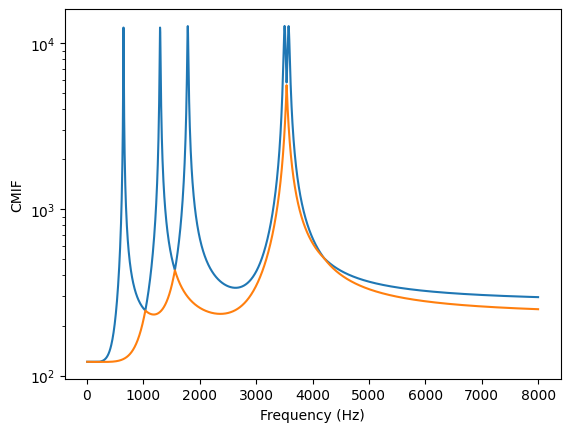

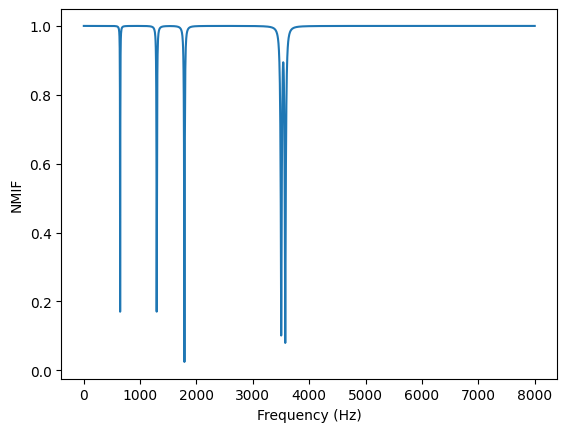

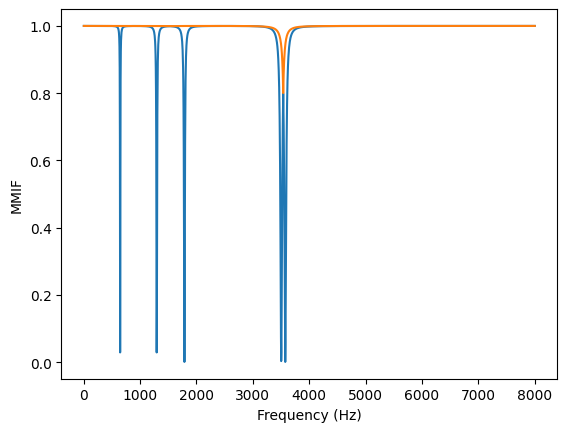

In [89]:
# CMIF
ax = frfs_shapes.compute_cmif().plot()
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('CMIF')
ax.set_yscale('log')
# NMIF
ax = frfs_shapes.compute_nmif().plot()
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('NMIF')
# MMIF
ax = frfs_shapes.compute_mmif().plot()
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('MMIF');

### Graphical Frequency Response Function Computation

While code-based frequency response function computations are nice in that they
can be automated very easily, some users may prefer a more graphical approach.
The [`SignalProcessingGUI`](#api:sdynpy.SignalProcessingGUI)
provides a way to do this.  We pass it all of our time histories (references and
responses) and then a window appears which provides various signal processing
parameters that can be selected.

In [90]:
# Concatenate all time signals into one array
all_time_data = np.concatenate((forces,responses))
# Pass the entire set of time histories into the SignalProcessingGUI
spgui = sdpy.SignalProcessingGUI(all_time_data)
# Assign the geometry to the GUI so we don't have to load it from disk
spgui.geometry = geometry

Type Changed
Overlap Changed
References Changed
Responses Changed
Frame Size Changed
Overlap Changed
Overlap Samples Changed


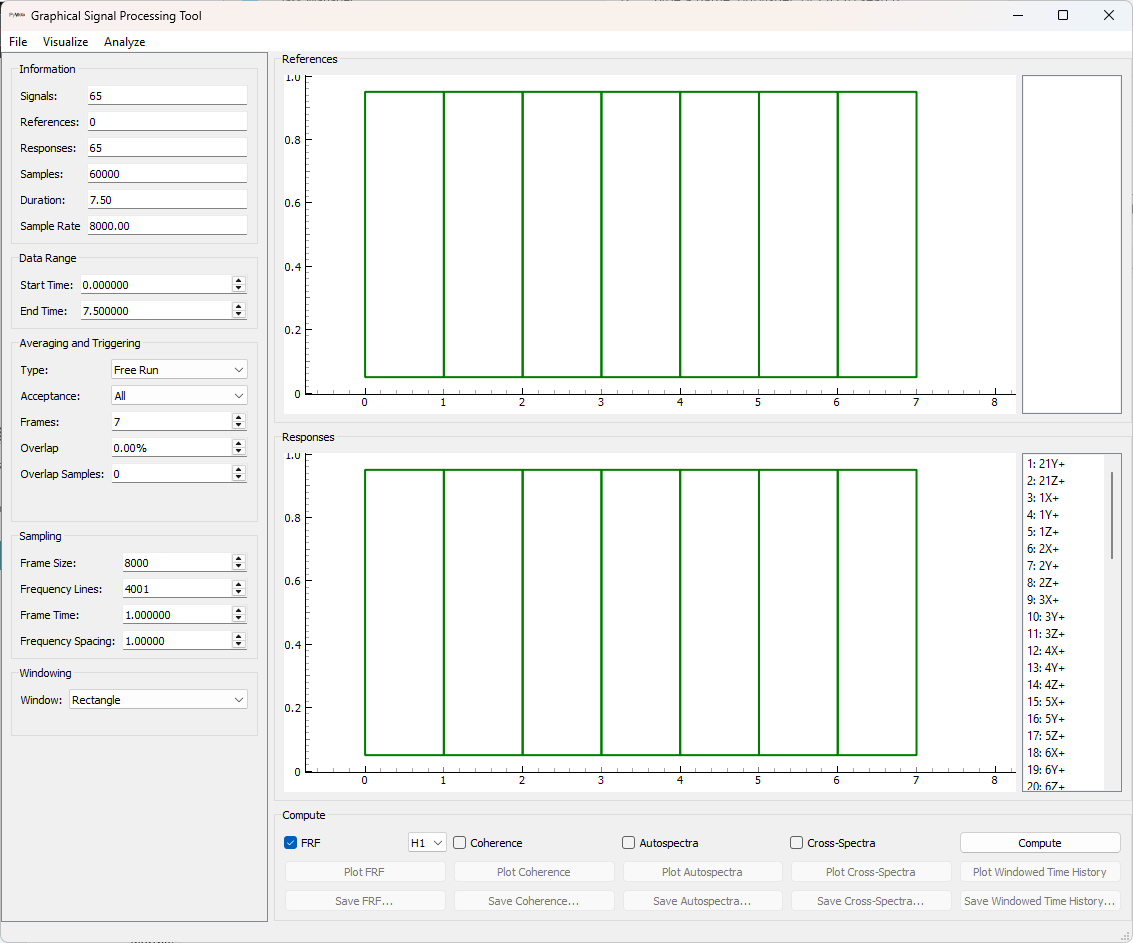

Let's first explore the SignalProcessingGUI Window.  On the top left is a set of ``Information``
about the signals that are loaded.  We see there are 65 signals total, of
which 0 are references and 65 are responses (we will fix this shortly).  There
are 60000 samples for a duration of 7.5 seconds, and the sample rate is 8000 Hz.

Below the information we have the ``Data Range``.  This allows us to select a range
over which the computation will be performed.  This is useful for targetting
portions of an environment, or for discarding portions of data that are not yet
at steady state.

Below that are the ``Averaging and Triggering`` settings.  This allows users to
specify when the frames occur in the signal, either by setting them up every
so many samples, or detecting some kind of trigger signal to use to locate the
measurement frames.

Below that are the ``Sampling`` options, where the frame length is specified.

Finally, the last options are for ``Windowing``.  Certain windows may have extra
parameters that will appear in this box, for example, the decay of an exponential
window.

In the center of the window, we see two plots that are currently empty except
for some green boxes.  These green boxes represent the measurement frames in
the signal.  Currently no signals are plotted, because we have not selected any
signals from the lists on the right side of the window.  There are currently no
signals listed in the ``References`` list; all are currently in the ``Responses``
list.  Signals can be moved from reference to response and vice versa by
double-clicking the signal name in the list on the right side.  Note also that
when a signal is selected, it will be shown in the respective plot.

Finally, on the bottom right corner of the window, we have signal processing
computations that can be performed.  The check boxes denote which functions
to compute when the ``Compute`` button is pressed.  Once a function is computed,
it can be plotted or saved to a file.

There are also menus at the top of the window that contain additional functionality.
The ``File`` menu allows data to be loaded directly from the disk.  The
``Visualize`` menu allows the data to be sent to the transient or deflection shape
plotters once a geometry is loaded (or assigned via code as we have done).
The ``Analyze`` menu allows data to be sent to curve fitting software,
though these are currently disabled until frequency response functions have been
computed.

To start with, we will send our forces, which are the first two signals in the
responses list
to the references list by double-clicking them.  We should now see those signal
as a reference in the top list and plotted in the top plot.
Let's also select the drive point responses in
the bottom list (only single click, not double click) so they are plotted in the
bottom plot.

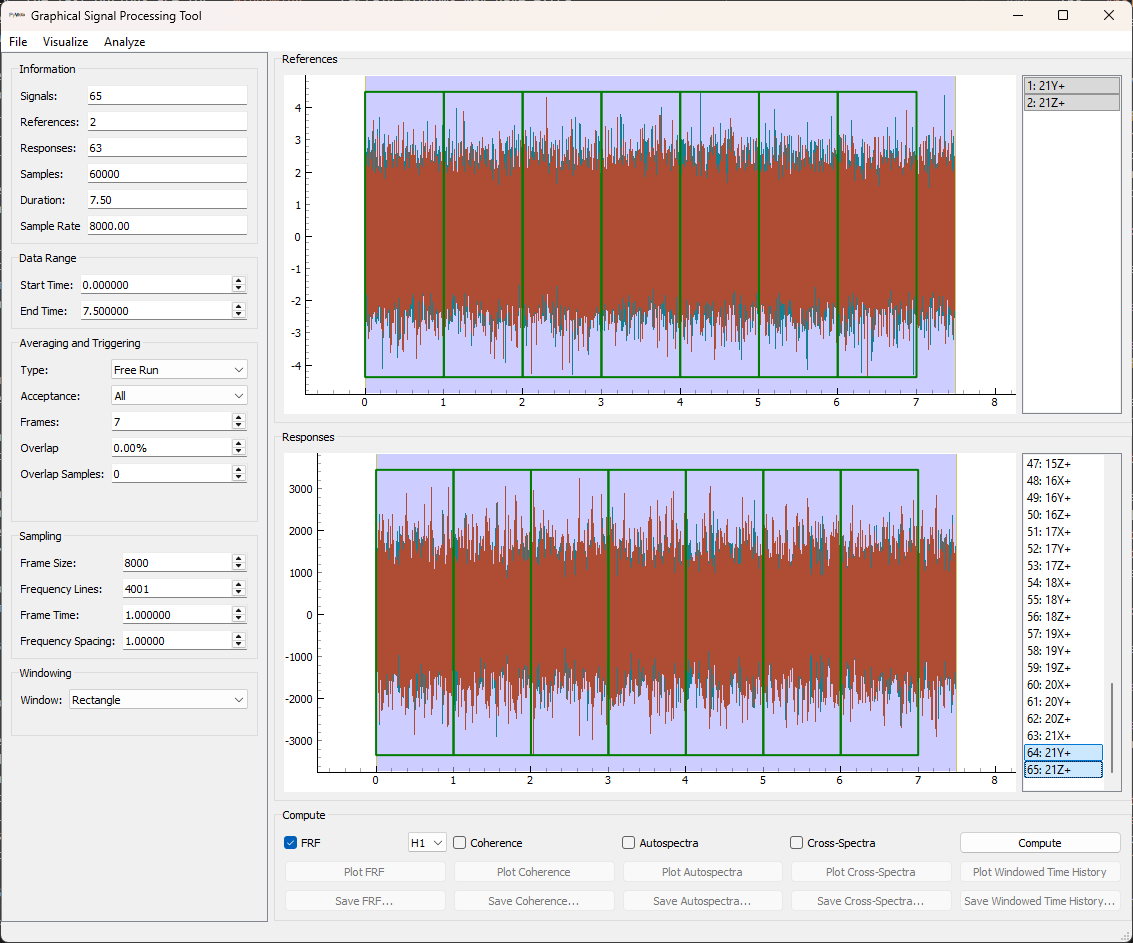

After this step, we should see that the ``References`` box in the ``Information``
section shows ``2`` and the ``Responses`` box shows ``63``.

The next thing we will check is our sampling.  We set up our signals to
provide 2 Hz frequency spacing, so we can set that in the ``Frequency Spacing``
box in the ``Sampling`` section of the window.  Note that this will automatically
adjust all other properties that are determined by the frequency spacing.  For
example, the ``Frame Time`` has adjusted automatically to 0.5 seconds.  You will
also see that the displayed frames on the plots have changed lengths, being now
half the size they were before.

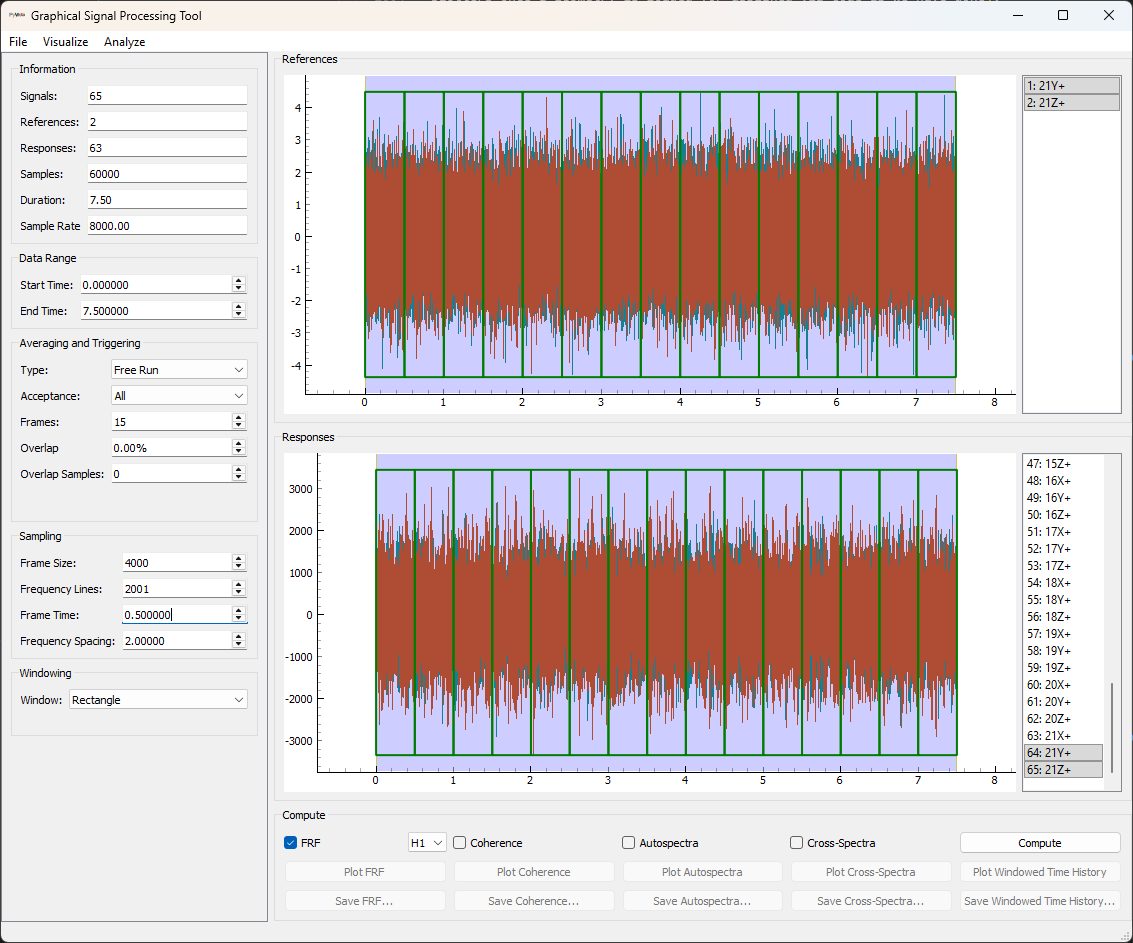

Note that since we have started from zero velocity and displacement, there may
be some start-up transients in the signal.  If we zoom in the the start of the
``Responses`` plot, we can see that it takes approximately 0.05 seconds to get
to a steady-state level.  We can therefore set the ``Start Time`` in the
``Data Range`` section of the window to ``0.1`` seconds, just to be sure we're
at steady state.  We could also perform this operation by dragging the left side
of the blue region in the plot to the position that we desire.  After performing
this operation, we should see that all the green boxes have slide to the right,
starting at the position specified by the ``Start Time``.  We also see that we
have lost a measurement frame that no longer fits at the end of the signal;
can be seen in the ``Frames`` box in the ``Averaging and Triggering`` section,
which has changed from ``15`` to ``14``.

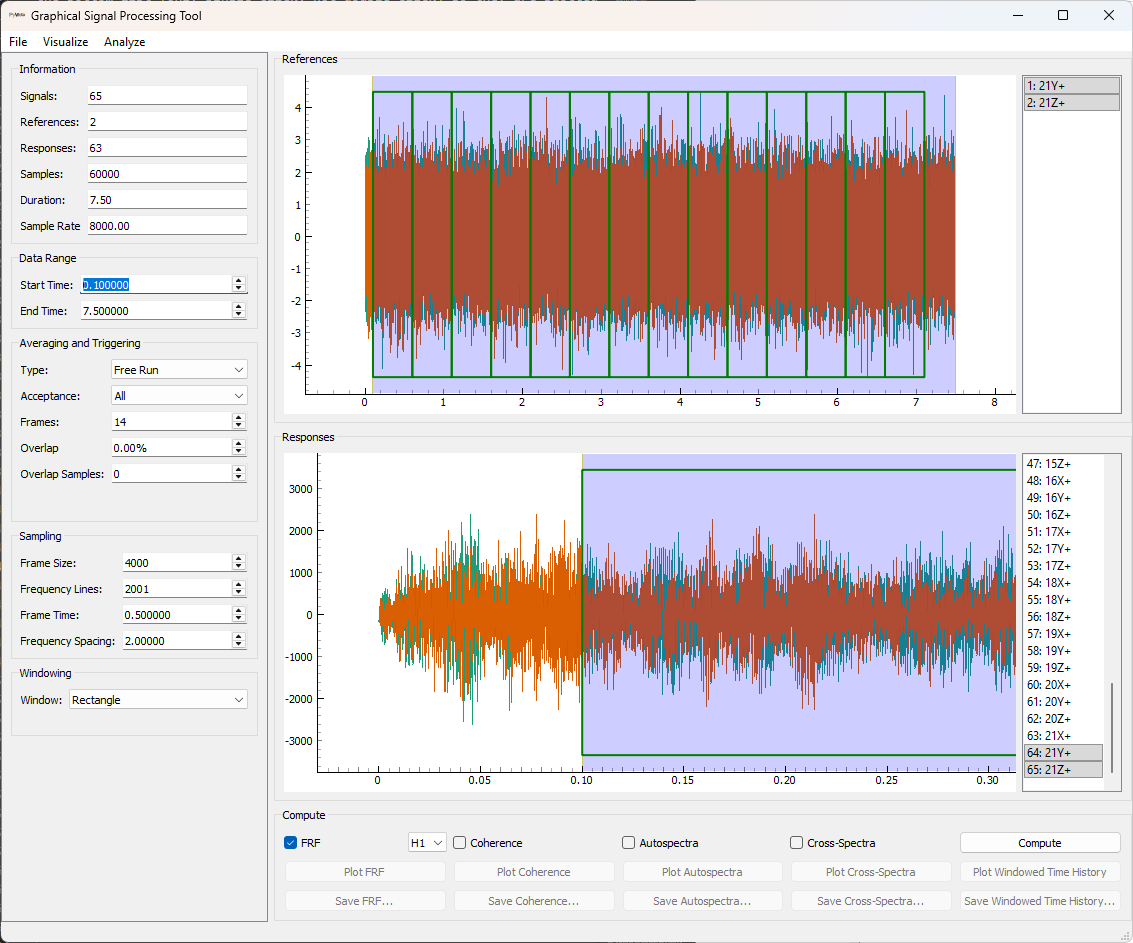

We will then adjust the overlap between measurement frames.  We will set the
``Overlap`` box in the ``Averaging and Triggering`` section of the window to
``50.00%``.  We can see that the green boxes are now overlapping.  This overlap
can be easier to see if you hover the mouse over one of the boxes, which will
cause it to highlight.

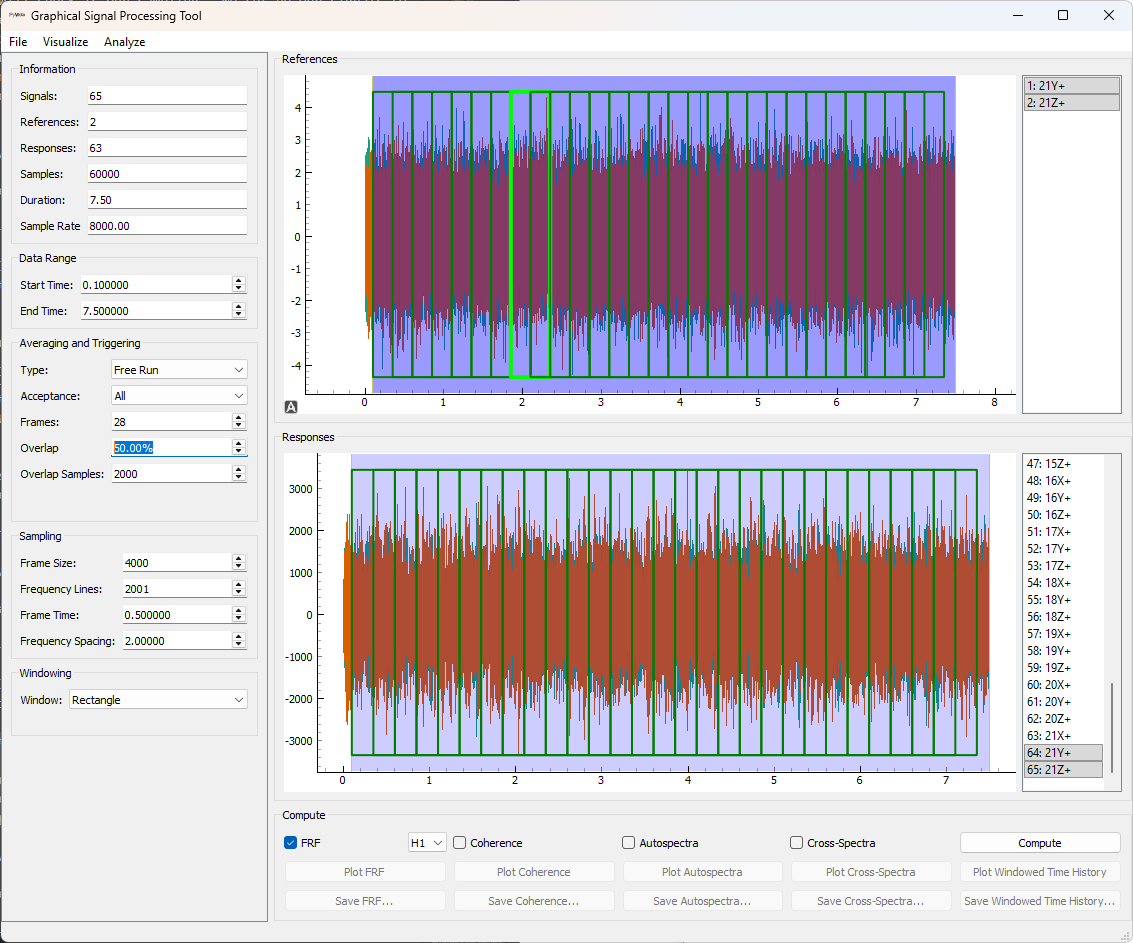

The last setting we will set is the ``Window`` in the ``Windowing`` section
of the window.  We will specify a ``Hann`` window (also known as a Hanning window in some vibration literature).

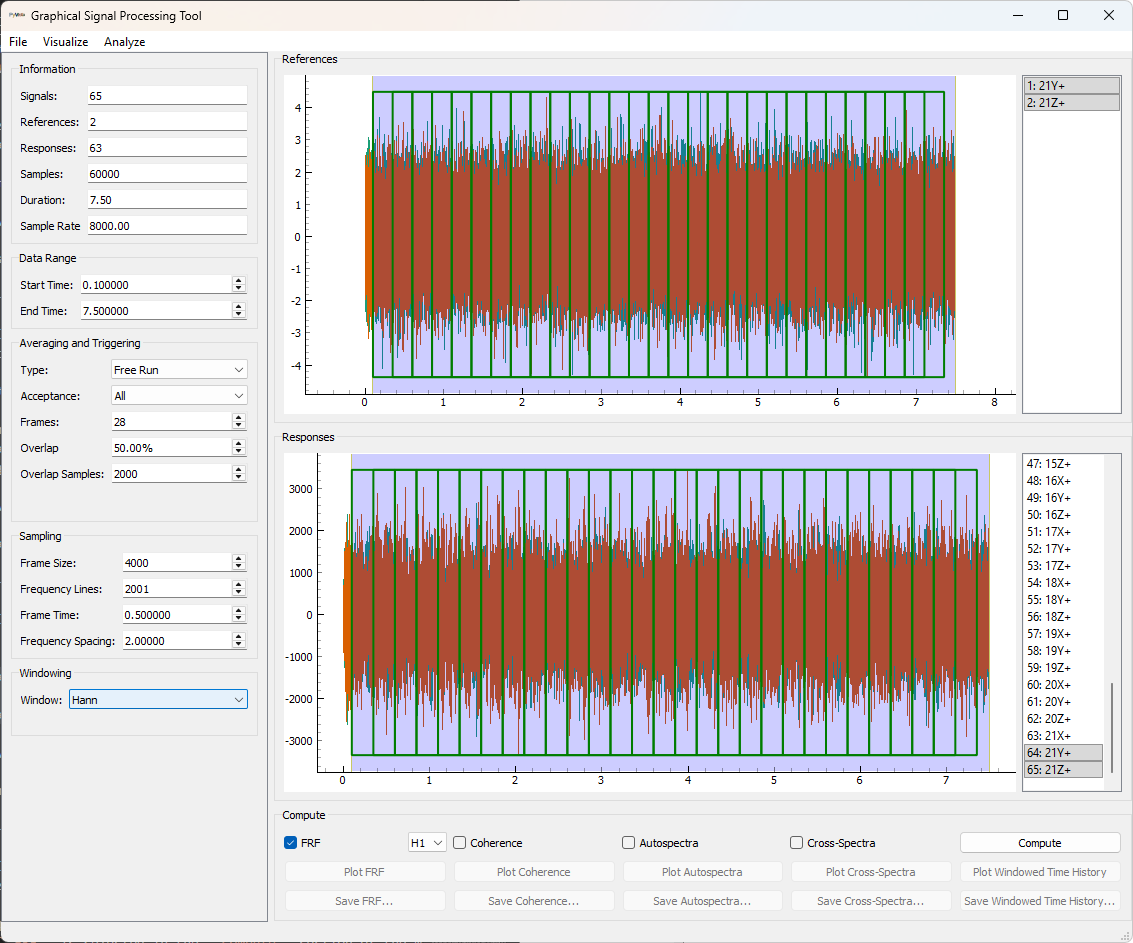

Finally we can compute the frequency response functions.  We ensure that the
check box next to ``FRF`` is selected in the ``Compute`` section of the window.
Additionally, we will compute the coherence by checking the ``Coherence``
checkbox.  We can then press the ``Compute`` button.  When the computations are
finished, the buttons under the computed functions will be enabled, and we can
plot them.

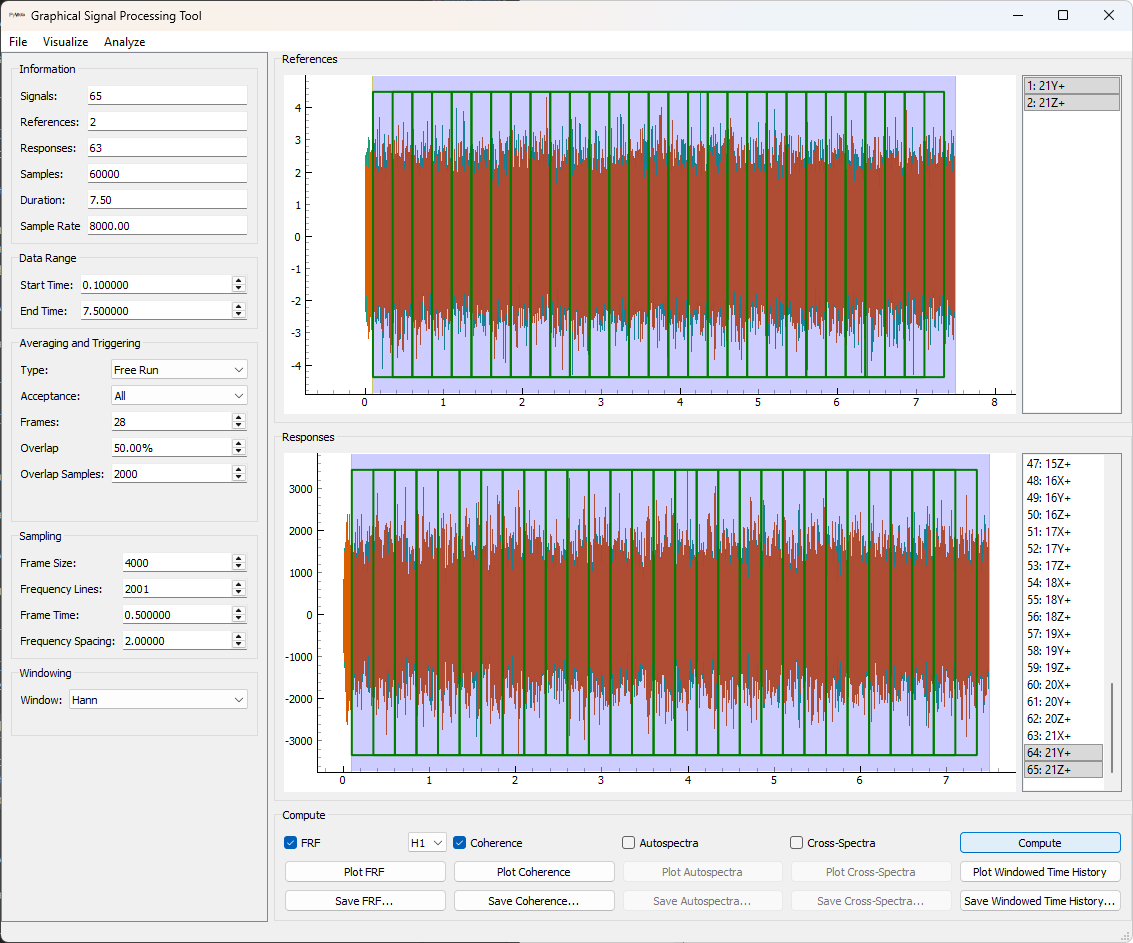

Clicking the ``Plot FRF`` or ``Plot Coherence`` buttons will cause those
plots to appear in a [`GUIPlot`](#api:sdynpy.GUIPlot) window.

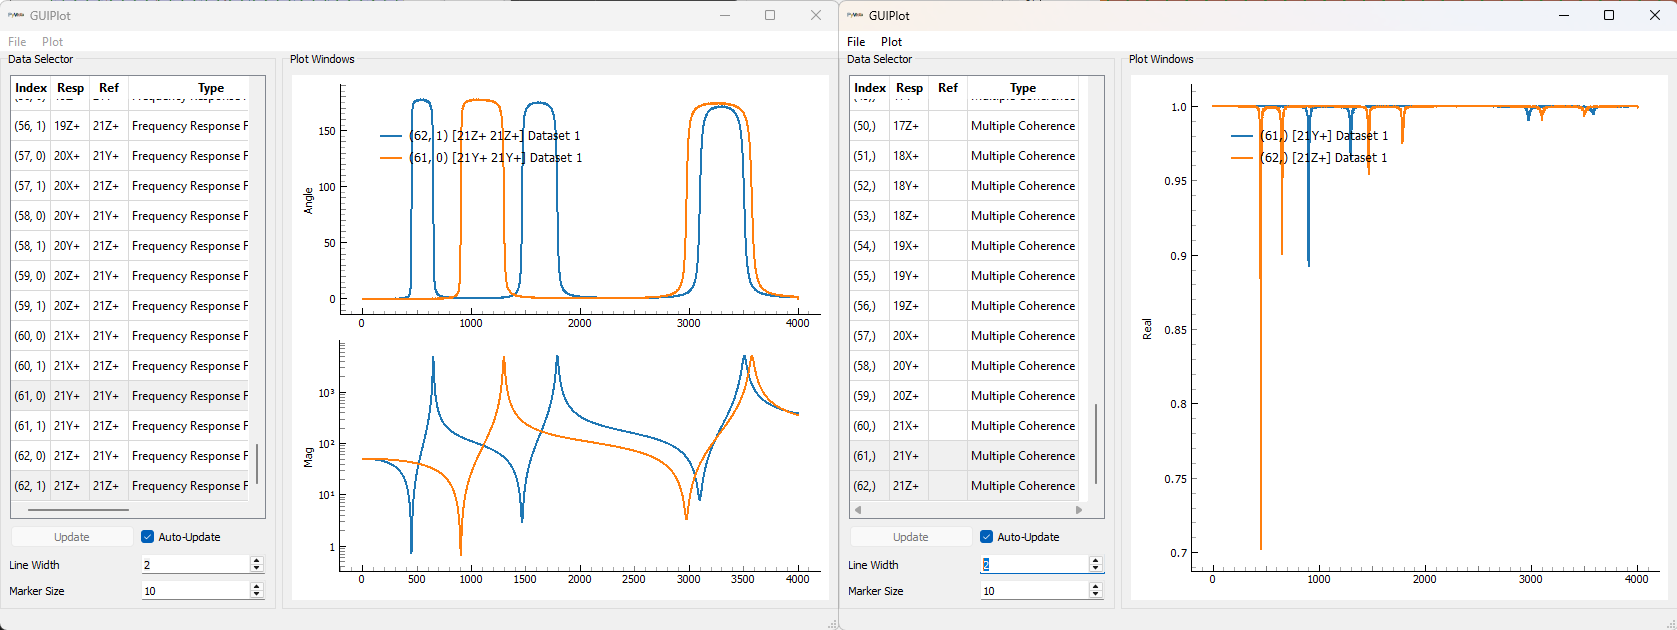

Data can be saved from the
[`SignalProcessingGUI`](#api:sdynpy.SignalProcessingGUI)
window by clicking the ``Save FRF...`` button, and can be re-loaded into SDynPy
using the
[`sdpy.data.load`](#api:sdynpy.NDDataArray.load) function.
In this case, we have saved the file into the current working directory as
``frfs_signalprocessinggui.npz`` so we can load it using

In [91]:
frfs_spgui = sdpy.data.load('frfs_signalprocessinggui.npz')

### Plotting Deflection Shapes

While we could pass these shapes into the modal fitters in SDynPy, the lower-effort
solution could be to simply examine the deflection shapes to pick out approximate
frequencies and deflection shapes of the structure.  We can easily plot
deflection shapes using the
[`plot_deflection_shape`](#api:sdynpy.Geometry.plot_deflection_shape)
method of the [`Geometry`](#api:sdynpy.Geometry) class.
This method accepts a set of spectral data, such as frequency response functions.
However, because the
[`DeflectionShapePlotter`](#api:sdynpy.core.sdynpy_geometry.DeflectionShapePlotter)
will attempt to map responses onto the geometry, we will not be able to plot
multiple references simultaneously, as this will result in frequency response
functions with identical response coordinates.  Because our frequency
response function arrays are already shaped as ``(num_response,num_reference)``,
we can simply index into the last dimension of the array to select single-reference
frequency response functions.

In [92]:
geometry.plot_deflection_shape(frfs_spgui[:,0]);

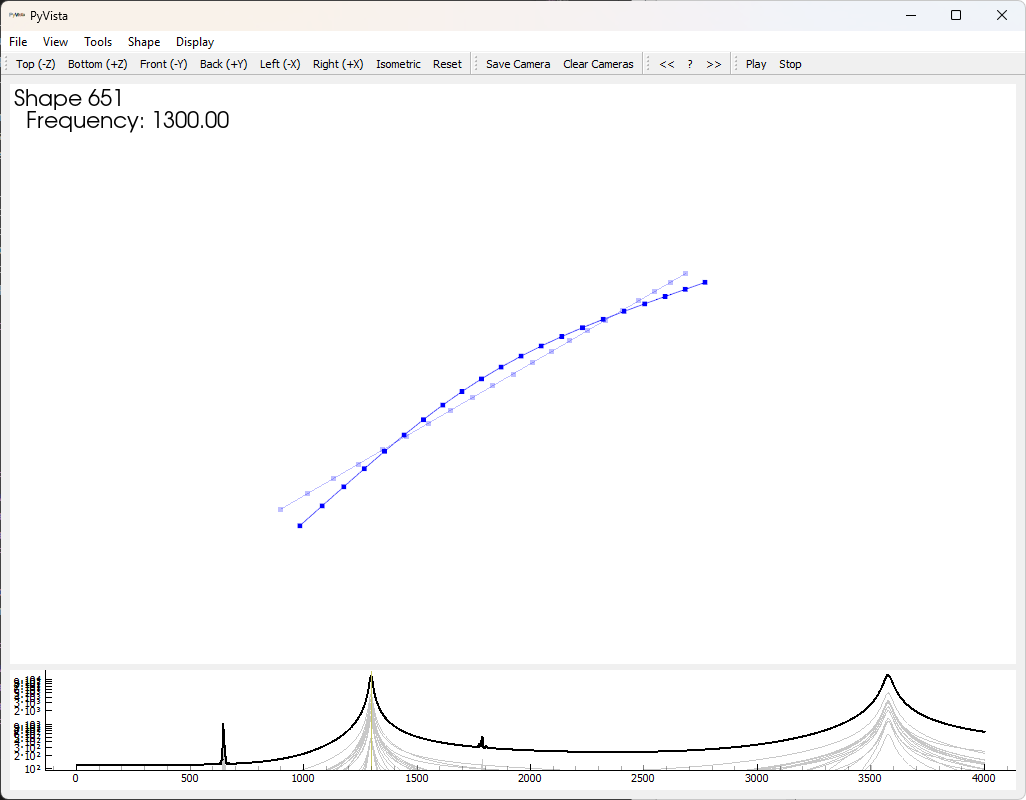

In [93]:
geometry.plot_deflection_shape(frfs_spgui[:,1])

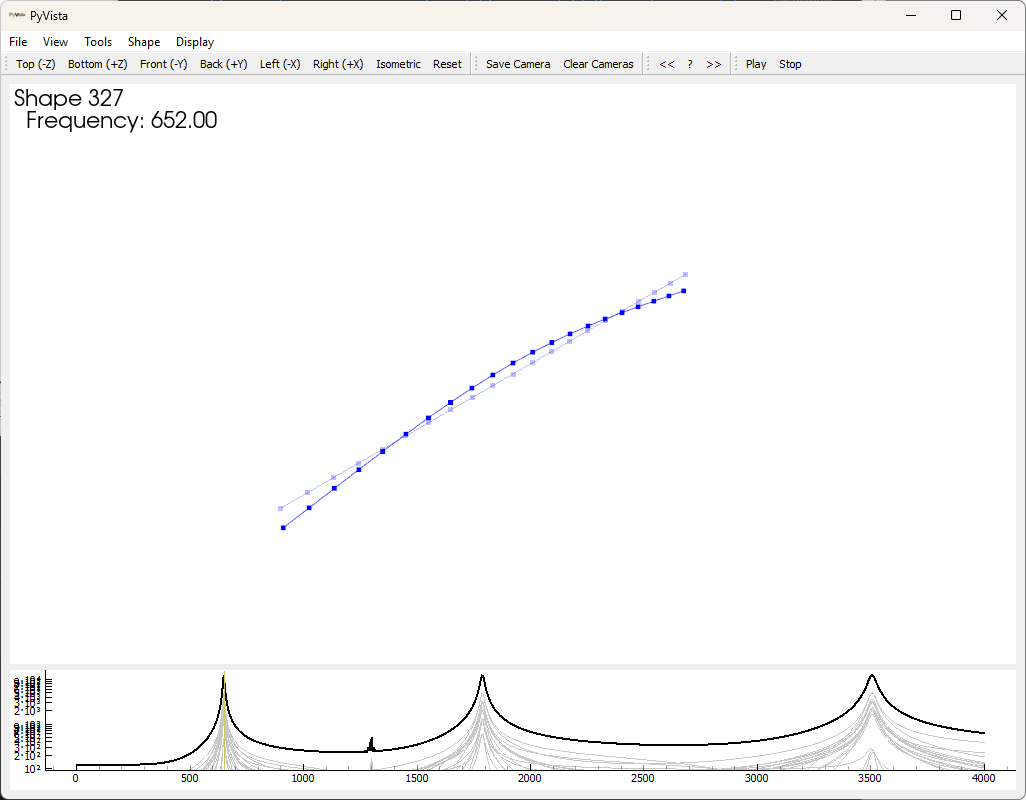

These windows are similar to those of the transient plotter in that the cursor
at the bottom of the window can be used to select the frequency at which the
deflection shape is animated.  The ``<<`` and ``>>`` buttons step left or right
by a single frequency line.  The ``Play`` and ``Stop`` buttons start and stop
the animation, respectively.  Complex display, shape scaling, and animation
speed can be adjusted in the ``Shape`` menu.

Note that you can directly send your frequency response functions to the
[`DeflectionShapePlotter`](#api:sdynpy.core.sdynpy_geometry.DeflectionShapePlotter)
through the ``Visualize`` menu of the
[`SignalProcessingGUI`](#api:sdynpy.SignalProcessingGUI)


## Fitting Modes to Frequency Response Functions

Particularly when performing experimental modal analysis, we will generally
wish to fit modes to the frequency response functions.  Let's look at some of
the tools available to fit modes to frequency response functions in SDynPy.

### PolyPy

PolyPy is a polynomial-based curve fitter, and analysis typically occurs in two
parts.  In the first part, users specify frequency bands of interest as well as
the different polynomial orders to solve.  PolyPy will then solve the polynomial
at those orders and produce a stability diagram, which can help identify real
modes from computation modes.  In the second part, users will pick modes from
the stability diagram to use in the final mode set.  PolyPy will reconstruct
frequency response functions from that set of modes, which can be compared against
the original frequency response functions to judge adequacy of fit.

PolyPy is an implementation of PolyMax [@peeters2004_polymax_frequency_domain_method_new_standard_modal_parameter_estimation].
It is the most mature curve fitter in SDynPy.  It can be run either via code or
via graphical user interface.  We will focus on the graphical user interface
version of the code here, which is accessed via the
[`PolyPy_GUI`](#api:sdynpy.PolyPy_GUI) class.  The class
initializer accepts the frequency response functions as an input.  Again we can
assign geometry to the fitter for shape plotting so we don't have to load it
from disk.

In [94]:
polypy = sdpy.PolyPy_GUI(frfs_spgui)
polypy.set_geometry(geometry)

Alternatively, [`PolyPy_GUI`](#api:sdynpy.PolyPy_GUI)
can be run from the ``Analyze`` menu of the
[`SignalProcessingGUI`](#api:sdynpy.SignalProcessingGUI)
window to stay in graphical user interfaces.  Any geometry loaded into
[`SignalProcessingGUI`](#api:sdynpy.SignalProcessingGUI)
will automatically be sent to the
[`PolyPy_GUI`](#api:sdynpy.PolyPy_GUI).

The initial [`PolyPy_GUI`](#api:sdynpy.PolyPy_GUI) window
is shown below.

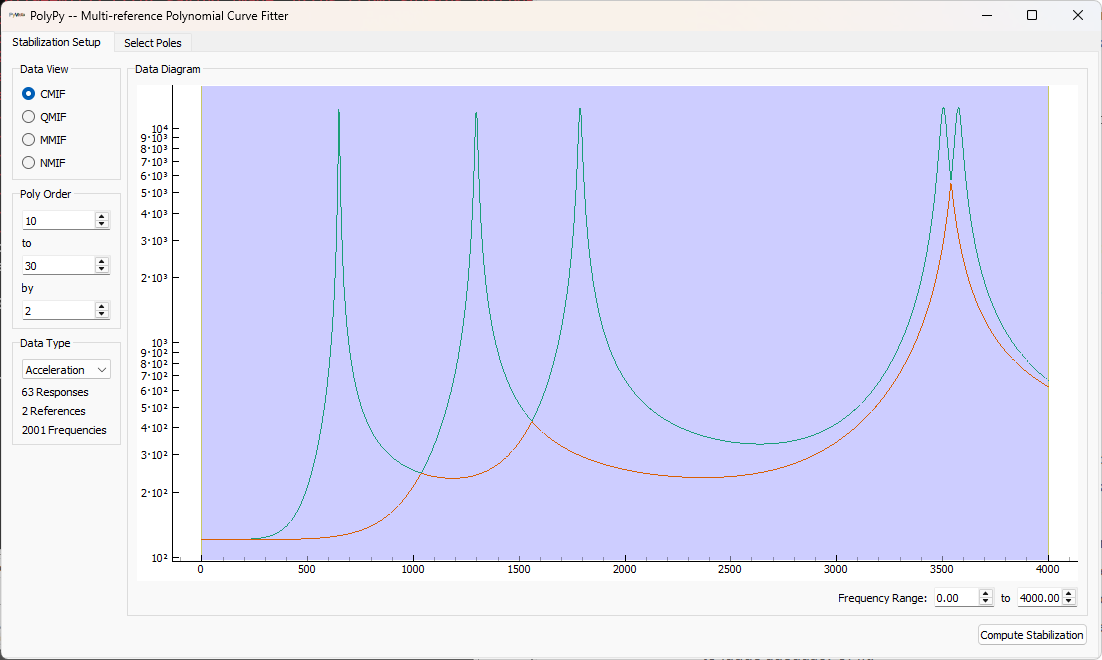

We can see that the window is separated into two tabs, corresponding to the two
main parts of the PolyPy workflow.  The first tab is ``Stabilization Setup``,
which allows the user to select the parameters of the stability calculation.
The second tab is ``Select Poles`` where the final mode set is selected.

Starting with the ``Stabilization Setup`` tab, we see that there is a main plot
in the ``Data Diagram`` section of the  of the window.  This shows the mode
indicator function indicated by the selection in the ``Data View`` section
of the window; currently, the Complex Mode Indicator Function is shown.

The polynomial orders that will be computed in the stability diagram are specified
in the ``Poly Order`` section of the window.  Users can specify the range of
polynomial orders to compute, as well as the step size.  The current values of
``10``, ``30`` and ``2`` will result in computation of polynomial orders 10, 12,
14, ... , 26, 28, and 30.  The ``Data Type`` portion of the window allows
specification of the type of frequency response function that is being analyzed.
In our case, our frequency response function is an Acceleration over Force
frequency response function, so we can leave the default ``Acceleration``
selection.

Below the main plot in the ``Data Diagram`` portion of the window, the
``Frequency Range`` can be specified.  The
[`PolyPy_GUI`](#api:sdynpy.PolyPy_GUI) implementation in
SDynPy allows analyzing multiple frequency ranges separately and then combining
the final selected modes into a single set.  We will demonstrate this capability
here.

We will set the frequency range of the analysis to initially target the first
three modes of the system.  We can do this by adjusting the values of the
``Frequency Range`` boxes, or by dragging the edges of the blue region of the
plot.

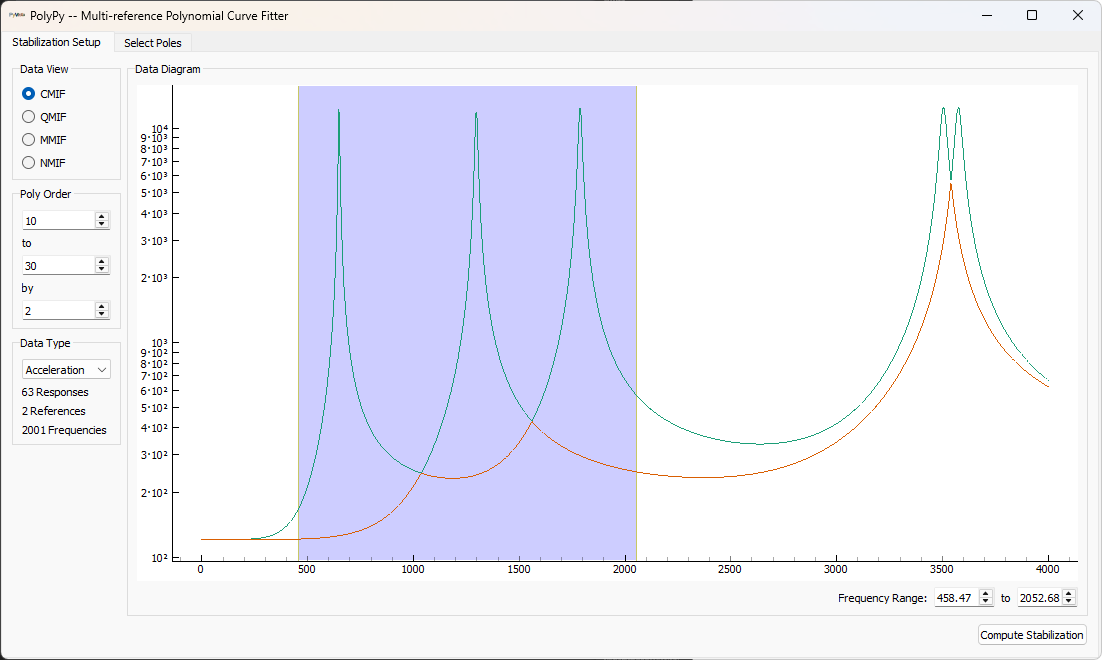



We can then click the ``Compute Stabilization`` button to tell PolyPy to
compute the stabilization diagram for these parameters.  Progress for these
computations is shown in the console window.  After the computations
are performed, the [`PolyPy_GUI`](#api:sdynpy.PolyPy_GUI)
will automatically proceed to the ``Select Poles`` tab.

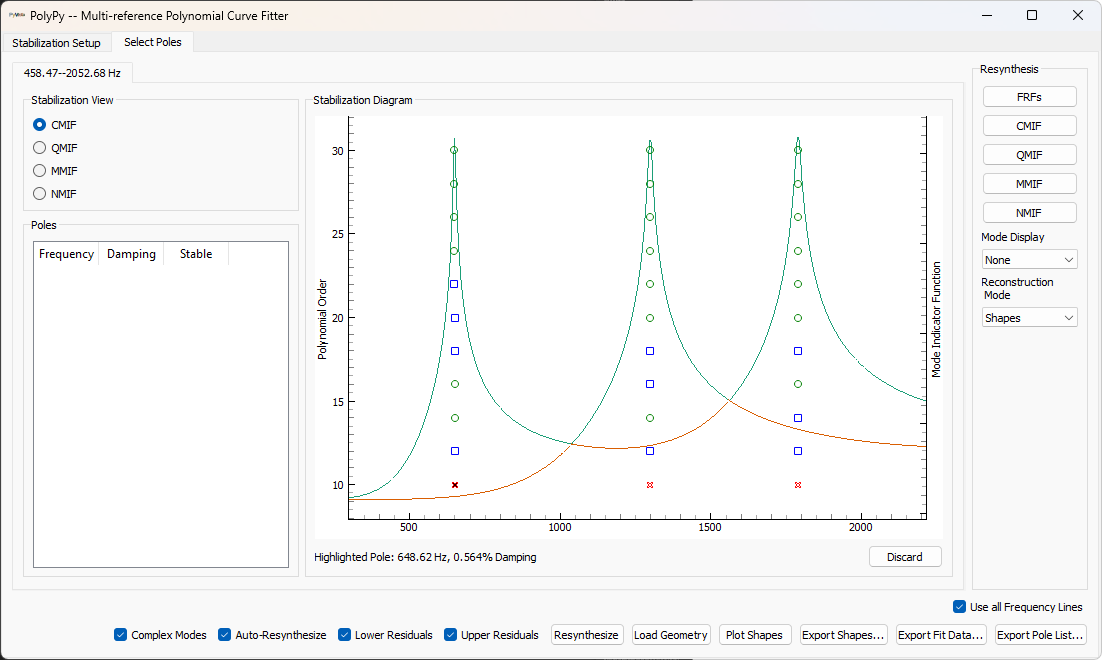

Prominent in this tab is the stabilization diagram, shown in the
``Stabilization Diagram`` portion of the window.  The stabilization diagram
consists of a mode indicator function (similarly chosen by selecting an entry
in the ``Stabilization View`` portion of the window) overlaid with various
markers that represent poles of the system (frequency and damping ratio).  The
color and shape of the poles determine how stable the pole is.  Stability is
computed by how much or little the pole changes as different polynomial orders
are computed.  A real mode will tend to remain unchanged if different order
polynomials are solved.  Computational poles, on the other hand, will tend to
vary as different orders are solved.  In PolyPy, a red X signifies an instable
pole, a blue triangle signifies that the frequency has stabilized, a 
blue square signifies that the frequency and damping have stabilized, and a
green circle signifies that the frequency, damping, and participation factor
of the mode has stabilized.  Generally, we should only select green circles in
the stabilization diagram, preferably at an order where the symbol has been
green for a few orders.

In the [`PolyPy_GUI`](#api:sdynpy.PolyPy_GUI), poles are
selected by clicking on the markers on the stabilization diagram.  When hovering
the mouse over a marker, [`PolyPy_GUI`](#api:sdynpy.PolyPy_GUI)
will report the frequency and damping of that pole in the bottom left corner of
the plot window.  When selected, the marker will turn a solid color, and the
pole will be reported in the table in the ``Poles`` section of the window.

If for whatever reason the stabilization diagram is not useful (perhaps the
wrong polynomial orders were specified) users can click on the ``Discard``
button, which will delete the current stabilization diagram.  The user can then
proceed to the initial tab and select new parameters and recompute the
stabilization diagram.

As modes are selected, the [`PolyPy_GUI`](#api:sdynpy.PolyPy_GUI)
will attempt to resynthesize frequency response functions from the selected shapes.
Options for performing this resynthesis are at the bottom of the window.
The ``Frequency Line Weighting`` specifies how the frequency lines are weighted
when computing mode shapes.  If ``Magnitude`` is selected, larger magnitude
frequency lines are weighted more heavily in the computation.  If ``Uniform``
is selected, all frequency lines are considered equally.  Users can also specify
which frequency lines are used in the computation by adjusting the
``Frequency Lines at Resonance`` and ``Frequency Lines for Residuals`` parameters.
The former specifies how many frequency lines around each pole are used for
computing mode shapes.  This can be useful for analysis with relatively high
noise floors, where the noise in the valleys between the peaks could contaiminate
the estimation of the mode shape.  The latter specifies how many frequency lines
at the beginning and end of the frequency range get included in the mode shape
computation when residuals are computed.  If all frequency lines are desired,
users can simply check the ``Use all Frequency Lines`` checkbox.

Users can switch between real and complex modes by unchecking or checking the
``Complex Modes`` checkbox.  If the ``Auto-Resynthesize`` checkbox is checked,
[`PolyPy_GUI`](#api:sdynpy.PolyPy_GUI) will resynthesize
frequency response functions after each mode is selected.  This can be useful
for smaller systems to see the immediate effect of adding a specific mode; however,
this can slow the analysis down for larger datasets where it can take a non-negligable
amount of time to resynthesize shapes.  If the ``Auto-Resynthesize`` checkbox
is not checked,frequency response functions can be manually resynthesized by
clicking the ``Resynthesize`` button.  Finally, the use of residuals in mode shape
computation can be selected by clicking the ``Residuals`` checkbox.

To see the resynthesized frequency response functions compared to the original
ones, users can click on the buttons in the ``Resynthesis`` portion of the
window.  This will plot the frequency response functions or mode indicator
functions in a separate window.  These plots will be updated automatically
each time frequency response functions are resynthesized.

To start our analysis, let's click the ``CMIF`` button to bring up a the
resynthesized complex mode indicator Function plot.  Initially, just one set of
data will be plotted as we currently do not have any modes selected on the
stability diagram.  Ensure both singular values of the CMIF are selected in the
[`GUIPlot`](#api:sdynpy.GUIPlot) window.  Let's click the
``Use all Frequency Lines`` checkbox as well, and deselect the ``Complex Modes``
checkbox.

Now we will start selecting markers in the stabilization diagram.  Users should
note that the resynthesized CMIF should be updated as additional modes are
selected.  Ensure that green circle markers are selected for each of the three
main peaks in the CMIF.  We will not select one of the green circles around
2340 Hz, as there is no peak in the CMIF to indicate a real mode at that frequency.

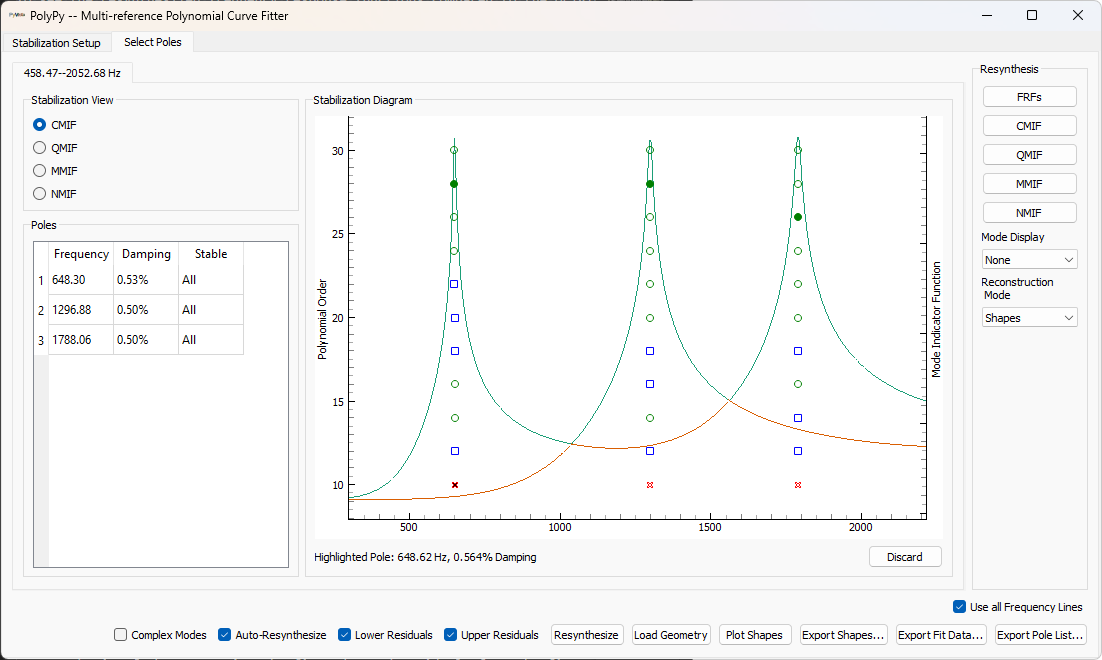


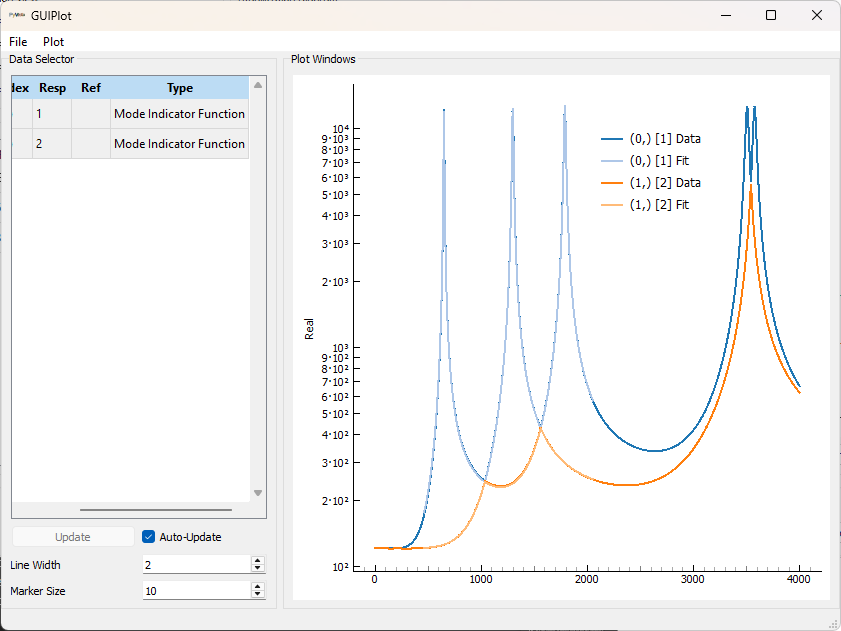

Given that this is a purely synthetic dataset, very good fits to the data
should be achievable, as shown in the previous figure up to 2200 Hz.  However,
we still have the peaks between 3000 and 4000 Hz to fit, so let's do that now.

Return to the ``Stabiliziation Setup`` tab (do not discard the previous
stabilization diagram by pressing the ``Discard`` button!).  We will now
set up an analysis targetting the missing modes.  We can adjust the blue region
from approximately 3000 to 4000 Hz to target these peaks.

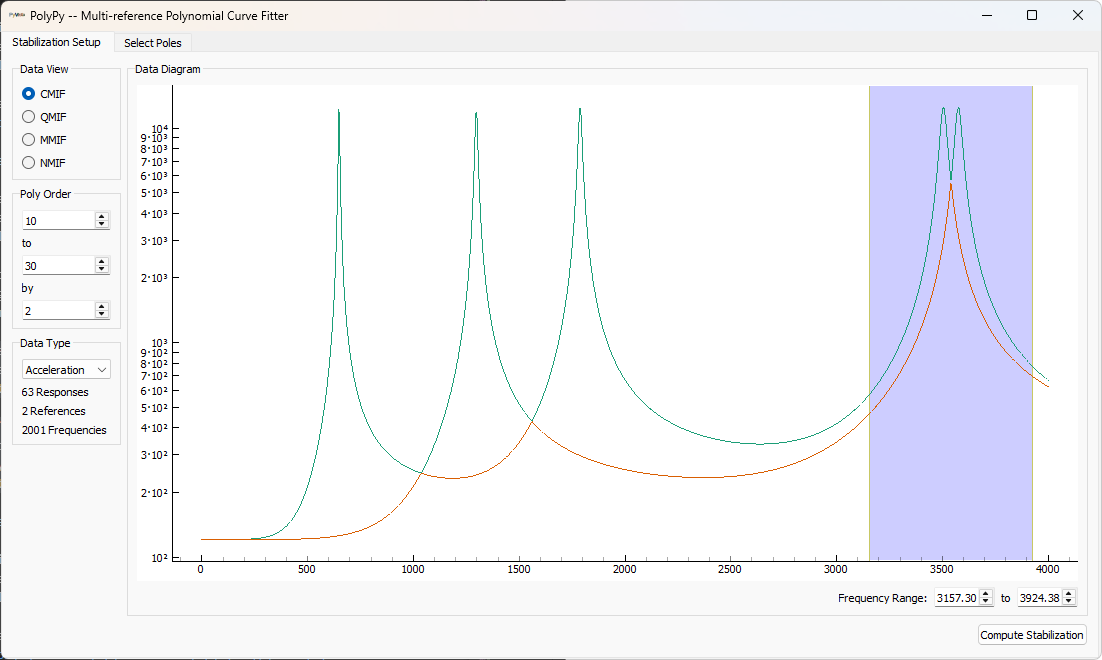

We can then again click the ``Compute Stabilization`` button, which will
bring us again to the ``Select Poles`` tab.  Note here that we now have two
sub-tabs on this window, each representing a different frequency range that
we analyzed.  The first region is on the ``458.47--2052.68 Hz`` tab, and the
second is on the ``3157.30--3924.38 Hz`` tab.  Note the exact values will differ
depending on the exact frequency range selected.

We can then continue selecting modes in this frequency range.  We will pick the
green circles corresponding to the strong peaks in the CMIF.  As we pick markers
in this frequency range, we should see the modes be combined with the modes
from the previous region when the resynthesis is occuring.

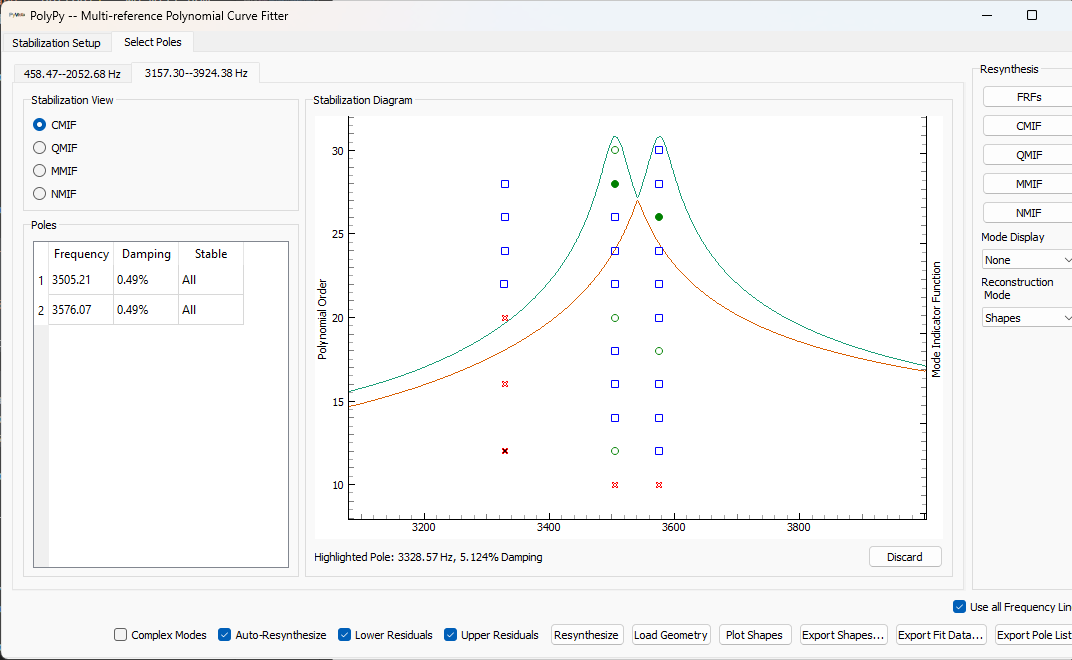

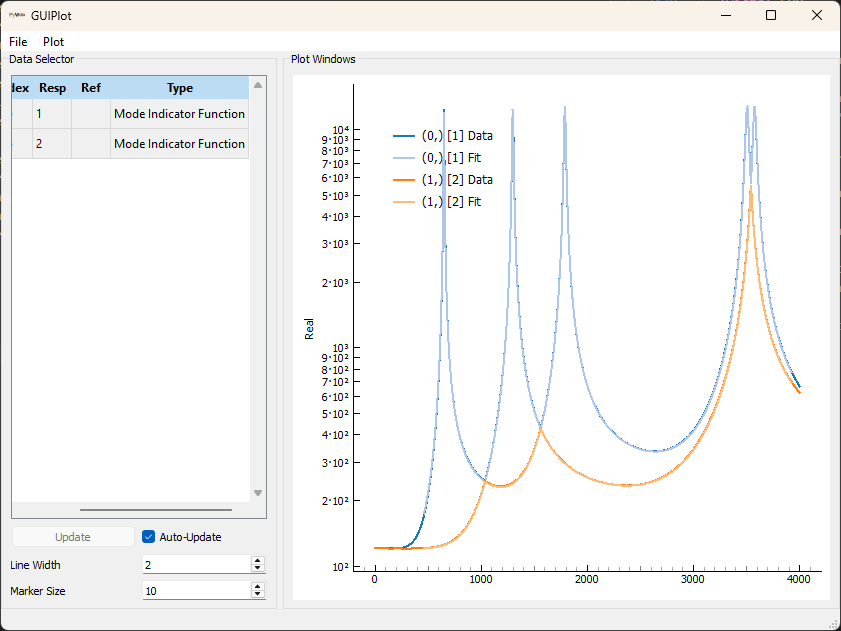

Clearly we have achieved very good fits, which is expected due to the synthetic
data set.

With modes fit, we can plot the mode shapes by selecting the ``Plot Shapes``
button.  Note that had we not assigned geometry to the
[`PolyPy_GUI`](#api:sdynpy.PolyPy_GUI)
using its
[`set_geometry`](#api:sdynpy.PolyPy_GUI.set_geometry)
method, we would need to first load geometry using the ``Load Geometry`` button
prior to being able to plot shapes.  An example mode shape is shown below.

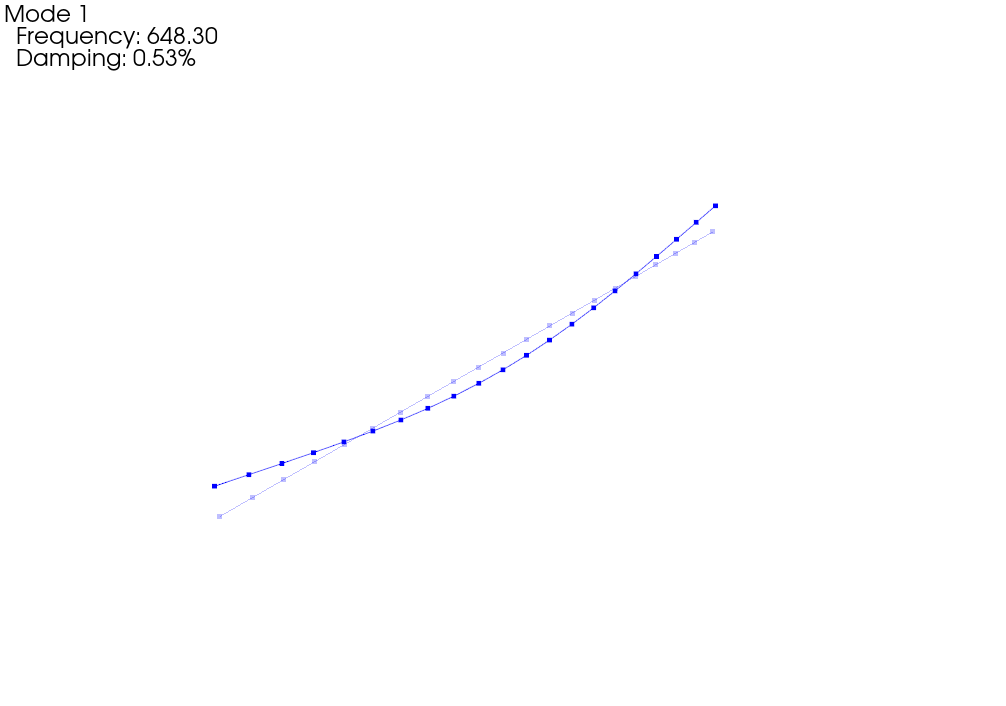

We will then save the shape files to disk by clicking the ``Export Shapes...``
button.  We will save the shapes to a file ``shapes_polypy.npy``.  If we also
wanted to save the resynthesized frequency response functions, we could click
the ``Export Fit Data...`` button, which saves a much more complete data set
to disk.

### Synthesize Modes and Correlate

The second curve fitter available in SDynPy is Synthesize Modes and Correlate
(SMAC) [@hensley2006_SMAC].  SMAC is a modal-filter based curve fitter.  
While it is not as polished as the PolyPy curve fitter, it can often provide
better fits than PolyPy if the data quality is not as good.  Simlar to PolyPy,
SMAC can be run both via code or via graphical user interface.  We will
demonstrate the latter here using the 
[`SMAC_GUI`](#api:sdynpy.SMAC_GUI) class.  Again, we can
assign geometry directly to the [`SMAC_GUI`](#api:sdynpy.SMAC_GUI)
object so we don't need to load from disk.

In [95]:
smac = sdpy.SMAC_GUI(frfs_spgui)
smac.geometry = geometry

Similarly to PolyPy, the [`SMAC_GUI`](#api:sdynpy.SMAC_GUI)
is separated into different tabs representing different portions ofthe workflow.

The first tab, ``Pseudoinverse`` is where the pseudoinverse of the frequency
response function matrix is performed.  At this stage, we need to specify the
frequency range we are working over, as well as the data type, and whether 
or not complex modes will be fit.  To keep a similar analysis to that in PolyPy,
we will choose ``Normal Modes`` rather than ``Complex Modes``.  We will set the
``Frequency Range`` from ``260`` to ``4000`` Hz, and we will keep the ``Data Type``
as ``Acceleration``.

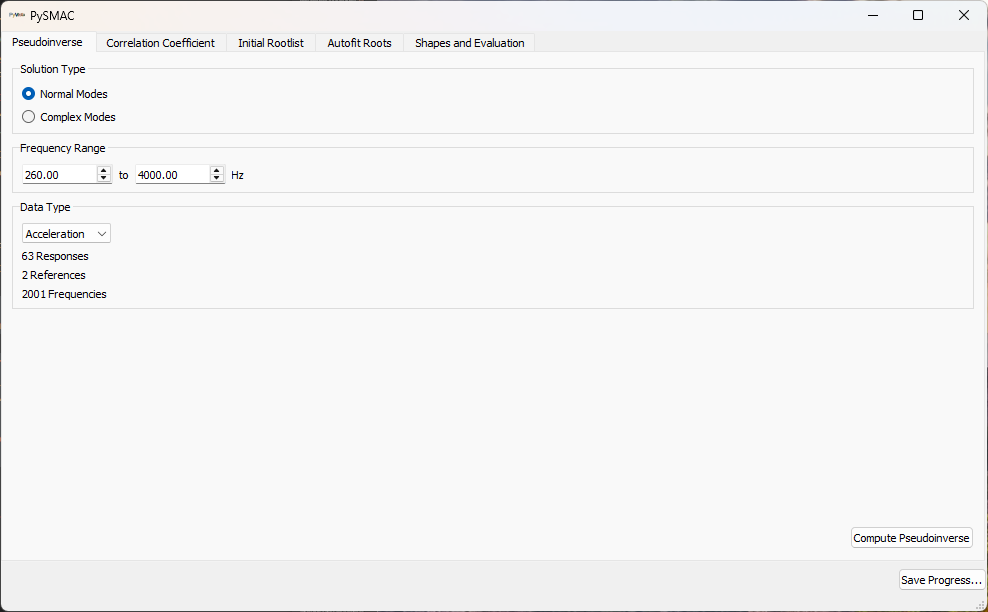

When this is set correctly, we can press the ``Compute Pseudoinverse`` button
to perform the computation and move to the next tab.

The next tab is the ``Correlation Coefficient`` tab.  SMAC finds modes by comparing
what a mode *should look like* to what the frequency response functions *do look
like* to identify where modes are in the frequency response function.  It uses
the correlation coefficient to make these comparisons.  Where the correlation
coefficient approaches 1.0, one can be reasonably certain a mode is present.
Where the correlation coefficient is far from 1.0, a mode is not likely present.
SMAC generally guesses a large number of frequencies and damping values, finds
where the correlation coefficient is high, and then narrows in to converge on a
mode.  The ``Correlation Coefficient`` tab sets up the initial set of guesses
that SMAC makes.  The frequency resolution of the initial guesses is set via the
``Frequency Spacing`` value, and the ``Lines to use in Correlation Computation``
value specifies how many frequency lines around each frequency guess get used
to compute the correlation coefficient.  Also specified is an initial guess for
damping.  In the present case, we know the damping because we specified it to be
0.5%.  In a real situation, we generally would not know this information a priori.
Therefore we will leave this page with default values.

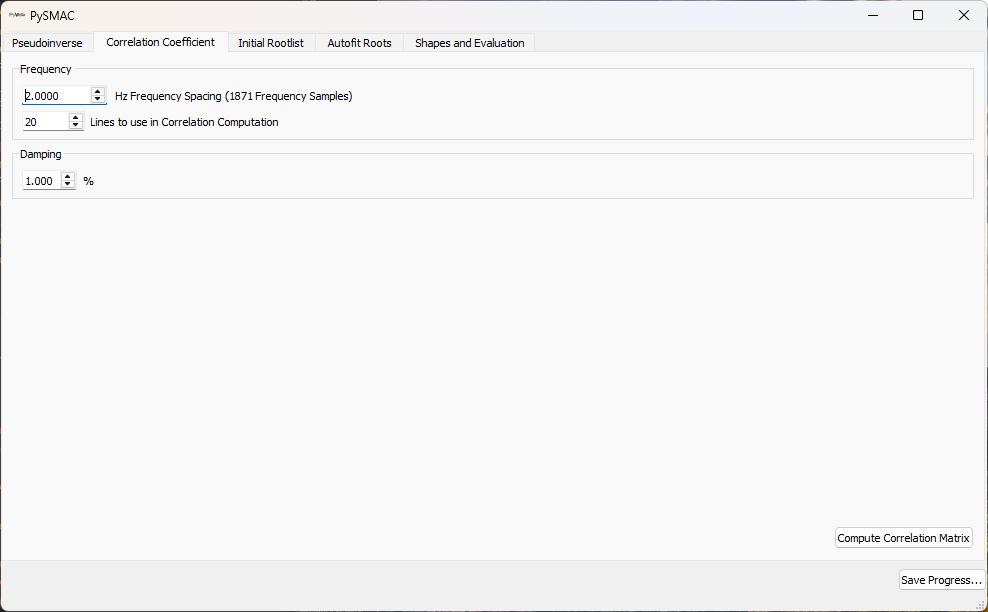


We can then click the ``Compute Correlation Matrix`` button to proceed to the
``Initial Rootlist`` tab.  This tab shows a mode indicator function in the
upper plot and the correlation coefficient at each frequency guess in the lower
plot.  It will attempt to initially automatically select peaks in the correlation
coefficient plot higher than the value specified by the ``Minimum Coefficient``
box, and populate the ``Root List`` on the left side of the window.  We can
see for this perfect synthetic data set,
[`SMAC_GUI`](#api:sdynpy.SMAC_GUI) has made very good
initial guesses for our modes, even with 1% damping specified when the true
damping should be 0.5%.  The ``Root List`` also reports the current correlation
coefficient, which is near 1.  If initial guesses at roots were not identified
successfully, the user can click on the Correlation Coefficient plot to place
additional initial guesses.  Also, if erroneous initial guesses were placed,
the user can select the row in the ``Root List`` table and click the ``Delete``
button.

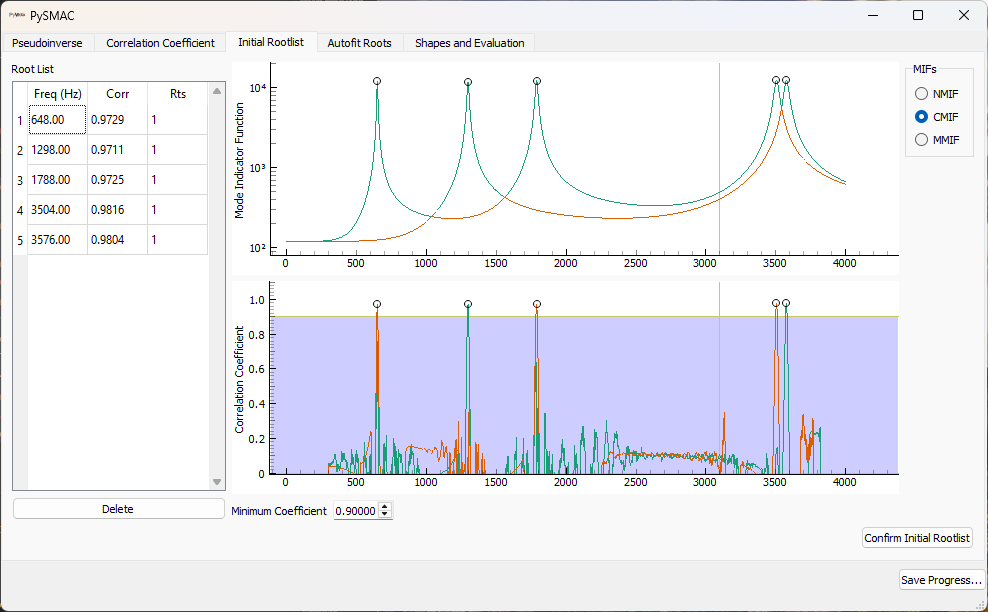

Clicking the ``Confirm Initial Rootlist`` button proceeds to the ``Autofit Roots``
tab.  This tab sets up the optimizer that will converge to the frequency and
damping that gives the highest correlation coefficient from the initial guesses
obtained on the previous tab.  Generally the default values work well for this,
though users may want to tighten or loosen the convergence tolerances depending
on their goals.

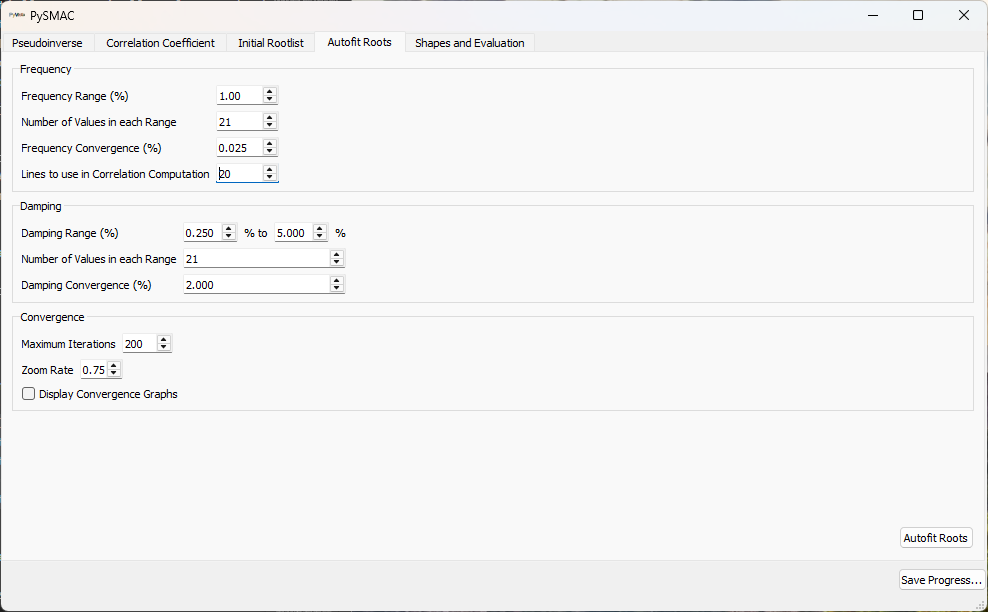

Clicking the ``Autofit Roots`` button will start the optimizer.  Progress is
reported in the console window.  If a root diverges, SMAC will discard it.
Similarly, if a root converges into another root, SMAC will discard one of them
to only keep one root.  When the optimizer has finished,
[`SMAC_GUI`](#api:sdynpy.SMAC_GUI) will proceed to the final
``Shape and Evaluation`` tab.

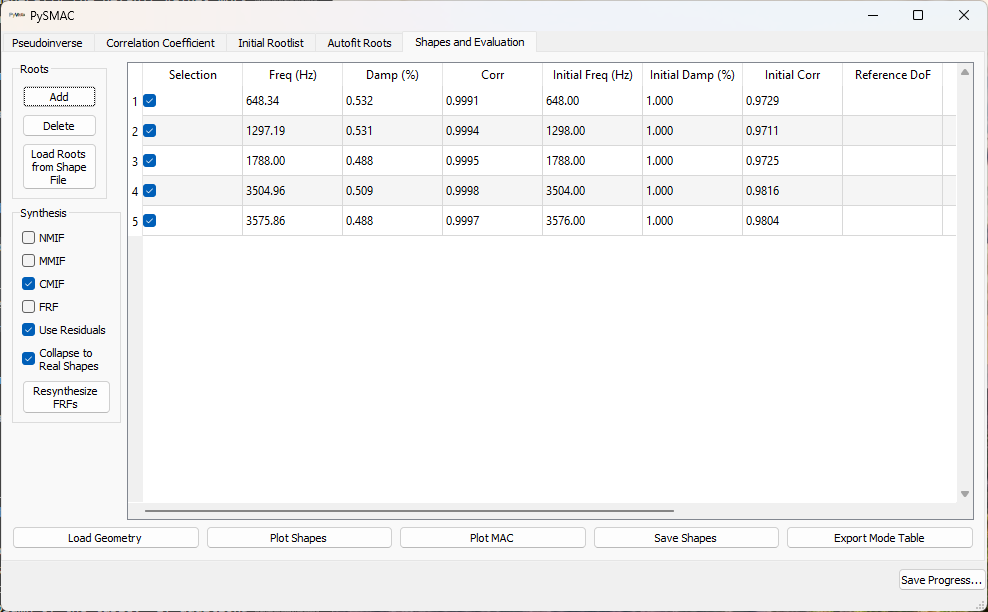

The ``Shape and Evaluation`` tab shows the final root list table, consisting of
the frequency and damping values that the optimizer converged on.  Modes can
be selected or deselected from the final root set by checking or unchecking the
checkbox in the ``Selection`` column of the table.  If additional modes occur in
the data that were not captured in the initial root list, they can be added
manually by clicking on the ``Add`` button.  Likewise, if roots are found to
be incorrect, they can be selected in the table and deleted by pressing the
``Delete`` button.  Resynthesis of frequency response functions or mode indicator
functions can be performed by checking the boxes in the ``Synthesis`` area of
the windows.  Additional options for using residuals or collapsing complex
modes to real modes can also be found there.  Clicking the ``Resynthesize FRFs``
button will trigger the resynthesis.

Clicking the ``Resynthesize FRFs`` button will also bring up a
[`GUIPlot`](#api:sdynpy.GUIPlot) window plotting the
selected resynthesis quantities.

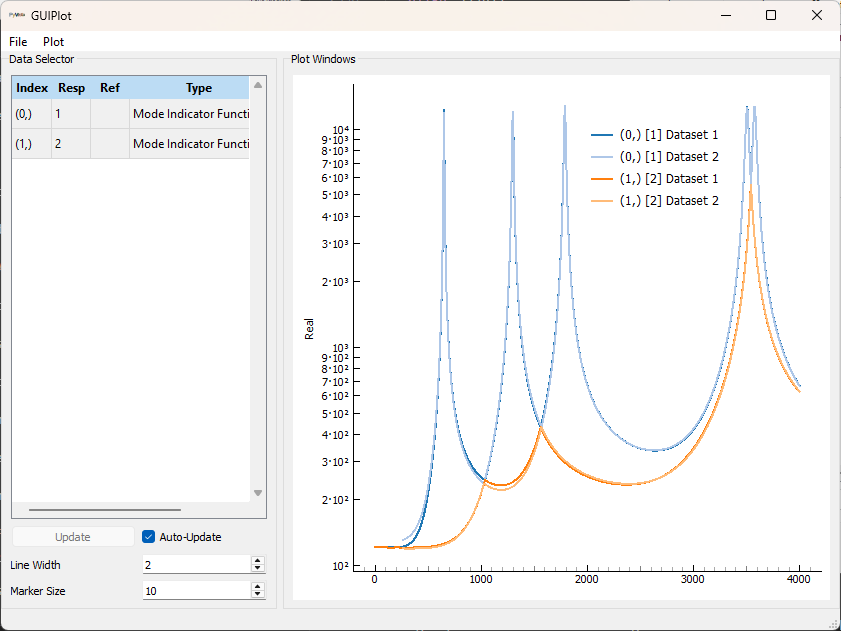

The [`SMAC_GUI`](#api:sdynpy.SMAC_GUI) ``Add`` button
brings up the ``Add Root`` dialog box.  We will cover this briefly, as its usage
can be somewhat unintutive.  In essence, the user is acting as the optimizer
while SMAC solves for the correlation coefficient over ranges of frequency
and damping values.

When the ``Add Root`` dialog appears, the initial frequency range is set to the
entire frequency range, and the initial damping range is set to the parameters
used in the ``Autofit Root`` tab.  The number of samples across the frequency
and damping axes are also taken from the values on this tab, though they can
be changed.  The top image in the dialog box shows a 2D correlation coefficient
plot where lighter colors correspond to a larger correlation coefficient.
The goal is to zoom in on the image (tightening frequency and damping tolerances)
until we converge on a peak in the correlation coefficient, which should
correspond to a mode of our system.

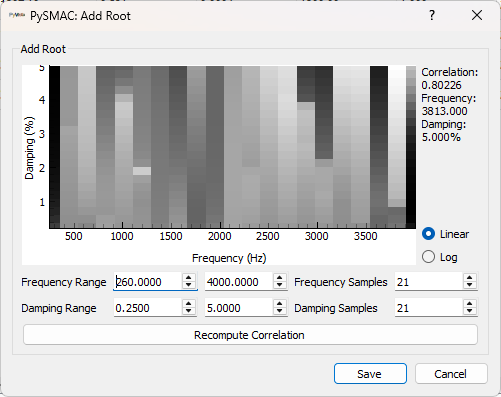

Normally, we will know approximately the frequency range in which we are
targetting a mode, either from a peak in a mode indicator function or a poor
frequency response function resynthesis in a given frequency band.  While in the
present case, SMAC has converged on all modes of the system in the bandwidth,
we will *pretend* that it has missed the fifth mode.  From the CMIF, we can see
that the fifth mode should be somewhere between 3550 and 3600 Hz, so we can
set that as th initial frequency range and click the ``Recompute Correlation``
button.

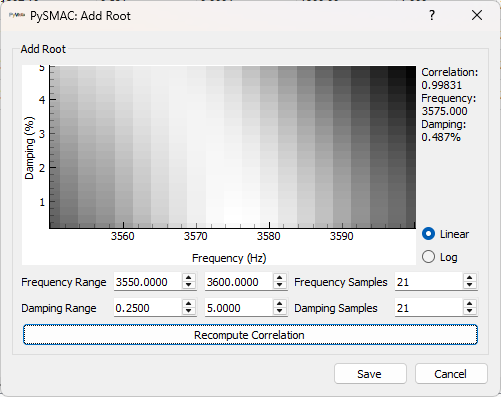

There clearly is a peak in this region, given the large swath of white
color on the image.  We can see in the text on the right side of the window that
the maximum correlation in the image is currently 0.998 with a frequency at 
3575 Hz and a damping value of 0.487%.  However, it can be difficult to identify
this position on the image due to the limited contrast available using the
linear colormap.  If we instead switch the colormap from ``Linear`` to ``Log``,
we will see a much sharper peak that we can zoom into.

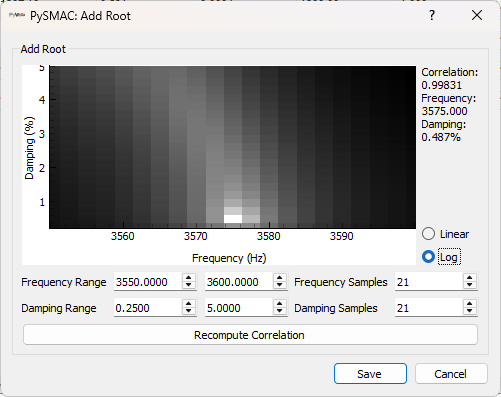

Clearly this ``Log`` view of the correlation coefficient more accurately
pin-points the location of the peak correlation coefficient.  In general,
the ``Linear`` colormap is more useful when performing rough finding of peaks
in the data, and the ``Log`` colormap is more useful when performing the final
"hone in" on the peak.

To converge on the peak, we can simply zoom in on the image with the scroll wheel or by adjusting the numeric values of frequency and damping range and click the
``Recompute Correlation`` button.  We can do this until we reach our desired
convergence tolerance.  Note, however, that eventually we will reach numerical
precision and the colormap will break down.  If this happens, simply zoom out
a bit and ``Recompute Correlation``.

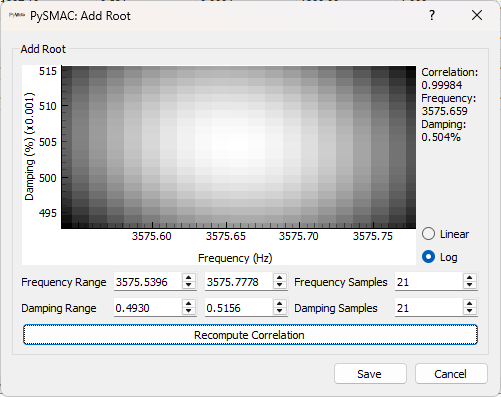

Clicking the ``Save`` button on the dialog will then close the dialog and add
the mode to the table.  We can see that this mode has a slightly higher
correlation coefficient than the original mode found by the optimizer, so we
could select that row and press the ``Delete`` button to ensure that the mode
isn't included twice.  Again we can plot the mode shapes by pressing the ``Plot Shapes``
button (be sure to click the ``Resynthesize FRFs`` button first, which will
create the shapes, otherwise a dialog will appear telling you the shapes have not
been created yet).

Finally we can write the shapes to disk.  We will then save the shape files to
disk by clicking the ``Save Shapes``
button.  We will save the shapes to a file ``shapes_smac.npy``.

## Comparing Modes

In many modal analysis workflows we wish to compare shapes to each other.  For
example, we may wish to compare shapes from a finite element model to those from
a test.  Or perhaps we may wish to compare two sets of shapes from a model that
has varying parameters.  SDynPy offers several ways to easily compare modes.

First, let's load the modal data from the previous modal analyses.  We will
use the [`sdpy.shape.load`](#api:sdynpy.SdynpyArray.load)
function targetting the file names from the previous analyses.  If the files
are not in the current working directory, a full path will need to be provided.

In [96]:
shapes_polypy = sdpy.shape.load('shapes_polypy.npy')
shapes_smac = sdpy.shape.load('shapes_smac.npy')

To compare modes, we often need to first figure out which modes in each dataset
correspond to one another.  Especially if closely spaced modes exist, there may
be mode order changes, so we cannot always compare the first mode in the first
data set with the first mode of the second.  Especially when comparing model
to test data, there may be rigid body modes from the model that were not measured
in the test.  Mode correspondences are often assigned via shape, often using a
metric such as the Modal Assurance Criterion (MAC) matrix.

SDynPy can construct a MAC matrix easily using the 
[`sdpy.shape.mac`](#api:sdynpy.core.sdynpy_shape.mac) function.  The matrix
can be plotted using the
[`sdpy.matrix_plot`](#api:sdynpy.matrix_plot)
function.


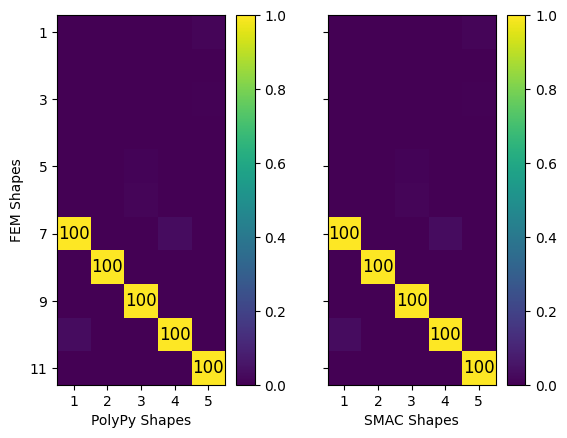

In [97]:
# Compute MACs
mac_polypy = sdpy.shape.mac(shapes,shapes_polypy)
mac_smac = sdpy.shape.mac(shapes,shapes_smac)
# Create a figure
fig,ax = plt.subplots(1,2,num='MAC Matrices',sharey=True,sharex=True)
# Plot the PolyPy MAC
sdpy.matrix_plot(mac_polypy,ax=ax[0])
ax[0].set_ylabel('FEM Shapes')
ax[0].set_xlabel('PolyPy Shapes')
# Plot the SMAC MAC
sdpy.matrix_plot(mac_smac,ax=ax[1])
ax[1].set_ylabel('')
ax[1].set_xlabel('SMAC Shapes');

The frequency and damping ratios are also often compared.  The
[`sdpy.shape.shape_comparison_table`](#api:sdynpy.core.sdynpy_shape.shape_comparison_table)
function is useful for this.  We can pass in two sets of shapes to see the
tabulated differences in the parameters.  First we will need to extract the
shape correspondences.

In [98]:
polypy_correspondences = np.where(mac_polypy > 0.9)
smac_correspondences = np.where(mac_smac > 0.9)

Then we can print the mode tables.  We will adjust the formatting of the percent
errors to give more decimal places, as the default will only plot one decimal
place, resulting in all frequencies having 0.0% error.

In [99]:
print('PolyPy Comparison to Analytical Results')
print(sdpy.shape.shape_comparison_table(
    shapes[polypy_correspondences[0]],
    shapes_polypy[polypy_correspondences[1]],
    percent_error_format='{:0.3f}%'))

PolyPy Comparison to Analytical Results
  Mode  Freq 1 (Hz)  Freq 2 (Hz)  Freq Error  Damp 1  Damp 2  Damp Error  MAC
     1       648.56       648.30      0.041%   0.50%   0.53%     -5.898%  100
     2      1297.12      1296.88      0.018%   0.50%   0.50%     -0.853%  100
     3      1787.81      1788.06     -0.014%   0.50%   0.50%      0.411%  100
     4      3504.98      3505.21     -0.007%   0.50%   0.49%      2.091%  100
     5      3575.61      3576.07     -0.013%   0.50%   0.49%      1.949%  100



In [100]:
print('SMAC Comparison to Analytical Results')
print(sdpy.shape.shape_comparison_table(
    shapes[smac_correspondences[0]],
    shapes_smac[smac_correspondences[1]],
    percent_error_format='{:0.3f}%'))

SMAC Comparison to Analytical Results
  Mode  Freq 1 (Hz)  Freq 2 (Hz)  Freq Error  Damp 1  Damp 2  Damp Error  MAC
     1       648.56       648.34      0.034%   0.50%   0.53%     -5.960%  100
     2      1297.12      1297.19     -0.005%   0.50%   0.53%     -5.758%  100
     3      1787.81      1788.00     -0.011%   0.50%   0.49%      2.564%  100
     4      3504.98      3504.96      0.000%   0.50%   0.51%     -1.723%  100
     5      3575.61      3575.66     -0.001%   0.50%   0.50%     -0.868%  100



We can see that SMAC has perhaps identified frequencies more accurately, but
was less accurate on the damping estimates.  Note that these are not general
rules and likely depend on the parameters selected in each curve fitting tool.  Both curve fitters have identified the modes very accurately.

While the MAC can give a rough idea of how correlated pairs of shapes are, it
does not give an intuitive view of how the shapes are different.  For this, we
would often like to plot the shapes on top of one another.  We can also do this
easily in SDynPy with the
[`sdpy.Geometry.overlay_geometries`](#api:sdynpy.Geometry.overlay_geometries)
and
[`sdpy.shape.overlay_shapes`](#api:sdynpy.ShapeArray.overlay_shapes)
functions.
Note that the
[`sdpy.shape.overlay_shapes`](#api:sdynpy.ShapeArray.overlay_shapes)
function will automatically call the
[`sdpy.Geometry.overlay_geometries`](#api:sdynpy.Geometry.overlay_geometries)
functions, so if we are comparing shapes, we only need to call the latter function.
We simply give the function a set of geometries and a set of shapes to overlay,
and we can additionally specify colors to override so we can identify which is
which.  Because the fit shapes and finite element shapes share the same geometry,
we simply pass it twice.

In [101]:
# Overlay shapes
overlaid_geometry,overlaid_shapes = sdpy.shape.overlay_shapes(
    (geometry,geometry),
    (shapes[polypy_correspondences[0]],shapes_polypy[polypy_correspondences[1]]),
    color_override=[1,7])
# Plot the overlaid shapes on the overlaid geometry
overlaid_geometry.plot_shape(overlaid_shapes)

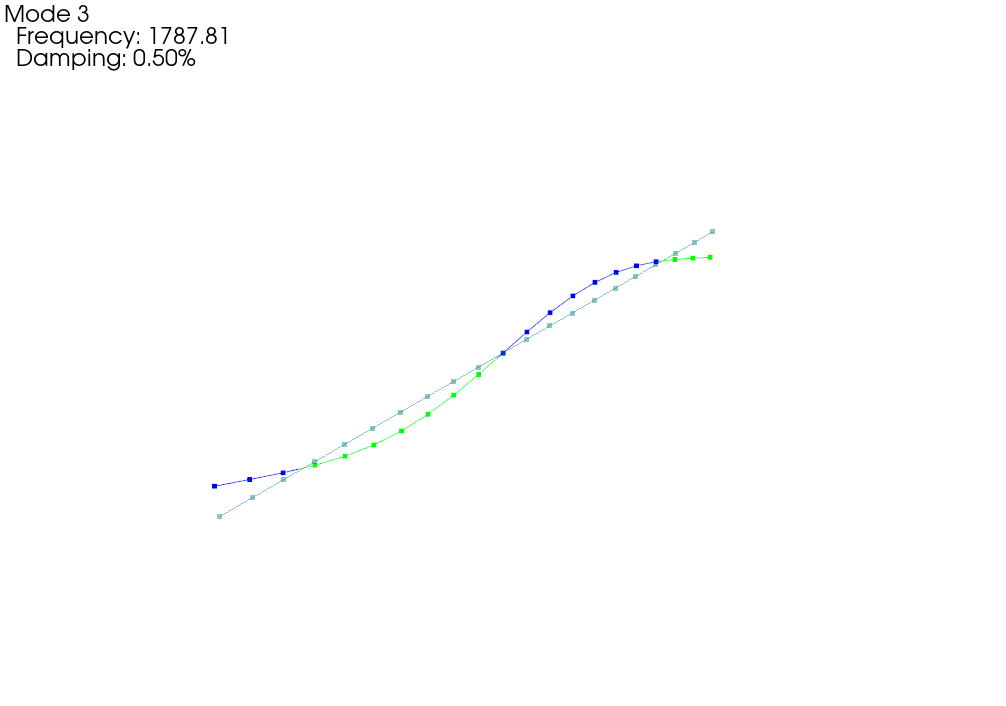

## Adding Another Beam

Let's make our system more complicated by adding an additional beam.  We can
demonstrate some of SDynPy's more advanced features by combining the two
structures together.  This beam will be half as long as the previous beam and
connect at a right angle to the end of the first beam.

In [102]:
system_2,geometry_2 = sdpy.System.beam(
    length = 0.1, # Meters
    width = 0.01, # Meters
    height = 0.005, # Meters
    num_nodes = 11,
    material='steel')

We will modify the geometry of this second beam by rotating its coordinate
system.  We will also change the color of the traceline so it is more
distinguishable from the initial beam.

In [103]:
geometry_2.coordinate_system.matrix[0,:3,:3] = np.array([[0,1,0],
                                                            [0,0,1],
                                                            [1,0,0]])
geometry_2.traceline.color = 7

If we plot the geometry, we can now see that it is oriented 90 degrees to the
original geometry.  We can use the
[`sdpy.Geometry.overlay_geometries`](#api:sdynpy.Geometry.overlay_geometries)
function to quickly produce a combined geometry which to plot.  We will also have
the system return a ``node_id_offset``, which we can use to offset the degrees
of freedom of our systems so they remain consistent with the geometry.  This is
needed because the
[`sdpy.Geometry.overlay_geometries`](#api:sdynpy.Geometry.overlay_geometries)
function offsets the node numbers so there are no conflicts between the two
geometries.

In [104]:
# Overlay geometry and plot
combined_geometry,node_id_offset = sdpy.Geometry.overlay_geometries(
    (geometry,geometry_2),
    return_node_id_offset=True)
# Plot the combined geometry
combined_geometry.plot()

(<sdynpy.GeometryPlotter at 0x2aa3d3ed130>,
 PolyData (0x2aa3d405e40)
   N Cells:    2
   N Points:   32
   N Strips:   0
   X Bounds:   0.000e+00, 2.000e-01
   Y Bounds:   0.000e+00, 1.000e-01
   Z Bounds:   0.000e+00, 0.000e+00
   N Arrays:   1,
 PolyData (0x2aa3d4064a0)
   N Cells:    32
   N Points:   32
   N Strips:   0
   X Bounds:   0.000e+00, 2.000e-01
   Y Bounds:   0.000e+00, 1.000e-01
   Z Bounds:   0.000e+00, 0.000e+00
   N Arrays:   2,
 None)

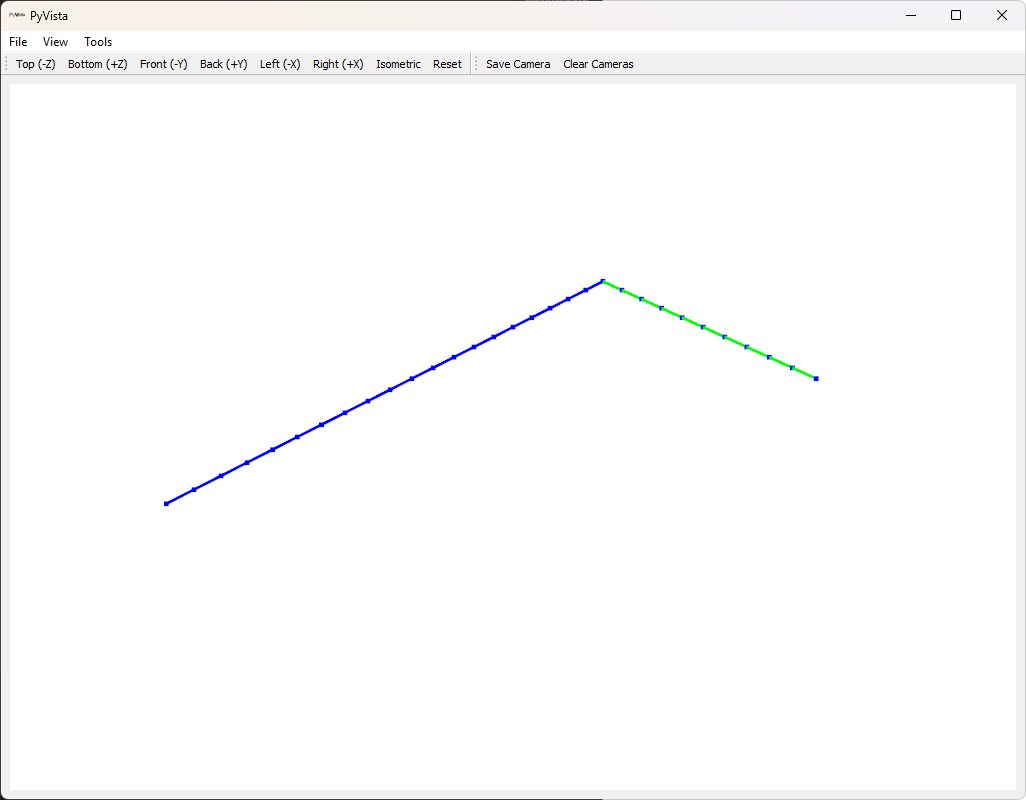

Now let's think about combining the systems.  First, let's add some damping to
the systems.  We saw previously that we had some issues with the undamped systems
not being equivalent to shapes, as well as having potentially infinite displacement.
We can add some approximate damping to the
system such that when a modal transformation is performed, it will result in
modal damping. The [`System`](#api:sdynpy.System) object
has an
[`assign_modal_damping`](#api:sdynpy.System.assign_modal_damping)
method that is useful for doing this.

In [105]:
damped_system = system.copy()
damped_system.assign_modal_damping(0.005)
damped_system_2 = system_2.copy()
damped_system_2.assign_modal_damping(0.005)

With damping added, we can concatenate the systems together using the
[`concatenate`](#api:sdynpy.System.concatenate) class
method of [`System`](#api:sdynpy.System).  Note that this
does not actually attach either structure to the other.  It simply puts them in
the same [`System`](#api:sdynpy.System) object.  If we
examine the system matrices, we will see there is no coupling between any
degrees of freedom on the first beam to the second beam.  Note that the
[`concatenate`](#api:sdynpy.System.concatenate)
function accepts the ``node_id_offset`` from the
[`sdpy.Geometry.overlay_geometries`](#api:sdynpy.Geometry.overlay_geometries)
function.

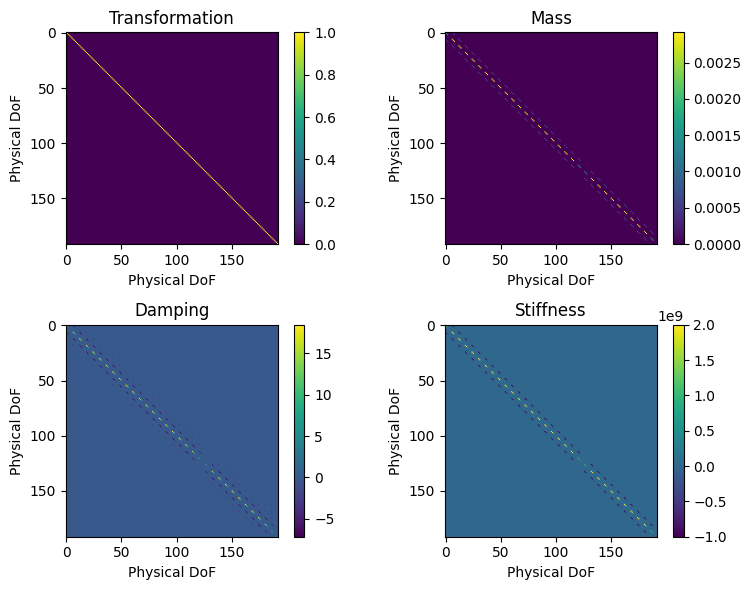

In [106]:
combined_system = sdpy.System.concatenate((damped_system,damped_system_2),
                                            node_id_offset)
# Plot the combined system matrices
fig,ax = plt.subplots(2,2,num='Combined System Matrices',figsize=(8,6))
ax = ax.flatten()
# Transformation
timg = ax[0].imshow(combined_system.transformation)
ax[0].set_title('Transformation')
ax[0].set_ylabel('Physical DoF')
ax[0].set_xlabel('Physical DoF')
plt.colorbar(timg,ax=ax[0])
# Mass
mimg = ax[1].imshow(combined_system.mass)
ax[1].set_title('Mass')
ax[1].set_ylabel('Physical DoF')
ax[1].set_xlabel('Physical DoF')
plt.colorbar(mimg,ax=ax[1])
# Damping
dimg = ax[2].imshow(combined_system.damping)
ax[2].set_title('Damping')
ax[2].set_ylabel('Physical DoF')
ax[2].set_xlabel('Physical DoF')
plt.colorbar(dimg,ax=ax[2])
# Stiffness
simg = ax[3].imshow(combined_system.stiffness)
ax[3].set_title('Stiffness')
ax[3].set_ylabel('Physical DoF')
ax[3].set_xlabel('Physical DoF')
plt.colorbar(simg,ax=ax[3])
fig.tight_layout()

We can also verify by computing mode shapes or frequency responses.  We can
see that each mode shape generally consists of motion of only one structure,
meaning the two systems are not connected.

In [107]:
combined_shapes = combined_system.eigensolution()
combined_geometry.plot_shape(combined_shapes)

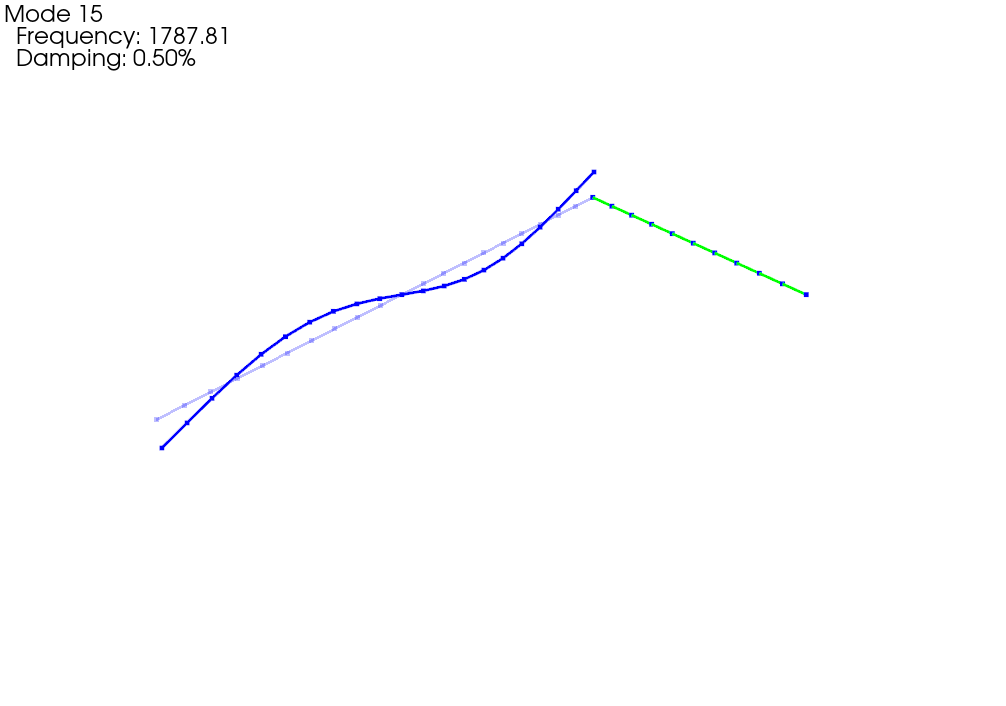

We can also verify with frequency response functions.  For example, we can
compute a frequency response function between the end of one beam to the end
of the other beam and verify that it is identically zero.  We can first check
to see the degrees of freedom of the beam.  

In [108]:
combined_geometry.plot_coordinate(label_dofs=True)

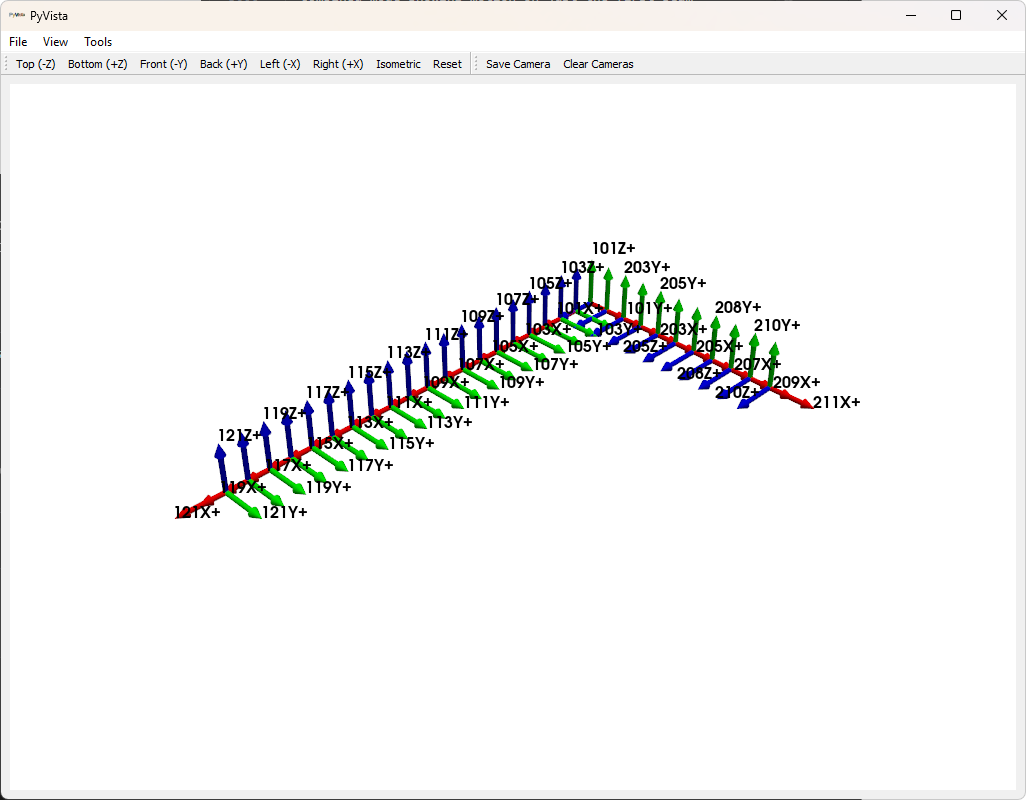

Then we can compute frequency response functions between the two structures and
verify they are zero.

In [109]:
combined_frf = combined_system.frequency_response(
    frequency_lines,
    sdpy.coordinate_array(string_array='121Y+'),
    sdpy.coordinate_array(string_array='211Z+'))

In [110]:
combined_frf.ordinate

array([[[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]]],
      shape=(1, 1, 2000))

Note in the coordinate plot that because we have rotated the beams, the degrees
of freedom do not necessarily match between the two systems.  At the coincident
nodes, degree of freedom ``101Z+`` is not equivalent to ``201Z+``, but instead
it is equivalent ``201Y+``.

### Applying Constraints to the System

In order to make the system behave as one structure instead of two separate
structures, we must apply constraints to the system.  For example, we have
just identified that degrees of freedom ``101Z+`` and ``201Y+`` correspond
to the same position in space moving the same direction, so we should constrain
them to move together.  We should apply similar constraints to the other
translations and rotations at that location.  While SDynPy has the ability to
apply constraints directly to degrees of freedom in this way using the
[`substructure_by_coordinate`](#api:sdynpy.System.substructure_by_coordinate)
method of the [`System`](#api:sdynpy.System)
object, it can also apply constraints automatically based on coincident geometry
using the
[`substructure_by_position`](#api:sdynpy.System.substructure_by_position)
class method of the [`System`](#api:sdynpy.System).
This latter method will automatically determine which nodes are coincident,
as well as handle the different coordinate systems between the two systems.

In [111]:
constrained_system,constrained_geometry = sdpy.system.substructure_by_position(
    (damped_system,damped_system_2),
    (geometry,geometry_2))

If we compare our constrained system to the simply combined system, we will see
that they have the same number of physical degrees of freedom, but the
constrained system has six fewer internal degrees of freedom.  These are lost
due to the application of six constraints combining the rotational and
translational degrees of freedom together.  Each constraint removes one way the
system can move.

In [112]:
combined_system

System with 192 DoFs (192 internal DoFs)

In [113]:
constrained_system

System with 192 DoFs (186 internal DoFs)

Now if we compute mode shapes or frequency response functions on this constrained
system, we should see the two structures moving together.  Additionally, if you
apply a force to the first beam, the second beam will begin to move.


In [114]:
constrained_shapes = constrained_system.eigensolution()
constrained_geometry.plot_shape(constrained_shapes)

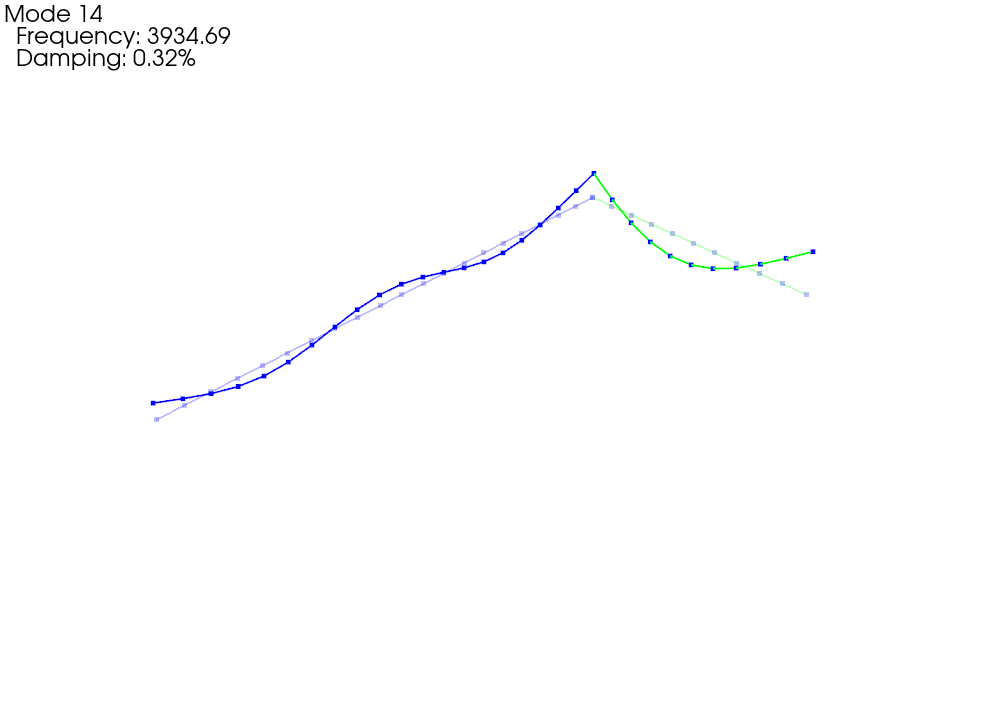

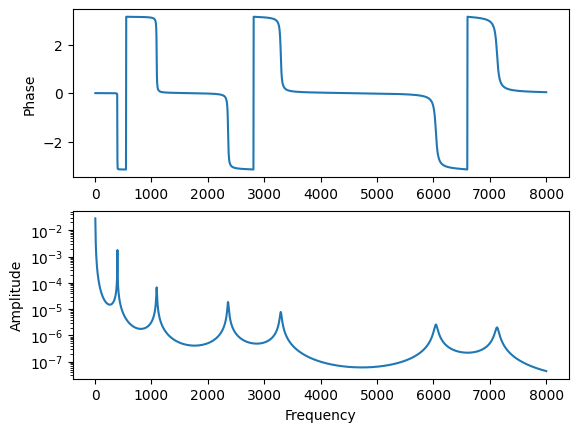

In [115]:
constrained_frf = constrained_system.frequency_response(
    frequency_lines,
    sdpy.coordinate_array(string_array='121Y+'),
    sdpy.coordinate_array(string_array='211Z+'))

constrained_frf.plot();

For more advanced substructuring examples in SDynPy, see the example on the
@sec:substructuring.

### Frequency-Based Substructuring

In addition to assembling system matrices we can also perform substructuring
in the frequency domain.  We will need frequency response functions for all
connection degrees of freedom, as well as the frequency response functions we
wish to compute in the assembled system.

In [116]:
# Get the interface frfs
interface_dofs = sdpy.coordinate_array(
    [101,201],['X+','Y+','Z+','RX+','RY+','RZ+'],
    force_broadcast=True)

# Get the frfs that we want to compute in the constrained systems
response_dofs = sdpy.coordinate_array(string_array=['121Y+'])
reference_dofs = sdpy.coordinate_array(string_array=['211Z+'])

# Compute unconstrained frequency response functions
combined_frf = combined_system.frequency_response(
    frequency_lines,
    responses = np.concatenate((interface_dofs,response_dofs)),
    references = np.concatenate((interface_dofs,reference_dofs)))

To perform the substructuring, we will have to assemble the degree of freedom
pairs that we wish to constrain, similar to what we would have had to have done
had we used the
[`substructure_by_coordinate`](#api:sdynpy.System.substructure_by_coordinate)
method of the [`System`](#api:sdynpy.System)
object instead of the
[`substructure_by_position`](#api:sdynpy.System.substructure_by_position)
class method of the [`System`](#api:sdynpy.System).  The
[`TransferFunctionArray`](#api:sdynpy.TransferFunctionArray)
class also has a
[`substructure_by_coordinate`](#api:sdynpy.TransferFunctionArray.substructure_by_coordinate)
method that accepts degree of freedom pairs that will be used to apply
constraints.

In [117]:
dof_pairs = sdpy.coordinate_array(
    string_array = [['101Z+','201Y+'],
                    ['101Y+','201X+'],
                    ['101X+','201Z+'],
                    ['101RZ+','201RY+'],
                    ['101RY+','201RX+'],
                    ['101RX+','201RZ+']])

# Perform substructuring
constrained_frf_ss = combined_frf.substructure_by_coordinate(dof_pairs)

We can then compare frequency response functions across between the systems 
to those computed from the combined system matrices to ensure they give the
same result.  SDynPy's book-keeping capabilities are useful here.  We can index
the frequency response functions with a
[`CoordinateArray`](#api:sdynpy.CoordinateArray)
object to pull out the desired function.  We can get this
[`CoordinateArray`](#api:sdynpy.CoordinateArray)
directly from the function against which we wish to compare, to ensure we are
comparing identical degrees of freedom.  The
[`GUIPlot`](#api:sdynpy.GUIPlot) will allow easy comparisons
between functions.

In [118]:
# Get the coordinates
compare_coordinates = constrained_frf.coordinate

# Extract the correct functions by indexing with the coordinates
constrained_frf_compare = constrained_frf_ss[compare_coordinates]

# Plot the comparison
gp = sdpy.GUIPlot(constrained_frf,constrained_frf_compare);

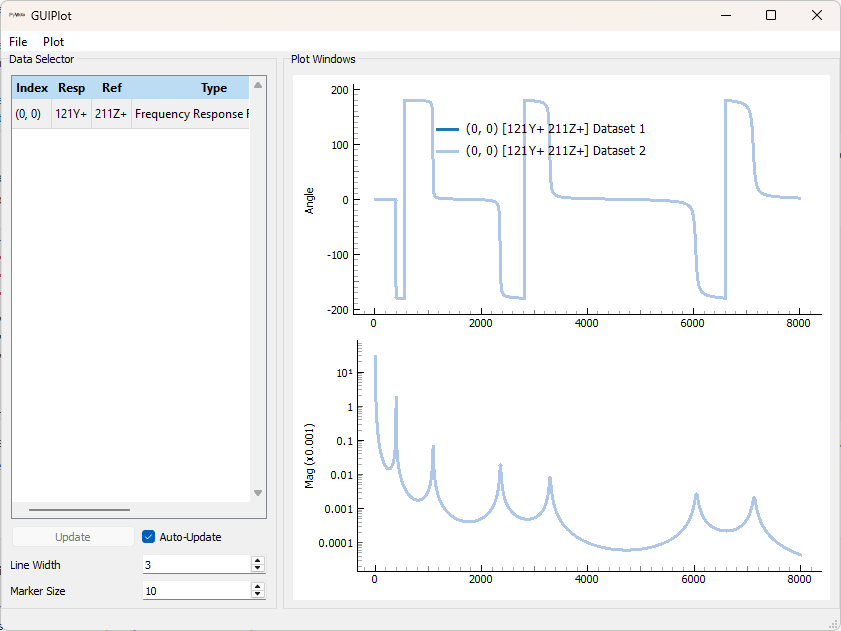

We can see that the results compare identically to the previous case of
constraining the system matrices and then computing frequency response functions
from the constrained system.

## Summary

This section has walked through some of the major features in the SDynPy package, from visualizing geometry and data to fitting modes and performing substructuring.  SDynPy has the simple capabilities to make common workflows easier, as well as advanced capabilities to perform cutting edge research.